In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
import gspread
from google.auth import default
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
from gspread_dataframe import set_with_dataframe

In [3]:
# Google Drive authentication
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [4]:
import warnings
warnings.filterwarnings("ignore")

**PANDEMIA COVID-19 EN COLOMBIA**:
* **Inicio**:	6 de marzo de 2020 (5 años, 10 meses y 3 días)
* **Cuarentena**:	Cuarentena nacional 25 de marzo de 2020-31 de agosto de 2020 (5 meses y 7 días) Aislamiento selectivo 1 de septiembre de 2020-1 de julio de 2022 (1 año, 10 meses)

In [5]:
# PARAMETERS
WITH_COVID = True
COVID_DATES = ['01-03-2020','01-07-2022']  # mm-dd-YYYY format. Both dates are considered to be included in COVID period
TARGET_DATASET_PROC = True
TARGET_LOGITDIFF_TRANSF = False
REGRESSOR_DATASET_PROC = True
TEST_SIZE = 6
S = 12  # seasonality

## Auxiliary functions

In [6]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [8]:
def forecast_plot(true_data, forecast, title, detransform=True):
    '''
    Plots forecast vs observed levels and calculates error metrics.
    '''
    test_size = len(forecast)
    forecast_start_date = forecast.index[0]

    # 1. Reference the actual levels from your global dataframe
    true_levels_full = target_levels[TARGET]

    if detransform:
        start_idx = true_levels_full.index.get_loc(forecast_start_date)
        base_for_math = true_levels_full.iloc[start_idx-12 : start_idx]
        forecast_reconstructed = target_detransformation(forecast, base_for_math)
        y_pred_series = forecast_reconstructed.iloc[12:]
        y_true_series = true_levels_full.loc[forecast.index]
    else:
        y_pred_series = forecast
        y_true_series = true_data.loc[forecast.index]

    # 2. Calculate Metrics
    y_true = y_true_series.values
    y_pred = y_pred_series.values

    mape_val = round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 3)
    mae_val = round(mean_absolute_error(y_true, y_pred), 3)
    rmse_val = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    r2_val = round(r2_score(y_true, y_pred), 3)

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    obs_to_plot = true_levels_full.iloc[start_idx - 24 : start_idx + test_size]
    ax.plot(obs_to_plot, label='Observed (Actual)', color='#004481', marker=".", linewidth=1.5)
    ax.plot(y_pred_series, label='Forecast', color='#2DCCCD', marker="o", markersize=4, linestyle='--')
    ax.set_title(f'{title}\nRMSE: {rmse_val} | MAE: {mae_val} | MAPE: {mape_val}%')
    ax.set_ylabel(f"{TARGET} Level")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if detransform:
      ax.set_ylabel(f"{TARGET} (levels)")
    else:
      ax.set_ylabel(f"{TARGET} (yearly diff)")
    plt.tight_layout()
    plt.show()

In [9]:
### ADD DUMMIES INDICATING IF A VARIABLE IS MISSING

def add_missing_flags(df, y_col):
    """
    Adds m_<cov> columns (=1 if cov observed, else 0) ONLY for covariates
    that have missing values within the target's observed history window.
    """
    out = df.copy()

    # Target history window: where y exists
    y_mask = out[y_col].notna()
    first_idx = out.index[y_mask].min()
    last_idx  = out.index[y_mask].max()
    history = out.loc[first_idx:last_idx]

    for col in list(df.columns.drop([y_col])):
        # Does this covariate have any missing inside the target history window?
        if history[col].isna().any():
            out[f"m_{col}"] = out[col].notna().astype(int)
    return out.fillna(0)

In [10]:
def add_fourier_terms(df, period=12, K=3, prefix="fourier"):
    df = df.copy()
    t = np.arange(len(df), dtype=float)

    for k in range(1, K + 1):
        df[f"{prefix}_sin{k}"] = np.sin(2 * np.pi * k * t / period)
        df[f"{prefix}_cos{k}"] = np.cos(2 * np.pi * k * t / period)

    return df

In [11]:
def add_covid_dummy(df, covid_dates, dummy_name="covid"):
  df = df.copy()

  # Convertir fechas COVID (formato mm-dd-YYYY)
  start = pd.to_datetime(covid_dates[0], format="%m-%d-%Y")
  end   = pd.to_datetime(covid_dates[1], format="%m-%d-%Y")

  # Crear dummy (ambos extremos incluidos)
  df[dummy_name] = ((df.index >= start) &
                    (df.index <= end)).astype(int)

  return df

In [12]:
def fill_nan_with_mean(df, column):
    df = df.copy()
    mean_value = df[column].mean(skipna=True)
    df[column] = df[column].fillna(mean_value)
    return df

In [13]:
def rolling_validation_2025(model_fn, data, target_var, model_kwargs=None):

    data = data.sort_index().copy()

    periods = [
        ("2024-12-01", "2025-05-01"),
        ("2025-06-01", "2025-11-01")
    ]

    all_preds = []

    for start, end in periods:
        start = pd.to_datetime(start)

        train_data = data.loc[data.index < start].copy()
        test_chunk = data.loc[(data.index >= start) & (data.index <= end)].copy()
        test_size = len(test_chunk)
        df_model = pd.concat([train_data, test_chunk])

        y_pred = model_fn(data=df_model, target_var=target_var, test_size=test_size, **model_kwargs)

        all_preds.append(y_pred)

    return pd.concat(all_preds)

In [14]:
def rolling_validation_12_windows(model_fn, data, target_var, model_name, model_kwargs=None):
    if model_kwargs is None: model_kwargs = {}

    colors = ['#004481', '#2DCCCD', '#1464A5', '#D8BE75', '#1973B8', '#F7893B', '#5BBEFF', '#F8CD51', '#48AE64', '#02A5A5', '#F78BE8']

    data = data.sort_index().copy()
    start_dates = pd.date_range(start="2024-07-01", periods=12, freq="MS")

    # --- CAMBIO PARA EL ÍNDICE COMPLETO ---
    # Calculamos la fecha máxima posible (final de la última ventana)
    max_forecast_date = start_dates[-1] + pd.DateOffset(months=5)
    full_actuals = target_levels[target_var]

    # Creamos un índice que vaya desde el inicio histórico hasta el final del último forecast
    extended_index = pd.date_range(start=full_actuals.index[0], end=max_forecast_date, freq="MS")
    # --------------------------------------

    metrics_list = []
    plt.figure(figsize=(14, 6))

    plt.plot(full_actuals.iloc[-60:].index, full_actuals.iloc[-60:], color='black', alpha=0.3, label='Real', linewidth=3)

    for i, start in enumerate(start_dates):
        end = start + pd.DateOffset(months=5)

        # 1. Preparación de datos
        train_data = data.loc[data.index < start].copy()
        test_chunk = data.loc[(data.index >= start) & (data.index <= end)].copy()
        if test_chunk.empty: continue
        df_model = pd.concat([train_data, test_chunk])

        # 2. Predicción
        y_pred_transformed = model_fn(data=df_model, target_var=target_var, test_size=len(test_chunk), **model_kwargs)
        if not isinstance(y_pred_transformed, pd.Series):
            y_pred_transformed = pd.Series(y_pred_transformed, index=test_chunk.index)

        # 3. Detransformación
        start_idx = full_actuals.index.get_loc(start)
        base_for_math = full_actuals.iloc[start_idx-12 : start_idx]
        reconstructed = target_detransformation(y_pred_transformed, base_for_math)
        y_pred_final = reconstructed.iloc[12:] if len(reconstructed) > 12 else reconstructed

        y_true_final = full_actuals.loc[y_pred_final.index]

        # 4. Cálculo de Métricas
        metrics_list.append({
            "Window": i + 1,
            "MAE": round(mean_absolute_error(y_true_final, y_pred_final), 2),
            "RMSE": round(np.sqrt(mean_squared_error(y_true_final, y_pred_final)), 2),
            "R2": round(r2_score(y_true_final, y_pred_final), 2),
            "MAPE (%)": round(np.mean(np.abs((y_true_final - y_pred_final) / y_true_final)) * 100, 2)
        })

        # 5. Plotting
        current_color = colors[i % len(colors)]
        plt.plot(y_pred_final.index, y_pred_final, color=current_color, linestyle='--', marker='o', markersize=4, label=f"W{i+1}")

        # --- SOLUCIÓN AL PROBLEMA DEL ÍNDICE ---
        # 1. Concatenamos histórico + forecast
        y_pred_complete = pd.concat([full_actuals.loc[full_actuals.index < start], y_pred_final])

        # 2. Reindexamos la serie para que tenga el tamaño total (rellena con NaNs el futuro/pasado faltante)
        y_pred_complete = y_pred_complete.reindex(extended_index)

        # 3. Guardamos en el objeto global
        RESULTS_FORECASTS[f"{target_var}_{model_name}_w{i+1}"] = y_pred_complete

    # Estética final
    plt.title(f"6-month rolling {model_name} forecast: {target_var} (levels)", fontsize=10, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=9, frameon=False)
    plt.ylabel("Nivel")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # 6. Consolidar métricas
    metrics_df = pd.DataFrame(metrics_list).set_index("Window")
    final_table = metrics_df.T
    final_table['Mean'] = final_table.mean(axis=1)

    RESULTS_METRICS[f"{target_var}_{model_name}"] = final_table["Mean"]

    return final_table

In [15]:
spreadsheet = gc.open_by_key('14NNzB9d3JcoBGuNcQGmEWoLH6uKAHyeNc_Zgm8cfSpM')

sheet = spreadsheet.worksheet('target')
print('Targets are not processed.')
data = sheet.get_all_values()
target_levels = pd.DataFrame.from_records(data[1:], columns=data[0]).set_index("date")
target_levels.index = pd.to_datetime(target_levels.index, format="%d/%m/%Y")
for col in target_levels.columns:
    target_levels[col] = target_levels[col].str.replace(',', '.').replace('', np.nan).astype(float)
target_levels = target_levels.rename(columns={" npl_comercial ":"npl_comercial", " npl_consumo ":"npl_consumo", " npl_hipotecaria ":"npl_hipotecaria", " npl_microcredito ":"npl_microcredito", " npl_total ":"npl_total", " npl_totalsinmicro ":"npl_totalsinmicro"})
target_levels = target_levels["2002":]

Targets are not processed.


In [16]:
def target_detransformation(target_diff, base_levels):
    '''
    Converts monthly annual differences back to monthly levels.
    Parameters:
    - target_diff: pd.Series of YoY differences (Y_t - Y_{t-12})
    - base_levels: pd.Series containing exactly the 12 months of actual values immediately preceding the target_diff start date.
    '''
    # We use a list for performance during the recursive loop
    reconstructed = list(base_levels.values)
    diffs = list(target_diff.values)

    for i in range(len(diffs)):
        # Formula: Y_t = Diff_t + Y_{t-12}
        new_val = diffs[i] + reconstructed[i]
        reconstructed.append(new_val)

    full_index = base_levels.index.append(target_diff.index)
    return pd.Series(reconstructed, index=full_index)

Como la transformación es la **diferencia interanual de los logits de los valores originales**, la detransformación será sobre:
  * `y_transf`: Concatenación de `y_train_transf` (valores reales transformados de la var. objetivo desde fecha de inicio de transformación hasta el comienzo de las predicciones -es decir, donde empieza hasta donde acaba el dataset de entrenamiento) con `y_pred_transf` (valores predichos transformados, sólo durante el periodo de test).
  * `y_init`: Valor real no transformado del periodo 12 veces anterior al primer valor transformado.

In [17]:
def logitdiff_transformation(x, s=12):
    logit = np.log(x / (100 - x))
    return logit - logit.shift(s)

def logitdiff_detransformation(x_transf, x_init, s=S, x_orig_train=None):
    """
    x_transf: serie en escala logit-diff (train+test)
    x_init  : s valores reales previos al primer valor transformado (se usa si no hay x_orig_train)
    x_orig_train: (opcional) serie real del tramo de train, alineada con x_transf.index.
                  Se usará su logit original para no recalcularlo.
    """
    logit = pd.Series(np.nan, index=x_transf.index)
    if x_orig_train is not None:
        logit.loc[x_orig_train.index] = np.log(x_orig_train / (100 - x_orig_train))  # usar logits originales en el tramo de train
    else:
        logit.iloc[:s] = np.log(x_init.values / (100 - x_init.values))  # comportamiento anterior: seed con los s valores previos
    for t in range(len(logit)):  # reconstrucción para lo que quede sin logit (p.ej., test)
        if pd.isna(logit.iloc[t]):
            logit.iloc[t] = x_transf.iloc[t] + logit.iloc[t - s]
    return 100 / (1 + np.exp(-logit))

def detransform_predictions(train_data, y_pred_transf, target_dataset, target_var, s=S):
    y_train_transf = train_data[target_var].iloc[:-TEST_SIZE]
    y_transf = pd.concat([y_train_transf, y_pred_transf])  # tramo transformado de train y pred
    y_orig_train = target_dataset[target_var].loc[y_train_transf.index]  # valores reales del train (mismo índice que y_train_transf)
    y_init = target_dataset[target_var].loc[target_dataset.index < y_transf.first_valid_index()].iloc[-S:]
    y_detransf = logitdiff_detransformation(y_transf, y_init, x_orig_train=y_orig_train)  # detransformar usando logits originales en train
    return y_detransf.iloc[-TEST_SIZE:]

## Data Preparation

Targets are processed.
COVID period is included.


,npl_comercial,npl_consumo,npl_hipotecaria,npl_microcredito,npl_total,npl_totalsinmicro,bruta_comercial,bruta_consumo,bruta_hipotecaria,bruta_microcredito,bruta_total,bruta_totalsinmicro,vencida_comercial,vencida_consumo,vencida_hipotecaria,vencida_microcredito,vencida_total,vencida_total_sinmicro
date,,,,,,,,,,,,,,,,,,
2025-07-01,-0.23,-2.19,-0.12,-2.32,-0.86,-0.81,5.73,2.32,10.44,10.43,5.63,5.49,-0.41,-26.20,6.68,-14.94,-11.95,-11.78
2025-08-01,-0.25,-2.17,-0.25,-2.31,-0.88,-0.84,5.93,3.17,10.66,11.41,6.05,5.90,-0.92,-25.87,3.16,-14.82,-12.20,-12.05
2025-09-01,-0.34,-2.23,-0.30,-2.47,-0.96,-0.91,5.84,4.44,11.03,12.52,6.48,6.30,-3.42,-26.19,1.90,-16.50,-13.42,-13.25
2025-10-01,-0.50,-2.12,-0.36,-2.37,-1.00,-0.97,5.17,5.48,11.14,13.22,6.48,6.28,-8.33,-24.60,0.31,-15.88,-14.66,-14.59
2025-11-01,-0.57,-2.07,-0.45,-2.09,-1.04,-1.00,5.51,5.64,11.09,13.94,6.71,6.50,-9.75,-24.23,-2.49,-12.79,-15.16,-15.29


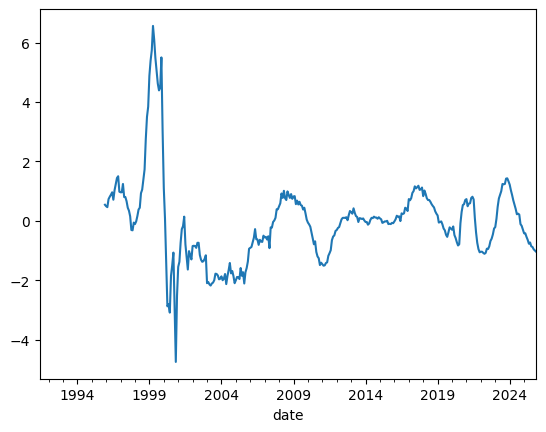

In [38]:
spreadsheet = gc.open_by_key('14NNzB9d3JcoBGuNcQGmEWoLH6uKAHyeNc_Zgm8cfSpM')

# Use RAW or PROCESSED target variables
if TARGET_DATASET_PROC == True:
  sheet = spreadsheet.worksheet('target_proc')
  print('Targets are processed.')
else:
  sheet = spreadsheet.worksheet('target')
  print('Targets are not processed.')
data = sheet.get_all_values()
target = pd.DataFrame.from_records(data[1:], columns=data[0]).set_index("date")
target.index = pd.to_datetime(target.index, format="%d/%m/%Y")
for col in target.columns:
    target[col] = target[col].str.replace(',', '.').replace('', np.nan).astype(float)
target = target.rename(columns={" npl_comercial ":"npl_comercial", " npl_consumo ":"npl_consumo", " npl_hipotecaria ":"npl_hipotecaria", " npl_microcredito ":"npl_microcredito", " npl_total ":"npl_total", " npl_totalsinmicro ":"npl_totalsinmicro"})

# Include COVID period or not
if WITH_COVID == False:
  target = target.drop(target.loc[COVID_DATES[0]:COVID_DATES[1]].index)
  target = target.reset_index().drop('date', axis=1)
  print('COVID period is not included.')
else:
  print('COVID period is included.')

target['npl_total'].plot()
target.tail()

In [39]:
target_logit_diff = target.apply(logitdiff_transformation, axis=0)
target_logit_diff.tail()

,npl_comercial,npl_consumo,npl_hipotecaria,npl_microcredito,npl_total,npl_totalsinmicro,bruta_comercial,bruta_consumo,bruta_hipotecaria,bruta_microcredito,bruta_total,bruta_totalsinmicro,vencida_comercial,vencida_consumo,vencida_hipotecaria,vencida_microcredito,vencida_total,vencida_total_sinmicro
date,,,,,,,,,,,,,,,,,,
2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,0.501630,NaN,0.282263,0.187969,1.214618,1.312091,NaN,NaN,-1.920125,NaN,NaN,NaN
2025-08-01,NaN,NaN,NaN,NaN,NaN,NaN,0.661746,NaN,0.319117,0.391460,1.483318,1.600042,NaN,NaN,-2.768538,NaN,NaN,NaN
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,0.777967,NaN,0.366958,0.571109,1.691924,1.817802,NaN,NaN,-3.194953,NaN,NaN,NaN
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,0.456016,NaN,0.363113,0.602178,1.381974,1.454926,NaN,NaN,-4.878835,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,0.206161,NaN,0.374431,0.659328,0.971639,0.997402,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
spreadsheet = gc.open_by_key('14NNzB9d3JcoBGuNcQGmEWoLH6uKAHyeNc_Zgm8cfSpM')

# Use RAW or PROCESSED target variables
if REGRESSOR_DATASET_PROC == True:
  sheet = spreadsheet.worksheet('regressors_proc')
  print('Regressors are processed.')
else:
  sheet = spreadsheet.worksheet('regressors')
  print('Regressors are not processed.')
data = sheet.get_all_values()
regressors = pd.DataFrame.from_records(data[1:], columns=data[0]).set_index("date")
for col in regressors.columns:
    regressors[col] = regressors[col].str.replace(',', '.').replace('', np.nan).astype(float)
regressors.index = pd.to_datetime(regressors.index, format="%d/%m/%Y")

# Include COVID period or not
if WITH_COVID == False:
  regressors = regressors.drop(regressors.loc[COVID_DATES[0]:COVID_DATES[1]].index)
  regressors = regressors.reset_index().drop('date', axis=1)
  print('COVID period is not included.')
else:
  print('COVID period is included.')

regressors.tail()

Regressors are processed.
COVID period is included.


,bruta_comercial,bruta_consumo,bruta_hipotecaria,bruta_microcredito,bruta_total,bruta_total_sinmicro,ise_total,ise_total_des,ise_prim_des,ise_sec_des,...,vivienda_ventas,vivienda_rotacion,tipocambio_promediomes,tipocambio_finmes,coloc_hipotec_tasaint_nom,coloc_hipotec_tasaint_real,coloc_microcred_tasaint_nom,coloc_microcred_tasaint_real,ibr_overnight_mean_nom,cds_mean
date,,,,,,,,,,,,,,,,,,,,,
2025-07-01,5.73,2.32,10.44,10.43,5.63,5.49,NaN,4.36,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-01,5.93,3.17,10.66,11.41,6.05,5.90,NaN,2.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-01,5.84,4.44,11.03,12.52,6.48,6.30,NaN,3.93,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-01,5.17,5.48,11.14,13.22,6.48,6.28,NaN,2.91,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.51,5.64,11.09,13.94,6.71,6.50,NaN,3.05,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Models



### Autoregressive (SARIMAX)

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def autoregression(data, target_var, test_size=TEST_SIZE, order=(1,0,0), seasonal_order=(0,0,0,0)):
    """
    y: pd.Series con índice temporal.
    order: (p,d,q)
    seasonal_order: (P,D,Q,s)
    horizon: pasos a predecir
    exog: exógenas del train (opcional)
    exog_future: exógenas para el horizonte (opcional; filas == horizon)
    """
    train = data[target_var].dropna().iloc[:-test_size]
    test = data[target_var].dropna().iloc[-test_size:]
    model = SARIMAX(endog=train, order=order, seasonal_order=seasonal_order, enforce_stationarity=True, enforce_invertibility=True)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=test_size)

    print("Order:", order)
    print("Seasonal order:", seasonal_order)

    return pd.Series(fc.predicted_mean, index=test.index)

In [19]:
def autoregression_with_exog(data, target_var, order=(1,0,0), seasonal_order=(0,0,0,0), test_size=TEST_SIZE):
    """
    y: pd.Series con índice temporal.
    order: (p,d,q)
    seasonal_order: (P,D,Q,s)
    horizon: pasos a predecir
    exog: exógenas del train (opcional)
    exog_future: exógenas para el horizonte (opcional; filas == horizon)
    """
    train = data.dropna().iloc[:-test_size]
    test = data.dropna().iloc[-test_size:]
    model = SARIMAX(endog=train[target_var], order=order, seasonal_order=seasonal_order, exog=train.drop(target_var, axis=1), enforce_stationarity=True, enforce_invertibility=True)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=test_size, exog=test.drop(target_var, axis=1))

    return pd.Series(fc.predicted_mean, index=test.index)

### Linear Regression
* **Do not include non-orthogonal variables** to prevent multicolinearity.
* **Split on train/test first, then scale**.
* **Coefficients are expressed in the X_scaled, y_scaled space**, meaning a 1-unit change in X_i corresponds to a 1 standard deviation increase in the original variable, and the response is in standard deviation units of y.
* **The evaluation metrics are all computed in the original (unscaled) units of y**, thus the MAE and MSE are computed on unscaled values (e.g., percentage points, ratios, etc., whatever the native unit of the target variable is).



In [20]:
def multivariate_linear_regression(data, target_var, test_size, n_lags):
    # Prep data
    data = data.copy(deep=True)
    y = data[target_var]
    if n_lags != 0:
        lag_cols = [f"y_lag{i}" for i in range(1, n_lags+1)]
        for i in range(1, n_lags+1):
            data[f"y_lag{i}"] = y.shift(i)
    data = data.dropna()  # Drop rows with NaNs introduced by lags
    X = data.drop(columns=[target_var])  # All other variables + the lag columns are regressors
    y = y.loc[data.index]

    # Train/Test split
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Model: scale X (fit on train only) and scale y
    x_pipeline = Pipeline([("x_scaler", StandardScaler()), ("linreg", LinearRegression())])
    model = TransformedTargetRegressor(
        regressor=x_pipeline,
        transformer=StandardScaler()
    )
    model.fit(X_train, y_train)

    # Iterative (recursive) multi-step prediction on the test window
    history_y = y_train.copy()  # Use actual history up to the start of the test, then roll forward using predictions.
    iter_preds = []
    for idx in X_test.index:  # Overwrite the lag columns of each X_test row using the most recent history_y values.
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags+1):  # compute lags from the current history & overwrite lag columns to avoid leakage from true future y
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])
    y_pred_test_recursive = pd.Series(iter_preds, index=X_test.index)

    # Get coefficients (in scaled-X space, as before)
    lin = model.regressor_.named_steps["linreg"]
    coef = pd.Series(lin.coef_, index=X.columns, name="coef_scaled_space")
    intercept = model.regressor_.named_steps["linreg"].intercept_

    return y_pred_test_recursive

In [21]:
def find_variance_importance(data, target_var, test_size=12):
    fig, ax = plt.subplots(figsize=(12, 6))
    for reg in data.columns.drop(target_var):
        res = multivariate_linear_regression(
            data.drop(reg,axis=1),
            target_val=target_var,
            test_size=test_size,
            lags=2,
            plot=False  # la función no dibuja
        )
        ax.plot(res["preds"].iloc[-56:], label=f"Pred w/o {reg}")
    ax.plot(data[target_var].iloc[-56:], label="true", linewidth=2, linestyle="--")
    ax.axvline(data.index[-test_size], linestyle="--", alpha=0.6, color="grey", label="Train/Test split")
    ax.set_title("Comparación de predicciones")
    ax.set_xlabel("Fecha"); ax.set_ylabel(target_var)
    ax.legend();
    fig.tight_layout()
    plt.show()

In [22]:
def build_results_table(results_by_name: dict, tests_labels: dict, fill="-", rnd=3):
    """
    results_by_name: dict con clave = nombre_variable (p. ej. 'pred_all_vars'),
                     valor = dict devuelto por tu función {'preds', 'coef', 'train_r2', 'test_r2', 'mae', 'rmse', ...}
    tests_labels:    dict mapeando la misma clave a la etiqueta de columna que quieres mostrar
                     (p. ej. {'pred_all_vars': 'All variables', 'pred_no_var1': 'Without var 1'})
    fill:            qué poner cuando falte un coeficiente en una prueba ('-' o np.nan)
    rnd:             redondeo de números
    """
    # 1) Determinar nº máximo de coeficientes en todas las pruebas
    max_k = 0
    for k, res in results_by_name.items():
        # res['coef'] es un pd.Series (ordenado mejor si ya viene así)
        if "coef" in res and isinstance(res["coef"], pd.Series):
            max_k = max(max_k, len(res["coef"]))

    # 2) Índice de filas: métricas fijas + Coefficient i
    metric_rows = ["Train R2", "Test R2", "MAE", "RMSE"]
    coef_rows = [f"Coefficient {i}" for i in range(1, max_k + 1)]
    row_index = metric_rows + coef_rows

    # 3) Construir DataFrame vacío con columnas según labels
    #    (solo incluimos columnas para las claves que existan en results_by_name)
    ordered_keys = [k for k in tests_labels.keys() if k in results_by_name]
    col_labels = [tests_labels[k] for k in ordered_keys]
    df = pd.DataFrame(index=row_index, columns=col_labels, dtype=object)

    # 4) Rellenar métricas
    for key in ordered_keys:
        res = results_by_name[key]
        col = tests_labels[key]

        # Extraer y redondear; si no está, dejar NaN
        train_r2 = float(res.get("train_r2", np.nan))
        test_r2  = float(res.get("test_r2",  np.nan))
        mae_     = float(res.get("mae",      np.nan))
        rmse_    = float(res.get("rmse",     np.nan))

        df.loc["Train R2", col] = np.round(train_r2, rnd) if np.isfinite(train_r2) else np.nan
        df.loc["Test R2",  col] = np.round(test_r2,  rnd) if np.isfinite(test_r2)  else np.nan
        df.loc["MAE",      col] = np.round(mae_,     rnd) if np.isfinite(mae_)     else np.nan
        df.loc["RMSE",     col] = np.round(rmse_,    rnd) if np.isfinite(rmse_)    else np.nan

    # 5) Rellenar coeficientes en orden (tal como vienen en res['coef'] si ya está ordenado)
    for key in ordered_keys:
        res = results_by_name[key]
        col = tests_labels[key]

        if "coef" not in res or not isinstance(res["coef"], pd.Series) or len(res["coef"]) == 0:
            # sin coeficientes: rellenar todos con fill
            for i in range(1, max_k + 1):
                df.loc[f"Coefficient {i}", col] = fill
            continue

        ser = res["coef"]  # pd.Series con índices = nombres de variables
        # Si no estás segura de que vengan ordenados, puedes ordenar por |valor| descendente:
        # ser = ser.reindex(ser.abs().sort_values(ascending=False).index)

        # Colocar valores (nombre: valor)
        for i in range(1, max_k + 1):
            if i <= len(ser):
                var = ser.index[i - 1]
                val = ser.iloc[i - 1]
                # construimos "variable: valor_redondeado"
                df.loc[f"Coefficient {i}", col] = f"{var}: {np.round(float(val), rnd)}"
            else:
                df.loc[f"Coefficient {i}", col] = fill

    return df

### Ridge Regression

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor

def multivariate_ridge_regression(data, target_var, n_lags, test_size, alpha=1.0):
    """
    Igual que tu multivariate_linear_regression, pero usando Ridge(alpha=alpha).
    Devuelve la serie de predicciones recursivas sobre la ventana test.
    """
    # Prep data
    data = data.copy(deep=True)  # no dropna global: solo al final tras generar lags
    y = data[target_var]

    # Crear lags del target
    if n_lags != 0:
        for i in range(1, n_lags + 1):
            data[f"y_lag{i}"] = y.shift(i)

    # Eliminar filas con NaNs introducidas por los lags (y por otras columnas)
    data = data.dropna()
    X = data.drop(columns=[target_var])
    y = data[target_var].loc[data.index]

    # Train/Test split
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Pipeline: escalar X y luego Ridge (regularizado)
    x_pipeline = Pipeline([
        ("x_scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    # Escalar target también con TransformedTargetRegressor para estabilidad
    model = TransformedTargetRegressor(
        regressor=x_pipeline,
        transformer=StandardScaler()
    )

    # Fit
    model.fit(X_train, y_train)

    # Iterative (recursive) multi-step prediction on the test window
    history_y = y_train.copy()
    iter_preds = []
    for idx in X_test.index:
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        # append predicted y to history for next step's lag computation
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    y_pred_test_recursive = pd.Series(iter_preds, index=X_test.index)

    # Obtener coeficientes del modelo entrenado (espacio escalado de X)
    ridge = model.regressor_.named_steps["ridge"]
    coef = pd.Series(ridge.coef_, index=X.columns, name="coef_scaled_space")
    intercept = ridge.intercept_

    print(f"Ridge alpha={alpha} Intercept: {intercept}")
    print(f"Ridge Coefficients (scaled X space):\n{coef}")

    return y_pred_test_recursive

### Regression Ensembles (Linear/Ridge)

In [24]:
def linear_regression_ensemble(data, target_var, n_lags=6, test_size=6, weighs_power=2.0):

    # primero, calcular la primera fecha no-nula por columna
    first_non_null = {c: pd.to_datetime(data[c].dropna().index[0]) for c in data.columns if data[c].dropna().shape[0] > 0}
    target_start = first_non_null[target_var]
    start_dates = sorted(set(first_non_null.values()))
    start_dates = [sd for sd in start_dates if sd >= target_start]

    y_test = data[target_var].iloc[-test_size:]

    preds = {}
    metrics = []

    for sd in start_dates:
        print(f"Fitting model since {sd}")
        # elegir columnas disponibles desde sd (primer valor no nulo <= sd)
        cols_avail = [c for c, fd in first_non_null.items() if fd <= sd]

        # recortar el dataframe desde sd y solo con columnas disponibles
        df_v = data.loc[data.index >= sd, cols_avail].copy()

        # predicción
        y_pred = multivariate_linear_regression(df_v, target_var, n_lags, test_size)
        y_pred = y_pred.reindex(y_test.index)

        # calcular RMSE
        e = rmse(y_test, y_pred)

        preds[str(sd.date())] = y_pred
        metrics.append({"start_date": str(sd.date()), "rmse": e})

    preds_df = pd.DataFrame(preds)
    metrics_df = pd.DataFrame(metrics).set_index("start_date").sort_index()

    # calcular pesos inversos al error
    raw_w = 1.0 / (metrics_df["rmse"].values ** weighs_power)
    weights = raw_w / raw_w.sum()
    metrics_df["weight"] = weights
    print(metrics_df)

    ensemble_pred = (preds_df * metrics_df["weight"].values).sum(axis=1)

    return ensemble_pred

In [25]:
def ridge_regression_ensemble(data, target_var, n_lags=6, test_size=6, weighs_power=2.0, alpha=1.0):

    # primero, calcular la primera fecha no-nula por columna
    first_non_null = {c: pd.to_datetime(data[c].dropna().index[0]) for c in data.columns if data[c].dropna().shape[0] > 0}
    target_start = first_non_null[target_var]
    start_dates = sorted(set(first_non_null.values()))
    start_dates = [sd for sd in start_dates if sd >= target_start]

    y_test = data[target_var].iloc[-test_size:]

    preds = {}
    metrics = []

    for sd in start_dates:
        print(f"Fitting model since {sd}")
        # elegir columnas disponibles desde sd (primer valor no nulo <= sd)
        cols_avail = [c for c, fd in first_non_null.items() if fd <= sd]

        # recortar el dataframe desde sd y solo con columnas disponibles
        df_v = data.loc[data.index >= sd, cols_avail].copy()

        # predicción
        y_pred = multivariate_ridge_regression(df_v, target_var, n_lags, test_size, alpha)
        y_pred = y_pred.reindex(y_test.index)

        # calcular RMSE
        e = rmse(y_test, y_pred)

        preds[str(sd.date())] = y_pred
        metrics.append({"start_date": str(sd.date()), "rmse": e})

    preds_df = pd.DataFrame(preds)
    metrics_df = pd.DataFrame(metrics).set_index("start_date").sort_index()

    # calcular pesos inversos al error
    raw_w = 1.0 / (metrics_df["rmse"].values ** weighs_power)
    weights = raw_w / raw_w.sum()
    metrics_df["weight"] = weights
    print(metrics_df)

    ensemble_pred = (preds_df * metrics_df["weight"].values).sum(axis=1)

    return ensemble_pred

### Quantile Regression

In [26]:
import statsmodels.api as sm

def quantile_regressor(data, target_var, n_lags, test_size, hyperparams):
    q = float(hyperparams.get("quantile", 0.5))  # 0 < q < 1

    # Lags
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Modelo
    X_train_sm = sm.add_constant(X_train, has_constant='add')      # Statsmodels necesita constante
    mod = sm.QuantReg(y_train, X_train_sm)
    res = mod.fit(q=q)

    # Predicción iterativa sin leakage
    history_y = y_train.copy()
    iter_preds = []
    for idx in X_test.index:
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        x_row_sm = sm.add_constant(x_row, has_constant='add')
        y_hat = float(res.predict(x_row_sm)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test.index)

### ExtraTreesRegressor

An **extremely randomized tree regressor**.

Extra-trees differ from classic decision trees in the way they are built. When looking for the best split to separate the samples of a node into two groups, random splits are drawn for each of the max_features randomly selected features and the best split among those is chosen. When max_features is set 1, this amounts to building a totally random decision tree.

In [27]:
from sklearn.ensemble import ExtraTreesRegressor

def extra_trees_regressor(data, target_var, n_lags, test_size, hyperparams):
    print("Hyperparameters:", hyperparams)
    # Construir lags de la variable objetivo
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)

    # Dejamos como features: todo excepto la y original
    df = df.dropna()  # elimina NaNs introducidos por los lags
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Modelo (el que proponías)
    model = ExtraTreesRegressor(**hyperparams)
    model.fit(X_train, y_train)

    # Predicción iterativa sin leakage
    lag_cols = [f"y_lag{i}" for i in range(1, n_lags + 1)]
    history_y = y_train.copy()  # verdad hasta el inicio de test
    iter_preds = []
    for idx in X_test.index:  # tomamos la fila de exógenas (si las hay) y sobreescribimos los lags con el histórico
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])  # actualizar histórico con la predicción recien hecha

    return pd.Series(iter_preds, index=X_test.index)

### XGBoost

In [28]:
import xgboost as xgb

def xgboost_regressor(data, target_var, n_lags, test_size, hyperparams):
    print("Hyperparameters:", hyperparams)
    # Construir lags de la variable objetivo
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Modelo XGBoost
    model = xgb.XGBRegressor(**hyperparams)
    model.fit(X_train, y_train)

    # Predicción iterativa sin leakage
    lag_cols = [f"y_lag{i}" for i in range(1, n_lags + 1)]
    history_y = y_train.copy()
    iter_preds = []
    for idx in X_test.index:
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test.index)

### LightGBM

In [29]:
from lightgbm import LGBMRegressor

def lightgbm_regressor(data, target_var, n_lags, test_size, hyperparams):
    print("Hyperparameters:", hyperparams)

    # Crear lags de la variable objetivo
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()  # eliminar NaNs generados por lags
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Entrenar modelo LightGBM
    model = LGBMRegressor(**hyperparams)
    model.fit(X_train, y_train)

    # Predicción iterativa sin data leakage
    lag_cols = [f"Y_lag{i}" for i in range(1, n_lags + 1)]
    history_y = y_train.copy()
    iter_preds = []
    for idx in X_test.index:
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test.index)

### Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_regressor(data, target_var, n_lags, test_size, hyperparams):
    # Lags
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Modelo
    model = RandomForestRegressor(**hyperparams)
    model.fit(X_train, y_train)

    # Predicción iterativa sin leakage
    history_y = y_train.copy()
    iter_preds = []
    for idx in X_test.index:
        x_row = X_test.loc[[idx]].copy()
        for i in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{i}"] = history_y.iloc[-i]
        y_hat = float(model.predict(x_row)[0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test.index)

### Bayesian Structural Time Series

In [31]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

def bsts_regressor(data, target_var, n_lags, test_size, hyperparams):
    # 1) Lags del target
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()
    y = df[target_var].astype(float)
    X = df.drop(columns=[target_var]).astype(float)

    # 2) Split temporal
    X_train, X_test = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # 3) Modelo estructural (BSTS-like)
    level = hyperparams.get("level", "local level")
    trend = hyperparams.get("trend", "local linear trend")
    seasonal = hyperparams.get("seasonal", 12)

    mod = UnobservedComponents(
        endog=y_train,
        level=level,
        trend=trend,
        seasonal=seasonal,
        exog=X_train
    )
    res = mod.fit(disp=False)

    # 4) Predicción iterativa sin leakage
    #    Clave: construir exog OOS "acumulado" de tamaño i+1 y usar índices ENTEROS en predict.
    history_y = y_train.copy()
    iter_preds = []
    exog_oos_block = pd.DataFrame(columns=X_train.columns, dtype=float)  # acumulador

    for i_step, idx in enumerate(X_test.index):
        # Tomar fila de exógenas y SOBREESCRIBIR lags con el histórico actualizado
        x_row = X_test.loc[[idx]].copy()
        for j in range(1, n_lags + 1):
            x_row.loc[idx, f"y_lag{j}"] = history_y.iloc[-j]

        # Añadirla al bloque acumulado OOS (tamaño pasa a ser i_step+1)
        exog_oos_block = pd.concat([exog_oos_block, x_row])

        # Predecir desde el primer paso OOS (len(y_train)) hasta el paso actual (len(y_train)+i_step)
        # usando el bloque acumulado de exógenas OOS
        y_hat_path = res.predict(start=len(y_train), end=len(y_train) + i_step, exog=exog_oos_block)
        y_hat = float(y_hat_path.iloc[-1])

        iter_preds.append(y_hat)
        # actualizar histórico con la predicción recién hecha
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test.index)

### Regime-Switching (Markov Switching)

In [32]:
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

def markov_ar_forecast(data, target_var, p, test_size, hyperparams):
    y = data[target_var].dropna().astype(float)

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    k_regimes = int(hyperparams.get("k_regimes", 2))
    switching_variance = bool(hyperparams.get("switching_variance", True))

    mod = MarkovAutoregression(
        endog=y_train,
        k_regimes=k_regimes,
        order=p,
        switching_variance=switching_variance,
        trend="c"
    )
    res = mod.fit(disp=False)

    # forecast OOS
    fcst = res.forecast(steps=test_size)
    fcst.index = y_test.index
    return fcst

### Long Short-Term Memory (LSTM) Network

In [33]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import AdamW

def lstm_regressor(data, target_var, n_lags, test_size, hyperparams):
    # Lags
    df = data.copy()
    for i in range(1, n_lags + 1):
        df[f"y_lag{i}"] = df[target_var].shift(i)
    df = df.dropna()
    y = df[target_var]
    X = df.drop(columns=[target_var])

    # Split temporal (manteniendo columnas)
    X_train_df, X_test_df = X.iloc[:-test_size, :], X.iloc[-test_size:, :]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Columnas de lags y exógenas
    lag_cols = [f"y_lag{i}" for i in range(1, n_lags + 1)]
    exog_cols = [c for c in X.columns if c not in lag_cols]

    # Escalado (recomendable para redes)
    x_scaler = StandardScaler().fit(X_train_df.values)   # escala todas las features 2D
    X_train_scaled = x_scaler.transform(X_train_df.values)
    X_test_scaled  = x_scaler.transform(X_test_df.values)

    y_scaler = StandardScaler().fit(y_train.values.reshape(-1,1))
    y_train_scaled = y_scaler.transform(y_train.values.reshape(-1,1)).ravel()

    # Construir tensores 3D (samples, timesteps=n_lags, features=1+len(exog))
    # Para cada muestra, repetimos las exógenas actuales a lo largo de los timesteps y usamos los lags como primera feature.
    n_exog = len(exog_cols)
    # Train
    lags_train = X_train_scaled[:, [X_train_df.columns.get_loc(c) for c in lag_cols]]
    exog_train = X_train_scaled[:, [X_train_df.columns.get_loc(c) for c in exog_cols]] if n_exog>0 else np.empty((X_train_scaled.shape[0],0))
    lag_feat_train = lags_train.reshape(lags_train.shape[0], n_lags, 1)
    if n_exog>0:
        exog_rep_train = np.repeat(exog_train[:, None, :], repeats=n_lags, axis=1)
        X_train_tensor = np.concatenate([lag_feat_train, exog_rep_train], axis=2)
    else:
        X_train_tensor = lag_feat_train

    # Test
    lags_test = X_test_scaled[:, [X_test_df.columns.get_loc(c) for c in lag_cols]]
    exog_test = X_test_scaled[:, [X_test_df.columns.get_loc(c) for c in exog_cols]] if n_exog>0 else np.empty((X_test_scaled.shape[0],0))
    lag_feat_test = lags_test.reshape(lags_test.shape[0], n_lags, 1)
    if n_exog>0:
        exog_rep_test = np.repeat(exog_test[:, None, :], repeats=n_lags, axis=1)
        X_test_tensor = np.concatenate([lag_feat_test, exog_rep_test], axis=2)
    else:
        X_test_tensor = lag_feat_test

    # Modelo LSTM sencillo
    units = hyperparams.get("units", 128)
    lr = hyperparams.get("learning_rate", 0.001)
    epochs = hyperparams.get("epochs", 100)
    batch_size = hyperparams.get("batch_size", 32)
    model = Sequential()
    model.add(LSTM(units, input_shape=(n_lags, 1 + n_exog)))
    model.add(Dense(1))
    model.compile(optimizer=AdamW(learning_rate=lr), loss="mse")
    model.fit(X_train_tensor, y_train_scaled, epochs=epochs, batch_size=batch_size, verbose=0)

    # Predicción iterativa sin leakage
    # Actualizamos SOLO las features de lags con history_y_hat (escaladas); las exógenas del instante se mantienen.
    history_y = y_train.copy()
    iter_preds = []
    for i, idx in enumerate(X_test_df.index):
        # Construir x_row (2D) escalado y luego tensor 3D (timesteps=n_lags)
        x_row_orig = X_test_df.loc[[idx]].copy()
        # Sobrescribir lags con history_y (no escalado), luego reescalar toda la fila
        for k in range(1, n_lags + 1):
            x_row_orig.loc[idx, f"y_lag{k}"] = history_y.iloc[-k]
        x_row_scaled = x_scaler.transform(x_row_orig.values)

        # Separar y construir tensor igual que arriba
        lags_row = x_row_scaled[:, [x_row_orig.columns.get_loc(c) for c in lag_cols]]
        exog_row = x_row_scaled[:, [x_row_orig.columns.get_loc(c) for c in exog_cols]] if n_exog>0 else np.empty((1,0))
        lag_feat_row = lags_row.reshape(1, n_lags, 1)
        if n_exog>0:
            exog_rep_row = np.repeat(exog_row[:, None, :], repeats=n_lags, axis=1)
            x_row_tensor = np.concatenate([lag_feat_row, exog_rep_row], axis=2)
        else:
            x_row_tensor = lag_feat_row

        y_hat_scaled = float(model.predict(x_row_tensor, verbose=0)[0,0])
        y_hat = float(y_scaler.inverse_transform([[y_hat_scaled]])[0,0])
        iter_preds.append(y_hat)
        history_y = pd.concat([history_y, pd.Series([y_hat], index=[idx])])

    return pd.Series(iter_preds, index=X_test_df.index)

### Chronos-2

In [34]:
# We use uv for faster installation
!pip install uv
!uv pip install -q autogluon.timeseries --system
!uv pip uninstall -q torchaudio torchvision torchtext --system # fix incompatible package versions on Colab
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

def chronos_2(data, target_var, test_size, covariate_cols):
    df = data.copy()
    df["timestamp"] = pd.to_datetime(df.index)
    df = df.sort_values("timestamp")
    df_train = df.iloc[:-test_size].copy()
    df_future = df.iloc[-test_size:].copy()
    df_train_long = df_train[["timestamp", target_var] + covariate_cols].copy()
    df_train_long["item_id"] = "series_1"
    train_tsd = TimeSeriesDataFrame.from_data_frame(
        df_train_long,
        id_column="item_id",
        timestamp_column="timestamp",
    )

    df_known = df_future[["timestamp"] + covariate_cols].copy()
    df_known["item_id"] = "series_1"
    known_cov_tsd = TimeSeriesDataFrame.from_data_frame(
        df_known,
        id_column="item_id",
        timestamp_column="timestamp",
    )

    predictor = TimeSeriesPredictor(
        target=target_var,
        prediction_length=test_size,
        known_covariates_names=covariate_cols,
    ).fit(train_tsd, presets="chronos2", verbosity=0)

    pred = predictor.predict(train_tsd, known_covariates=known_cov_tsd)
    return pred.loc["series_1"]["mean"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 17.4 MB/s eta 0:00:00


## Results

### **NPL Comercial**

#### Variable selection

In [42]:
# FINAL: SELECCIÓN CARMEN (TARGET PROC VS. REGRESSORS PROC)

data_comercial_npl = target[["npl_comercial"]].copy(deep=True)
data_comercial_npl["bruta_comercial_lag16"] = regressors["bruta_comercial"].shift(16)
data_comercial_npl["ise_terc_des_lag6"] = regressors["ise_terc_des"].shift(6)
data_comercial_npl["ipi_lag6"] = regressors["ipi"].shift(6)
data_comercial_npl["pol_mon_lag14"] = regressors["pol_mon"].shift(14)
data_comercial_npl["cred_comercial_lag11"] = regressors["cred_comercial"].shift(11)
data_comercial_npl["conf_indust_lag24"] = regressors["conf_indust"].shift(24)
data_comercial_npl["tarj_nat_inter_compra_lag17"] = regressors["tarj_nat_inter_compra"].shift(17)
data_comercial_npl["inflacion_lag20"] = regressors["inflacion"].shift(20)
data_comercial_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_cons_alim_real"].shift(24)

data_comercial_npl = data_comercial_npl["2002":].dropna(how="all")

# Add dummies
data_comercial_npl = add_covid_dummy(data_comercial_npl, covid_dates=COVID_DATES)

data_comercial_npl.tail()

,npl_comercial,bruta_comercial_lag16,ise_terc_des_lag6,ipi_lag6,pol_mon_lag14,cred_comercial_lag11,conf_indust_lag24,tarj_nat_inter_compra_lag17,inflacion_lag20,bbva_cons_alim_real_lag24,covid
date,,,,,,,,,,,
2025-07-01,-0.23,2.80,3.17,-0.14,11.75,16.37,-0.191,-1.92,-2.38,3.71,0
2025-08-01,-0.25,1.56,3.85,-2.11,11.25,16.22,3.714,-5.43,-3.84,3.13,0
2025-09-01,-0.34,1.94,3.67,1.76,10.75,15.99,0.836,-11.44,-4.90,2.72,0
2025-10-01,-0.50,2.97,3.13,-4.70,10.75,14.78,-3.664,-13.37,-5.54,2.46,0
2025-11-01,-0.57,3.55,3.98,-0.04,10.25,14.08,-7.081,-16.85,-5.97,3.21,0


In [43]:
"""
# SELECCIÓN CARMEN (TARGET PROC VS. REGRESSORS PROC)

if TARGET_LOGITDIFF_TRANSF == True:
  data_comercial_npl = target_logit_diff[["npl_comercial"]]
  print("Target is expressed as the yearly difference of logits.")
else:
  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)
  print("Target did not have transformation.")
data_comercial_npl["bruta_comercial_lag7"] = regressors["bruta_comercial"].shift(7)
data_comercial_npl["ise_terc_comercio_des_lag6"] = regressors["ise_terc_des"].shift(6) # ise_terc_comercio_des lag4: 56,6%
data_comercial_npl["ipi_lag6"] = regressors["ipi"].shift(6) # ipi lag5: 56,1%
data_comercial_npl["pol_mon_lag14"] = regressors["pol_mon"].shift(14) # pol_mon lag14: 48,0%
data_comercial_npl["cred_comercial_lag11"] = regressors["cred_comercial"].shift(11) # cred_comercial lag11: 43,1%
data_comercial_npl["conf_indust_lag24"] = regressors["conf_indust"].shift(24) # conf_indust lag24: 52,7%
data_comercial_npl["tarj_nat_inter_compra_lag15"] = regressors["tarj_nat_inter_compra"].shift(15) # tarj_nat_inter_compra lag15: 73,6%
data_comercial_npl["inflacion_lag21"] = regressors["inflacion"].shift(21) # inflacion lag21: 48,9%
data_comercial_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_cons_alim_real"].shift(24) # bbva_cons_alim_real lag24: 80,7%

data_comercial_npl = data_comercial_npl["2002":].dropna(how="all")

# Add dummies
#data_comercial_npl = add_missing_flags(data_comercial_npl, "npl_comercial")
#data_comercial_npl = add_fourier_terms(data_comercial_npl, period=12, K=2)
data_comercial_npl = add_covid_dummy(data_comercial_npl, covid_dates=COVID_DATES)

data_comercial_npl.tail()
"""

'\n# SELECCIÓN CARMEN (TARGET PROC VS. REGRESSORS PROC)\n\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_comercial_npl = target_logit_diff[["npl_comercial"]]\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_comercial_npl["bruta_comercial_lag7"] = regressors["bruta_comercial"].shift(7)\ndata_comercial_npl["ise_terc_comercio_des_lag6"] = regressors["ise_terc_des"].shift(6) # ise_terc_comercio_des lag4: 56,6%\ndata_comercial_npl["ipi_lag6"] = regressors["ipi"].shift(6) # ipi lag5: 56,1%\ndata_comercial_npl["pol_mon_lag14"] = regressors["pol_mon"].shift(14) # pol_mon lag14: 48,0%\ndata_comercial_npl["cred_comercial_lag11"] = regressors["cred_comercial"].shift(11) # cred_comercial lag11: 43,1%\ndata_comercial_npl["conf_indust_lag24"] = regressors["conf_indust"].shift(24) # conf_indust lag24: 52,7%\ndata_comercial_npl["tarj_nat_inter_compra_lag15"] =

In [44]:
# SELECCIÓN EQUIPO (TARGET VS. REGRESSORS PROC)

'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_comercial_npl = target_logit_diff[["npl_comercial"]]
  print("Target is expressed as the yearly difference of logits.")
else:
  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)
  print("Target did not have transformation.")
data_comercial_npl["bruta_comercial_lag6"] = regressors["bruta_comercial"].shift(6) * -1
data_comercial_npl["ise_total_des_lag7"] = regressors["ise_total_des"].shift(7) * -1
data_comercial_npl["conf_consumo_lag6"] = regressors["conf_consumo"].shift(6) * -1
data_comercial_npl["bbva_cons_serv_real_lag11"] = regressors["bbva_cons_serv_real"].shift(11) * -1
data_comercial_npl["google_comercial_pc_lag14"] = regressors["google_comercial_pc"].shift(14)
data_comercial_npl["gdelt_6_lag24"] = regressors["gdelt_6"].shift(24) * -1
data_comercial_npl["tarj_jur_inter_mora_lag23"] = regressors["tarj_jur_inter_mora"].shift(23)

data_comercial_npl.dropna(how="all", inplace=True)

# Add dummies
#data_comercial_npl = add_missing_flags(data_comercial_npl, "npl_comercial")
#data_comercial_npl = add_fourier_terms(data_comercial_npl, period=12, K=2)
data_comercial_npl = add_covid_dummy(data_comercial_npl, covid_dates=COVID_DATES)

data_comercial_npl.head()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_comercial_npl = target_logit_diff[["npl_comercial"]]\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_comercial_npl["bruta_comercial_lag6"] = regressors["bruta_comercial"].shift(6) * -1\ndata_comercial_npl["ise_total_des_lag7"] = regressors["ise_total_des"].shift(7) * -1\ndata_comercial_npl["conf_consumo_lag6"] = regressors["conf_consumo"].shift(6) * -1\ndata_comercial_npl["bbva_cons_serv_real_lag11"] = regressors["bbva_cons_serv_real"].shift(11) * -1\ndata_comercial_npl["google_comercial_pc_lag14"] = regressors["google_comercial_pc"].shift(14)\ndata_comercial_npl["gdelt_6_lag24"] = regressors["gdelt_6"].shift(24) * -1\ndata_comercial_npl["tarj_jur_inter_mora_lag23"] = regressors["tarj_jur_inter_mora"].shift(23)\n\ndata_comercial_npl.dropna(how="all", inplace=True)\n\n# Add dummies\n#data_comerci

In [45]:
### OLD
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_comercial_npl = target_logit_diff[["npl_comercial"]]
  print("Target is expressed as the yearly difference of logits.")
else:
  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)
  print("Target did not have transformation.")
data_comercial_npl["bruta_comercial_lag23"] = regressors["bruta_comercial"].shift(23)  # CORR POSITIVA (Kendall 41%)
data_comercial_npl["ise_terc_des_lag5"] = regressors["ise_terc_des"].shift(5) * -1  # CORR NEGATIVA (Kendall -37%)
data_comercial_npl["ipi_lag5"] = regressors["ipi"].shift(5) * -1  # CORR NEGATIVA (-39%)
data_comercial_npl["prod_manuf_lag3"] = regressors["prod_manuf"].shift(3) * -1  # CORR NEGATIVA (-33%)
data_comercial_npl["coloc_total_lag12"] = regressors["coloc_total"].shift(12)  # CORR POSITIVA (33%)
data_comercial_npl["vivienda_utv_lag6"] = regressors["vivienda_utv"].shift(6)  # CORR POSITIVA (39%)
data_comercial_npl["tarj_jur_inter_compra_lag15"] = regressors["tarj_jur_inter_compra"].shift(15)  # CORR POSITIVA (45%)
data_comercial_npl["bbva_cons_total_real_lag4"] = regressors["bbva_cons_total_real"].shift(4) * -1 # CORR NEGATIVA (-49%)
data_comercial_npl["ibr_overnight_nom_mean_lag22"] = regressors["ibr_overnight_mean_nom"].shift(22)
data_comercial_npl = data_comercial_npl.loc[:"2024"].dropna(how="all")
data_comercial_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_comercial_npl = target_logit_diff[["npl_comercial"]]\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_comercial_npl = target[["npl_comercial"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_comercial_npl["bruta_comercial_lag23"] = regressors["bruta_comercial"].shift(23)  # CORR POSITIVA (Kendall 41%)\ndata_comercial_npl["ise_terc_des_lag5"] = regressors["ise_terc_des"].shift(5) * -1  # CORR NEGATIVA (Kendall -37%)\ndata_comercial_npl["ipi_lag5"] = regressors["ipi"].shift(5) * -1  # CORR NEGATIVA (-39%)\ndata_comercial_npl["prod_manuf_lag3"] = regressors["prod_manuf"].shift(3) * -1  # CORR NEGATIVA (-33%)\ndata_comercial_npl["coloc_total_lag12"] = regressors["coloc_total"].shift(12)  # CORR POSITIVA (33%)\ndata_comercial_npl["vivienda_utv_lag6"] = regressors["vivienda_utv"].shift(6)  # CORR POSITIVA (39%)\ndata_comercial_npl["tarj_jur_inter_compra_lag15"] = regressors["tarj_jur_inter

In [46]:
# PARAMETERS
NPL_DATA = data_comercial_npl
TARGET = "npl_comercial"
RESULTS_FORECASTS = pd.DataFrame()
RESULTS_METRICS = pd.DataFrame()

#### Autoregression

Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (3, 0, 1, 12)


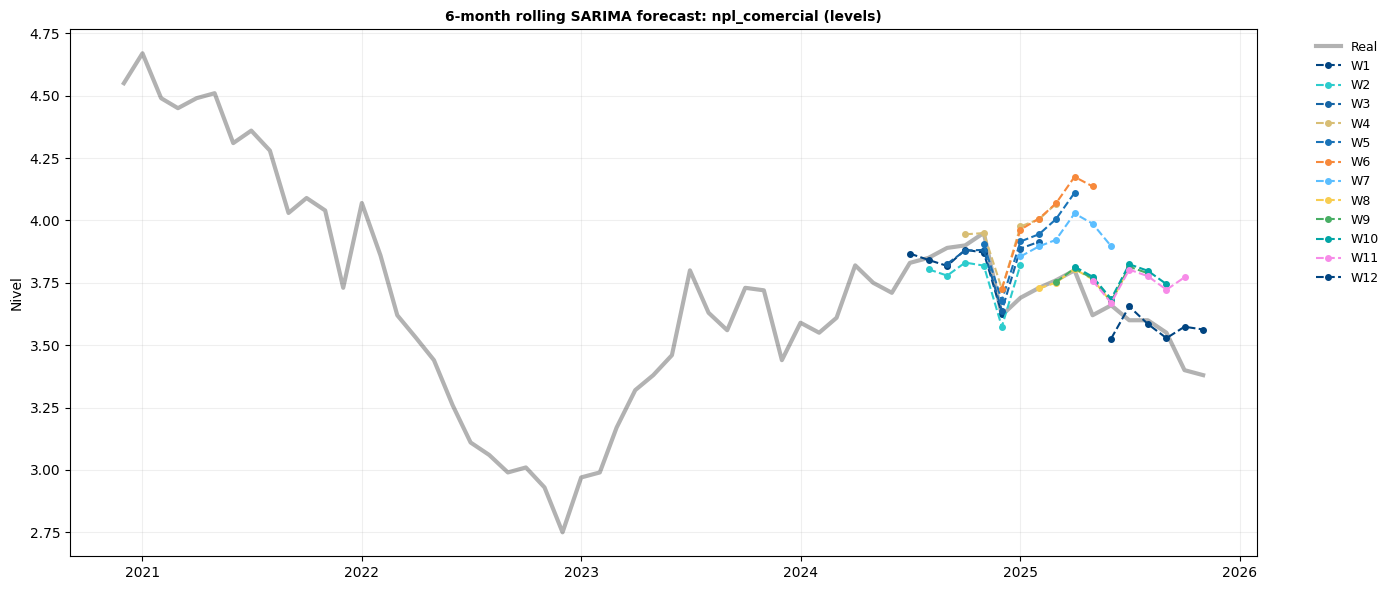

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.04,0.09,0.09,0.17,0.18,0.31,0.22,0.06,0.10,0.14,0.18,0.10,0.140000
RMSE,0.05,0.10,0.12,0.21,0.21,0.33,0.23,0.10,0.13,0.16,0.21,0.12,0.164167
R2,0.80,0.35,0.08,-2.32,-3.11,-23.34,-13.73,-1.04,-1.77,-3.04,-5.24,-0.28,-4.386667
MAPE (%),0.94,2.33,2.45,4.56,4.89,8.35,5.98,1.78,2.68,3.76,5.07,2.79,3.798333


In [ ]:
ORDER = (3,1,0)
SEASONAL_ORDER = (3,0,1,12)
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_name="SARIMA", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
#rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
#forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMA {ORDER} {SEASONAL_ORDER} (2025 rolling-window validation)")

#### Autoregression with exog

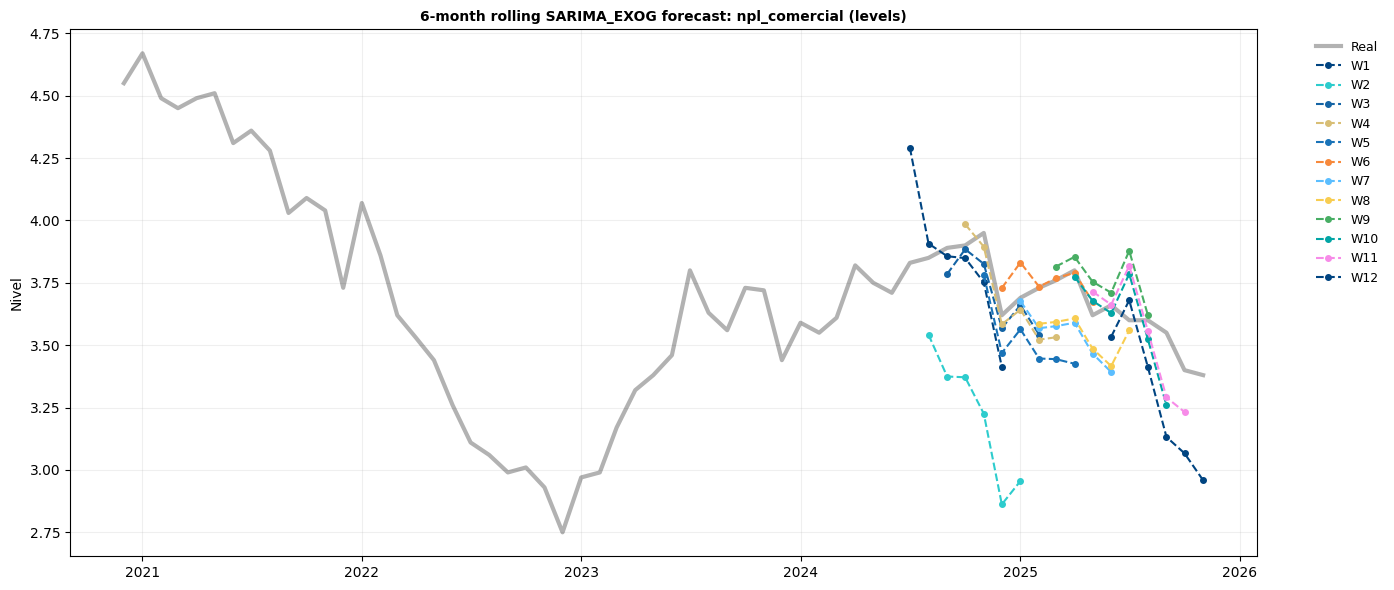

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.17,0.59,0.09,0.11,0.24,0.05,0.17,0.15,0.10,0.11,0.13,0.26,0.180833
RMSE,0.22,0.62,0.10,0.13,0.25,0.08,0.18,0.17,0.13,0.15,0.16,0.29,0.206667
R2,-3.52,-25.51,0.27,-0.37,-5.14,-0.29,-8.07,-4.09,-1.80,-2.45,-2.69,-6.83,-5.040833
MAPE (%),4.41,15.66,2.25,2.92,6.28,1.50,4.45,4.14,2.72,3.10,3.70,7.49,4.885000


In [ ]:
"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)
"""
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_name="SARIMA_EXOG", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

#### Linear regression

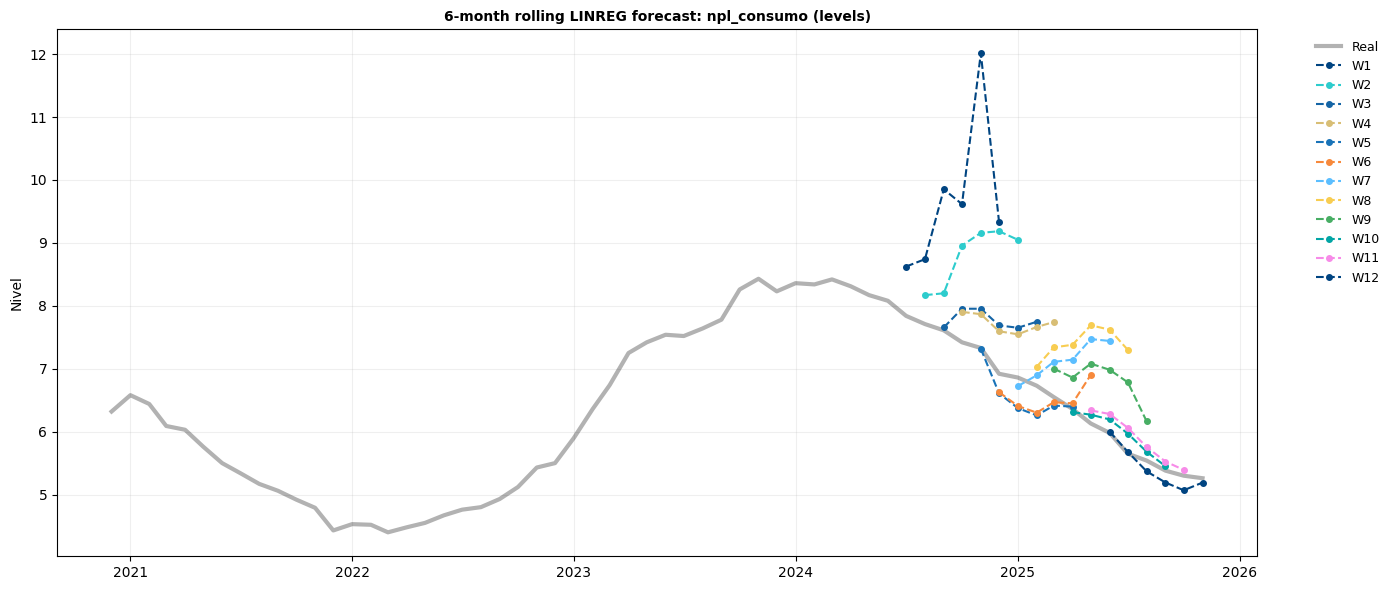

'\ny_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\n\nprint("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)\nprint("Train since:", NPL_DATA.index[0])\nprint(NPL_DATA.columns)\nforecast_plot(target[TARGET], y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")\nrolling_2025 = rolling_validation_2025(data=NPL_DATA,\n                                       target_var=TARGET,\n                                       model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")\n'

In [ ]:
# LINEAR REGRESSION
LAGS = 12
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_name="LINREG", model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
"""
y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(target[TARGET], y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")
"""

#### Linear regression ensemble

Fitting model since 1995-12-01 00:00:00
Fitting model since 1997-03-01 00:00:00
Fitting model since 1999-01-01 00:00:00
Fitting model since 2000-07-01 00:00:00
Fitting model since 2002-12-01 00:00:00
Fitting model since 2006-07-01 00:00:00
Fitting model since 2011-02-01 00:00:00
Fitting model since 2015-07-01 00:00:00
Fitting model since 2017-02-01 00:00:00
Fitting model since 2018-03-01 00:00:00
Fitting model since 2022-01-01 00:00:00
                rmse    weight
start_date                    
1995-12-01  1.831791  0.005238
1997-03-01  0.816095  0.026391
1999-01-01  0.459094  0.083395
2000-07-01  0.151124  0.769612
2002-12-01  0.764093  0.030106
2006-07-01  1.023765  0.016770
2011-02-01  2.007250  0.004363
2015-07-01  0.539140  0.060470
2017-02-01  2.703727  0.002404
2018-03-01  4.412832  0.000903
2022-01-01  7.099849  0.000349
Fitting model since 1995-12-01 00:00:00
Fitting model since 1997-03-01 00:00:00
Fitting model since 1999-01-01 00:00:00
Fitting model since 2000-07-01 00:00:

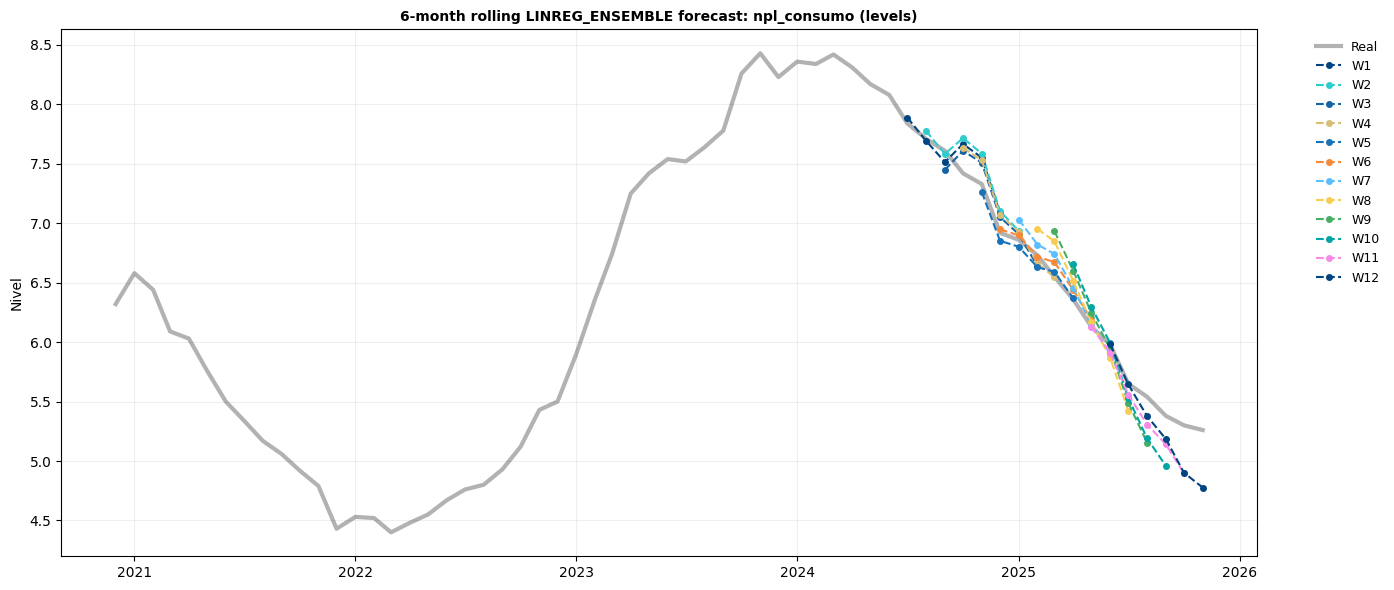

'\ny_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")\n\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,"weighs_power": 2.0})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Linear Regression Ensemble (2025 rolling-window validation)")\n'

In [ ]:
LAGS = 12
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_name="LINREG_ENSEMBLE", model_kwargs={"n_lags": LAGS,"weighs_power": 2.0})
"""
y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")

rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,"weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Linear Regression Ensemble (2025 rolling-window validation)")
"""

#### Ridge Regression

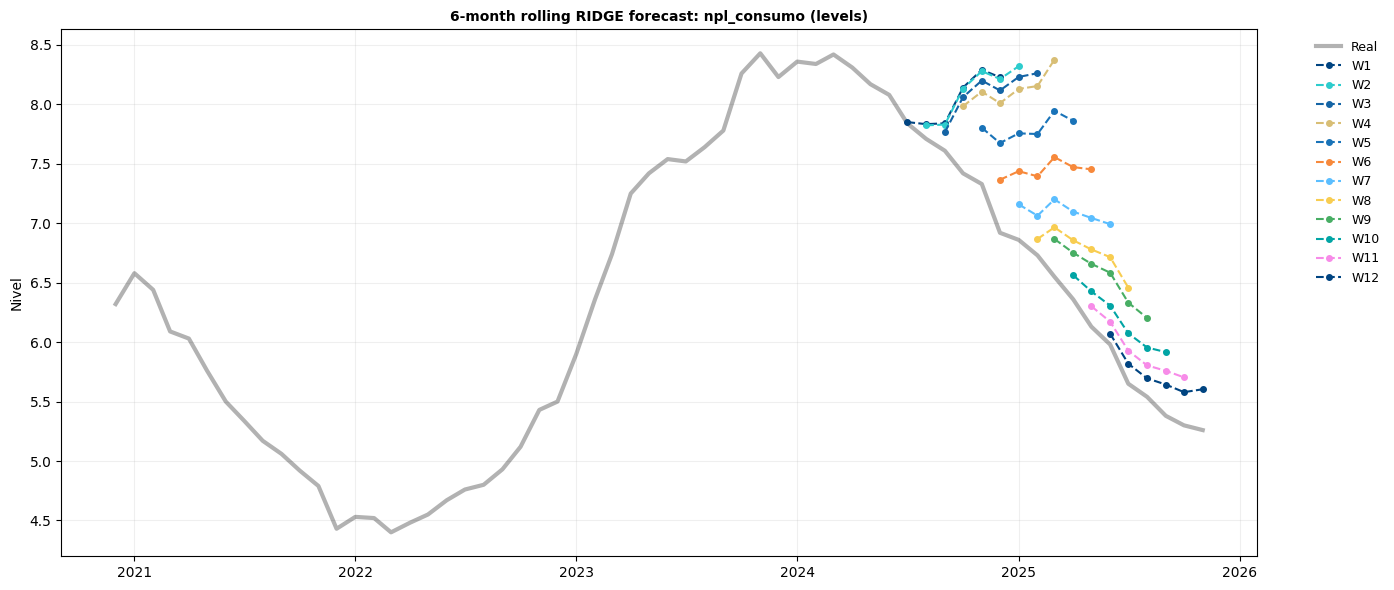

'\nrolling_2025 = rolling_validation_2025(data=NPL_DATA,\n                                       target_var=TARGET,\n                                       model_fn=multivariate_ridge_regression,\n                                       model_kwargs={"n_lags": LAGS,\n                                                     "alpha": 2.0})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")\n'

In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_ridge_regression, model_name="RIDGE", model_kwargs={"n_lags": LAGS, "alpha": 2.0})
"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")
"""

#### Ridge Regression ensemble

In [49]:
NPL_DATA.iloc[-50:]

,npl_comercial,bruta_comercial_lag16,ise_terc_des_lag6,ipi_lag6,pol_mon_lag14,cred_comercial_lag11,conf_indust_lag24,tarj_nat_inter_compra_lag17,inflacion_lag20,bbva_cons_alim_real_lag24,covid
date,,,,,,,,,,,
2021-10-01,-0.62,11.44,20.22,39.91,2.00,6.52,5.678,-1.45,0.71,NaN,1
2021-11-01,-0.76,10.27,15.44,6.38,1.75,6.11,1.335,-11.06,0.63,NaN,1
2021-12-01,-0.82,8.78,17.32,13.90,1.75,6.51,8.481,-12.86,0.26,NaN,1
2022-01-01,-0.60,7.31,15.77,13.58,1.75,6.10,12.188,-16.78,-0.46,NaN,1
2022-02-01,-0.63,6.67,14.47,15.75,1.75,6.19,9.781,-15.95,-1.22,16.02,0
2022-03-01,-0.83,4.32,15.83,13.74,1.75,5.80,-34.984,-14.06,-1.82,24.00,0
2022-04-01,-0.96,4.36,12.49,10.09,1.75,5.69,-35.775,-46.34,-1.89,26.66,0
2022-05-01,-1.07,4.52,11.16,12.70,1.75,6.17,-21.333,-69.52,-1.84,31.00,0
2022-06-01,-1.05,3.68,11.19,10.65,1.75,6.15,-20.823,-15.41,-2.12,33.45,0


Fitting model since 2002-01-01 00:00:00
Ridge alpha=2.0 Intercept: -1.2563041844549581e-17
Ridge Coefficients (scaled X space):
bruta_comercial_lag16   -0.001043
pol_mon_lag14           -0.039706
conf_indust_lag24        0.032255
inflacion_lag20          0.000733
covid                   -0.025015
y_lag1                   0.762931
y_lag2                   0.161958
y_lag3                   0.166465
y_lag4                  -0.154868
y_lag5                   0.000904
y_lag6                   0.106234
y_lag7                  -0.004948
y_lag8                   0.016308
y_lag9                   0.023606
y_lag10                  0.013927
y_lag11                 -0.111683
y_lag12                 -0.054041
Name: coef_scaled_space, dtype: float64
Fitting model since 2003-04-01 00:00:00
Ridge alpha=2.0 Intercept: -6.014462809340263e-19
Ridge Coefficients (scaled X space):
bruta_comercial_lag16   -0.028530
pol_mon_lag14            0.010393
cred_comercial_lag11    -0.027577
conf_indust_lag24        

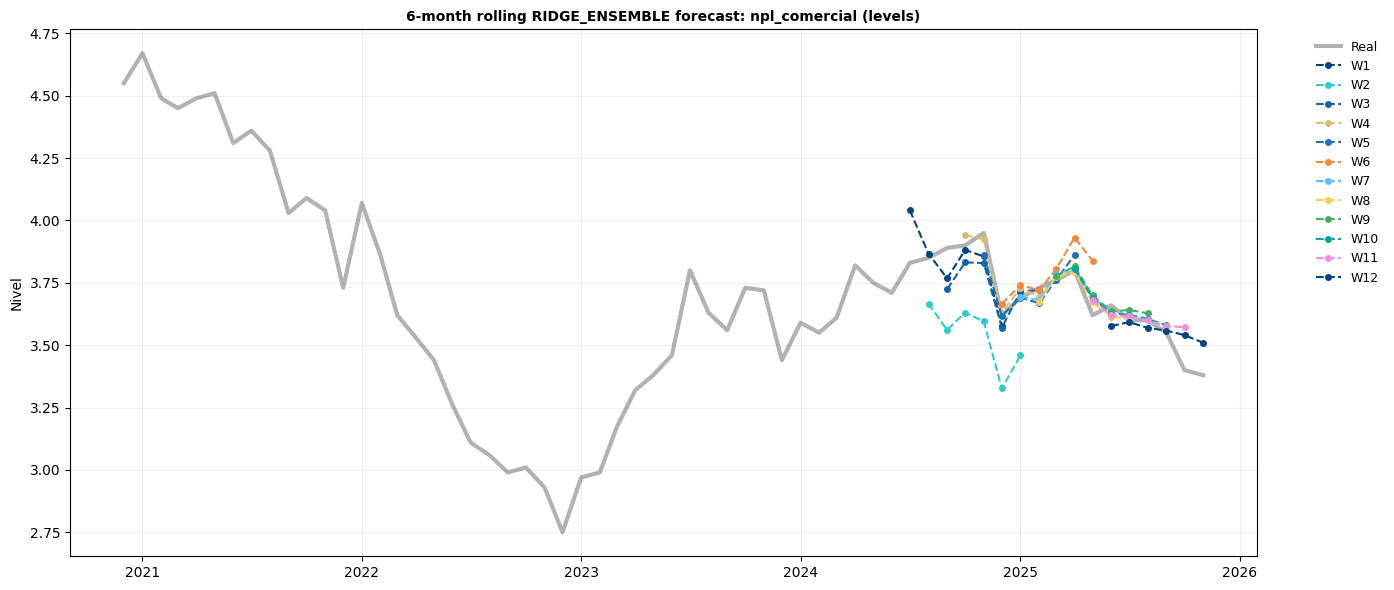

'\nrolling_2025 = rolling_validation_2025(data=NPL_DATA,\n                                       target_var=TARGET,\n                                       model_fn=ridge_regression_ensemble,\n                                       model_kwargs={"n_lags": LAGS,\n                                                     "alpha": 1.0,\n                                                     "weighs_power": 10.0})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")\n'

In [47]:
LAGS = 12
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=ridge_regression_ensemble, model_name="RIDGE_ENSEMBLE", model_kwargs={"n_lags": LAGS, "alpha": 2.0})
"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")
"""

#### Quantile regression

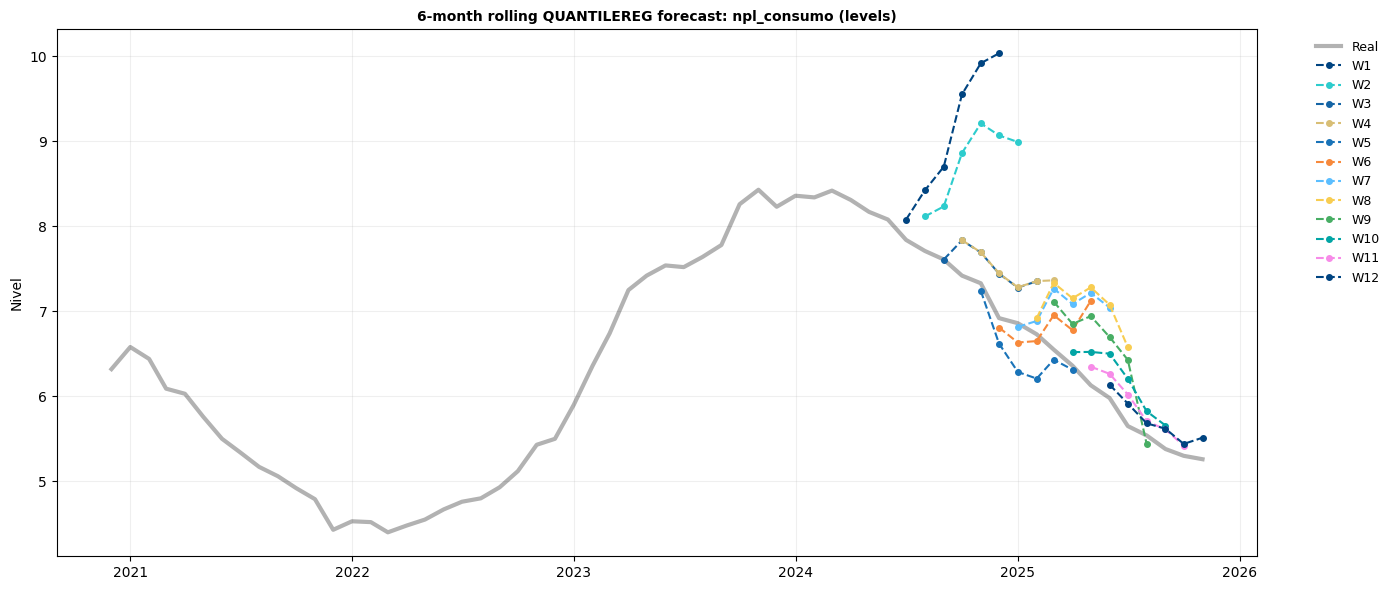

'\nrolling_2025 = rolling_validation_2025(data=NPL_DATA,\n                                       target_var=TARGET,\n                                       model_fn=quantile_regressor,\n                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")\n'

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {"quantile": 0.5}
rolling_validation_12_windows(data=NPL_DATA,
                              target_var=TARGET,
                              model_name="QUANTILEREG",
                              model_fn=quantile_regressor,
                              model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})

"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")
"""

#### Random forest

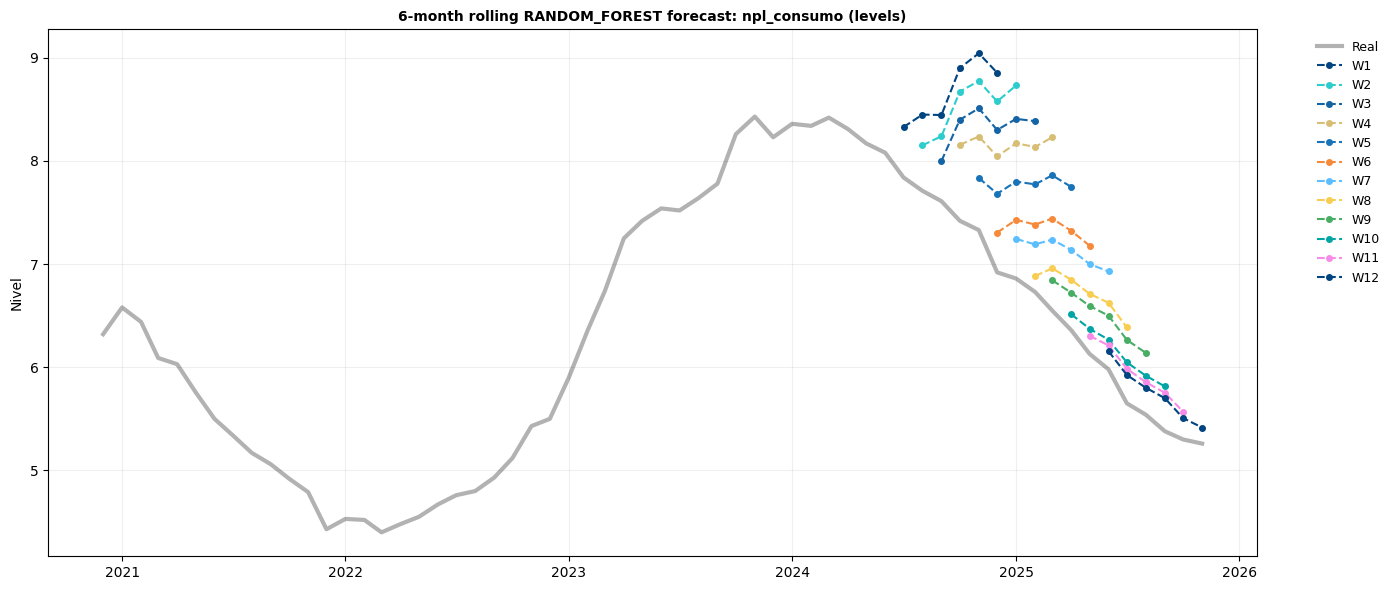

'\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,\n                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")\n'

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_name="RANDOM_FOREST", model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS, "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")
"""

#### Extra trees regressor

Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparamete

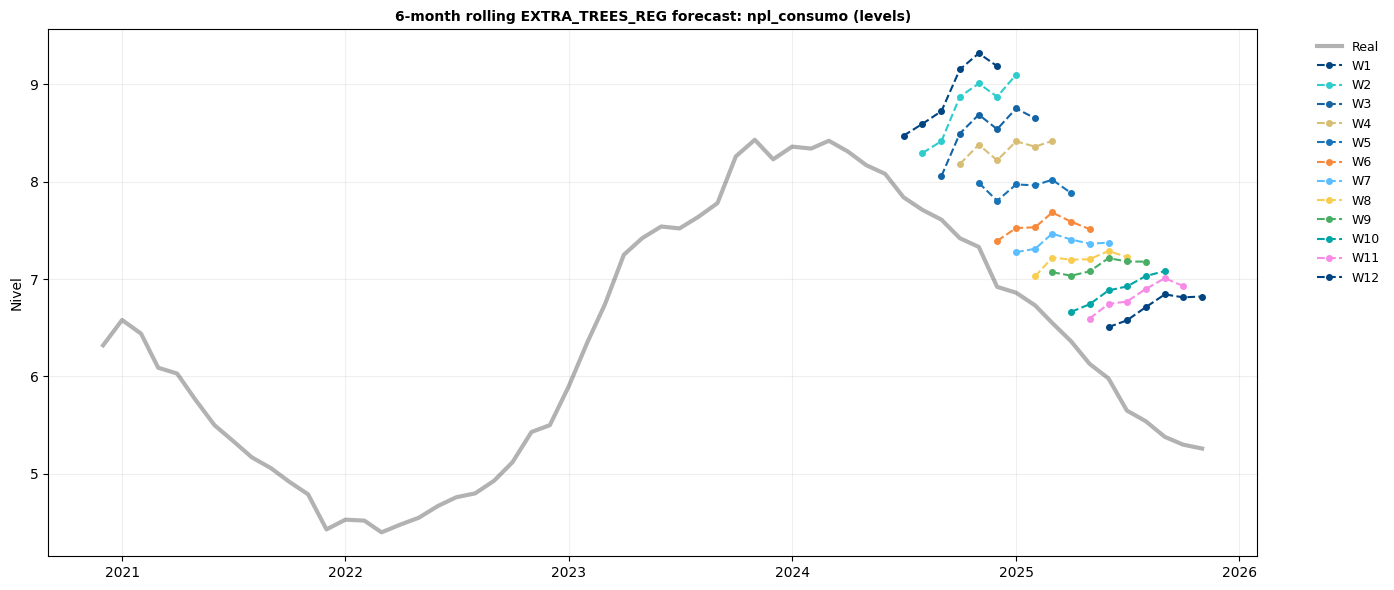

'\ny_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\nprint("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)\nprint("Train since:", NPL_DATA.index[0])\nprint(NPL_DATA.columns)\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")\n'

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 4,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_name="EXTRA_TREES_REG", model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS, "hyperparams": HYPERPARAMETERS_EXTRATREES})
"""
y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")
"""

Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}


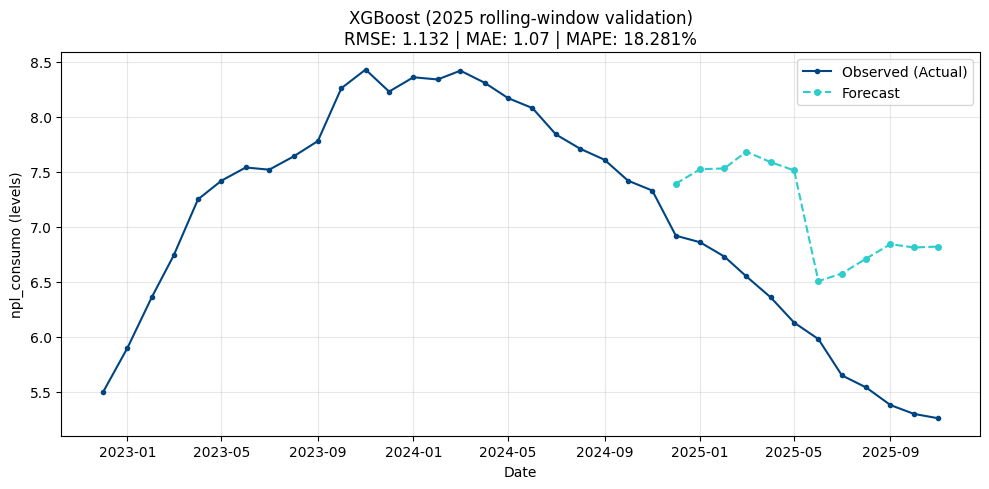

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 

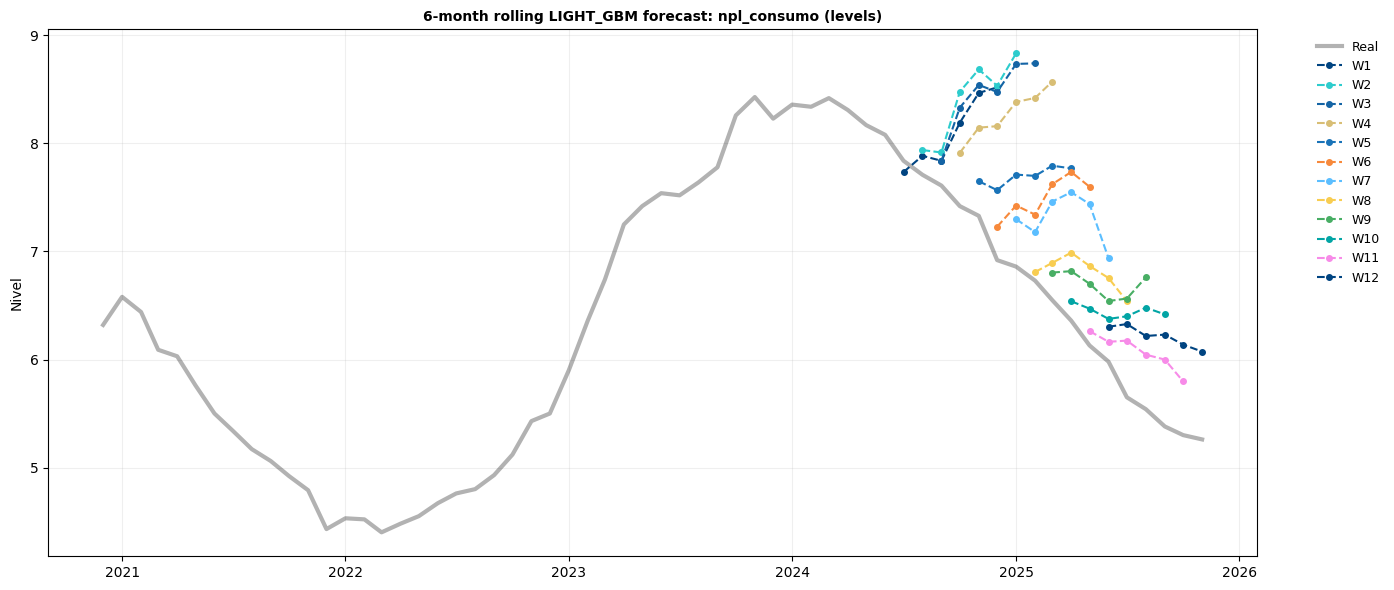

'\ny_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")\n\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,\n                                                                                                                    "hyperparams": HYPERPARAMETERS_LIGHTGBM})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")\n'

In [ ]:
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_name="LIGHT_GBM", model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS, "hyperparams": HYPERPARAMETERS_LIGHTGBM})
"""
y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_LIGHTGBM})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")
"""


#### Chronos-2

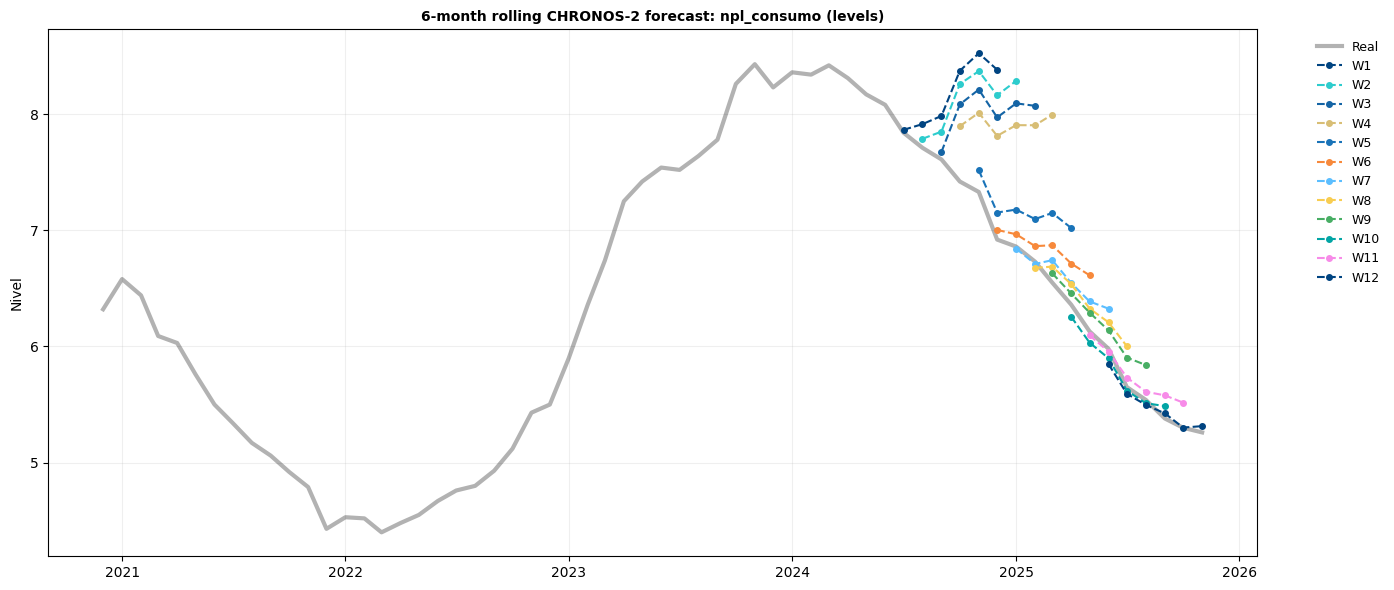

'\ny_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")\n'

In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_name="CHRONOS-2", model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
"""
y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")
"""

#### LSTM

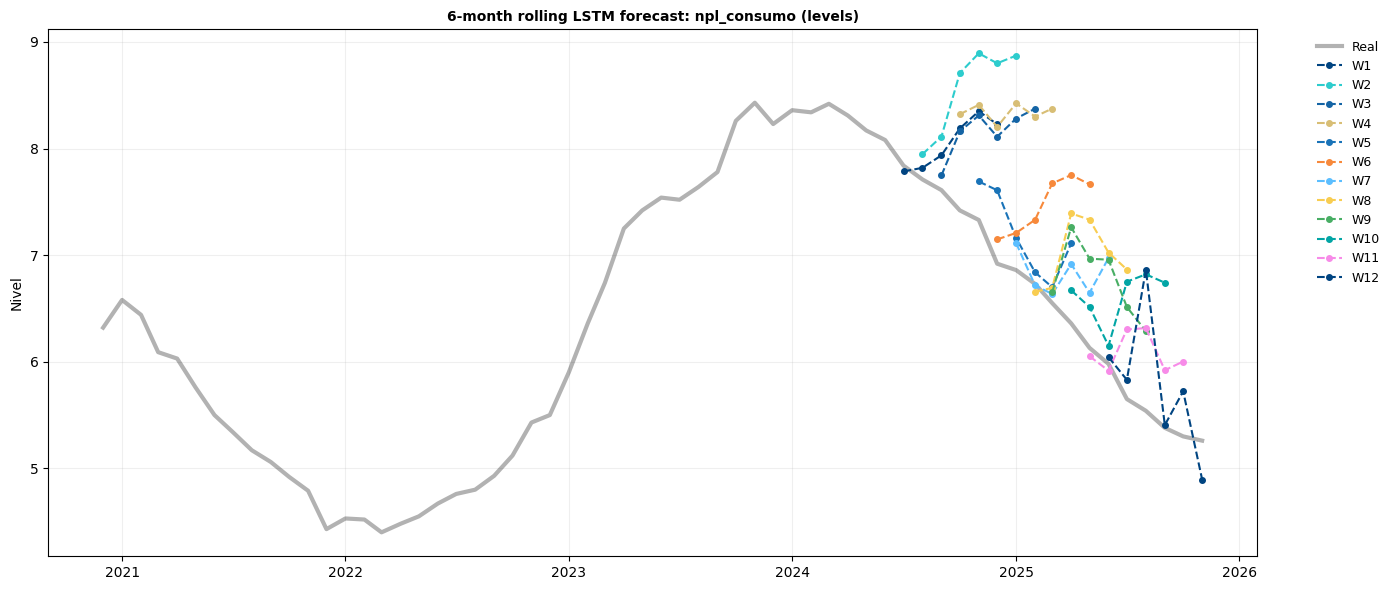

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.60,1.25,1.02,1.37,0.39,0.87,0.40,0.79,0.74,0.77,0.47,0.40,0.755833
RMSE,0.76,1.41,1.13,1.41,0.46,1.01,0.52,0.92,0.79,0.91,0.55,0.59,0.871667
R2,-5.43,-18.44,-11.18,-19.44,-1.31,-12.03,-1.79,-5.56,-3.88,-5.99,-2.34,-4.76,-7.679167
MAPE (%),8.26,17.48,14.59,19.90,5.83,13.56,6.50,13.02,12.42,13.65,8.53,7.25,11.749167


In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}
"""
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)
"""
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_name="LSTM", model_kwargs={"n_lags": 12, "hyperparams": LSTM_HYPERPARAMETERS})

#### Bayesian Structual Time Series (BSTS)

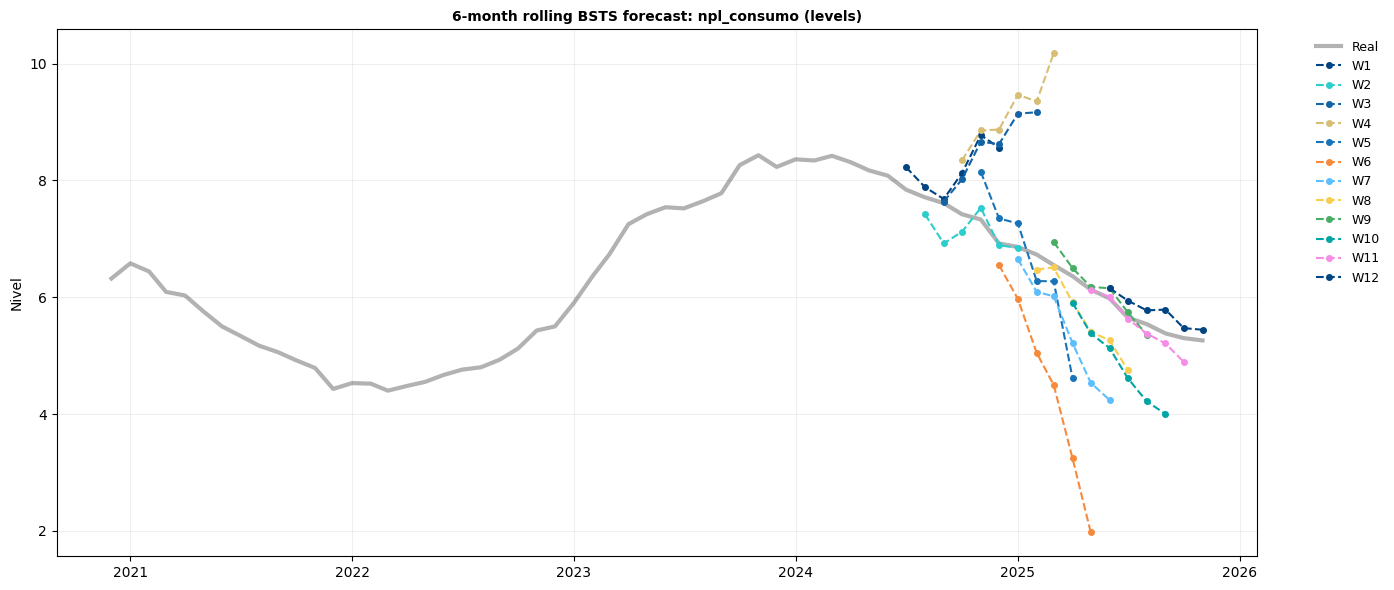

'\ny_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\nprint("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)\nprint("Train since:", NPL_DATA.index[0])\nprint(NPL_DATA.columns)\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")\n\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,\n                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")\nprint(LSTM_HYPERPARAMETERS)\n'

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 2
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_name="BSTS", model_kwargs={"n_lags": LAGS, "hyperparams": HYPERPARAMETERS_BSTS})
"""
y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)
"""

#### Resultados

In [ ]:
RESULTS_FORECASTS

,npl_consumo_SARIMA_w1,npl_consumo_SARIMA_w2,npl_consumo_SARIMA_w3,npl_consumo_SARIMA_w4,npl_consumo_SARIMA_w5,npl_consumo_SARIMA_w6,npl_consumo_SARIMA_w7,npl_consumo_SARIMA_w8,npl_consumo_SARIMA_w9,npl_consumo_SARIMA_w10,...,npl_consumo_BSTS_w3,npl_consumo_BSTS_w4,npl_consumo_BSTS_w5,npl_consumo_BSTS_w6,npl_consumo_BSTS_w7,npl_consumo_BSTS_w8,npl_consumo_BSTS_w9,npl_consumo_BSTS_w10,npl_consumo_BSTS_w11,npl_consumo_BSTS_w12
2002-01-01,7.85,7.85,7.85,7.85,7.85,7.85,7.85,7.850000,7.850000,7.850000,...,7.85,7.85,7.85,7.85,7.85,7.850000,7.850000,7.850000,7.850000,7.850000
2002-02-01,8.21,8.21,8.21,8.21,8.21,8.21,8.21,8.210000,8.210000,8.210000,...,8.21,8.21,8.21,8.21,8.21,8.210000,8.210000,8.210000,8.210000,8.210000
2002-03-01,8.57,8.57,8.57,8.57,8.57,8.57,8.57,8.570000,8.570000,8.570000,...,8.57,8.57,8.57,8.57,8.57,8.570000,8.570000,8.570000,8.570000,8.570000
2002-04-01,7.78,7.78,7.78,7.78,7.78,7.78,7.78,7.780000,7.780000,7.780000,...,7.78,7.78,7.78,7.78,7.78,7.780000,7.780000,7.780000,7.780000,7.780000
2002-05-01,7.53,7.53,7.53,7.53,7.53,7.53,7.53,7.530000,7.530000,7.530000,...,7.53,7.53,7.53,7.53,7.53,7.530000,7.530000,7.530000,7.530000,7.530000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.494942,6.202679,6.010284,...,NaN,NaN,NaN,NaN,NaN,4.754941,5.740211,4.612160,5.629506,5.941784
2025-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.227254,6.026486,...,NaN,NaN,NaN,NaN,NaN,NaN,5.358457,4.218611,5.377849,5.774756
2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.045310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.999550,5.208820,5.787515
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.892150,5.470610


In [ ]:
RESULTS_METRICS

,npl_consumo_SARIMA,npl_consumo_SARIMA_EXOG,npl_consumo_LINREG,npl_consumo_LINREG_ENSEMBLE,npl_consumo_RIDGE,npl_consumo_RIDGE_ENSEMBLE,npl_consumo_QUANTILEREG,npl_consumo_RANDOM_FOREST,npl_consumo_EXTRA_TREES_REG,npl_consumo_LIGHT_GBM,npl_consumo_CHRONOS-2,npl_consumo_LSTM,npl_consumo_BSTS
MAE,0.487500,0.470833,0.738333,0.147500,0.661667,0.085000,0.623333,0.753333,1.176667,0.834167,0.395000,0.755833,0.860833
RMSE,0.555833,0.534167,0.832500,0.175000,0.725000,0.095833,0.706667,0.796667,1.255833,0.927500,0.450833,0.871667,0.995833
R2,-2.370000,-3.687500,-10.735833,0.631667,-5.431667,0.887500,-6.804167,-7.232500,-15.921667,-8.825000,-2.437500,-7.679167,-15.987500
MAPE (%),7.550000,7.002500,11.067500,2.350833,10.140000,1.275000,9.416667,11.330833,18.469167,12.952500,5.856667,11.749167,13.235000


In [ ]:
RESULTS_METRICS.to_excel("results_metrics_nplconsumo_noproc.xlsx")
RESULTS_FORECASTS.to_excel("results_forecasts_nplconsumo_noproc.xlsx")

### **NPL Consumo**

#### Variable selection

In [50]:
# SELECCIÓN EQUIPO (TARGET VS. REGRESSORS_PROC)
if TARGET_LOGITDIFF_TRANSF == True:
  data_consumo_npl = target_logit_diff[["npl_consumo"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_consumo_npl = target[["npl_consumo"]].copy(deep=True)
  print("Target did not have transformation.")
data_consumo_npl["bruta_consumo_lag15"] = regressors["bruta_consumo"].shift(15)
data_consumo_npl["ipi_lag6"] = regressors["ipi"].shift(6)
data_consumo_npl["ise_terc_des_lag6"] = regressors["ise_terc_des"].shift(6)
data_consumo_npl["ventas_minor_lag6"] = regressors["ventas_minor"].shift(6)
data_consumo_npl["pol_mon_lag12"] = regressors["pol_mon"].shift(12)
data_consumo_npl["tarj_nat_inter_compra_lag13"] = regressors["tarj_nat_inter_compra"].shift(13)
data_consumo_npl["inflacion_lag18"] = regressors["inflacion"].shift(18)
data_consumo_npl["conf_comercial_lag6"] = regressors["conf_comercial"].shift(6)
data_consumo_npl["cred_consumo_lag7"] = regressors["cred_consumo"].shift(7)
data_consumo_npl["bbva_cons_alim_real_lag23"] = regressors["bbva_cons_total_real"].shift(23)
data_consumo_npl["gdelt_5_lag13"] = regressors["gdelt_5"].shift(13)
data_consumo_npl["google_consumo_pc_lag13"] = regressors["google_consumo_pc"].shift(13)
data_consumo_npl.dropna(how="all", inplace=True)

#data_consumo_npl = add_missing_flags(data_consumo_npl, "npl_consumo")
#data_consumo_npl = add_fourier_terms(data_consumo_npl, period=12, K=6)
data_consumo_npl = add_covid_dummy(data_consumo_npl, covid_dates=COVID_DATES)
data_consumo_npl.tail()

Target did not have transformation.


,npl_consumo,bruta_consumo_lag15,ipi_lag6,ise_terc_des_lag6,ventas_minor_lag6,pol_mon_lag12,tarj_nat_inter_compra_lag13,inflacion_lag18,conf_comercial_lag6,cred_consumo_lag7,bbva_cons_alim_real_lag23,gdelt_5_lag13,google_consumo_pc_lag13,covid
date,,,,,,,,,,,,,,
2025-07-01,-2.19,-4.28,-0.14,3.17,12.69,10.75,-16.85,-4.90,21.61,17.84,6.98,0.19,2.2,0
2025-08-01,-2.17,-4.61,-2.11,3.85,10.18,10.75,-21.93,-5.54,24.51,17.82,7.39,-0.11,1.8,0
2025-09-01,-2.23,-4.75,1.76,3.67,14.76,10.25,-23.21,-5.97,12.23,18.23,6.07,0.40,2.3,0
2025-10-01,-2.12,-4.88,-4.70,3.13,15.24,9.75,-25.28,-5.65,24.90,17.56,4.41,0.30,2.3,0
2025-11-01,-2.07,-5.12,-0.04,3.98,16.32,9.75,-23.49,-5.22,20.96,18.05,7.03,0.40,3.4,0


In [51]:
# SELECCIÓN CARMEN (TARGET_PROC VS. REGRESSORS_PROC)
"""
if TARGET_LOGITDIFF_TRANSF == True:
  data_consumo_npl = target_logit_diff[["npl_consumo"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_consumo_npl = target[["npl_consumo"]].copy(deep=True)
  print("Target did not have transformation.")
data_consumo_npl["bruta_consumo_lag15"] = regressors["bruta_consumo"].shift(15)
data_consumo_npl["ise_terc_comercio_des_lag19"] = regressors["ise_terc_comercio_des"].shift(19)
data_consumo_npl["pol_mon_lag6"] = regressors["pol_mon"].shift(6)
data_consumo_npl["cred_consumo_lag24"] = regressors["cred_consumo"].shift(24)
data_consumo_npl["coloc_total_lag24"] = regressors["coloc_total"].shift(24)
data_consumo_npl["conf_indust_lag19"] = regressors["conf_indust"].shift(19)
data_consumo_npl["ventas_minor_lag23"] = regressors["ventas_minor"].shift(23)
data_consumo_npl["tarj_nat_inter_compra_lag8"] = regressors["tarj_nat_inter_compra"].shift(8)
data_consumo_npl["empl_desocupacion_ciud_lag19"] = regressors["empl_desocupacion_ciud"].shift(19)
data_consumo_npl["inflacion_lag14"] = regressors["inflacion"].shift(14)

data_consumo_npl = data_consumo_npl["2002":].dropna(how="all")

data_consumo_npl = add_covid_dummy(data_consumo_npl, covid_dates=COVID_DATES)
data_consumo_npl.tail()
"""

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_consumo_npl = target_logit_diff[["npl_consumo"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_consumo_npl = target[["npl_consumo"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_consumo_npl["bruta_consumo_lag15"] = regressors["bruta_consumo"].shift(15)\ndata_consumo_npl["ise_terc_comercio_des_lag19"] = regressors["ise_terc_comercio_des"].shift(19)\ndata_consumo_npl["pol_mon_lag6"] = regressors["pol_mon"].shift(6)\ndata_consumo_npl["cred_consumo_lag24"] = regressors["cred_consumo"].shift(24)\ndata_consumo_npl["coloc_total_lag24"] = regressors["coloc_total"].shift(24)\ndata_consumo_npl["conf_indust_lag19"] = regressors["conf_indust"].shift(19)\ndata_consumo_npl["ventas_minor_lag23"] = regressors["ventas_minor"].shift(23)\ndata_consumo_npl["tarj_nat_inter_compra_lag8"] = regressors["tarj_nat_inter_compra"].shift(8)\ndata_consumo_npl["empl_desocupacion_ciud_lag19"] =

In [52]:
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_consumo_npl = target_logit_diff[["npl_consumo"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_consumo_npl = target[["npl_consumo"]].copy(deep=True)
  print("Target did not have transformation.")
data_consumo_npl["bruta_consumo_lag12"] = regressors["bruta_consumo"].shift(12)
data_consumo_npl["ipi_lag6"] = regressors["ipi"].shift(6) * -1
data_consumo_npl["ventas_minor_lag23"] = regressors["ventas_minor"].shift(23)
data_consumo_npl["pol_mon_lag24"] = regressors["pol_mon"].shift(24) * -1
data_consumo_npl["coloc_total_lag5"] = regressors["coloc_total"].shift(5)
data_consumo_npl["tes_1a_lag7"] = regressors["tes_1a"].shift(7)  # OPCIONAL
data_consumo_npl["pobl_nopartic_glob_lag23"] = regressors["pobl_nopartic_glob_des"].shift(23) * -1 # OPCIONAL
data_consumo_npl["tarj_nat_inter_compra_lag11"] = regressors["tarj_nat_inter_compra"].shift(11)  # OPCIONAL
data_consumo_npl["tarj_nat_canc_lag12"] = regressors["tarj_nat_canc"].shift(12)  # OPCIONAL
data_consumo_npl["vivienda_utv_lag1"] = regressors["vivienda_utv"].shift(1)  # OPCIONAL
data_consumo_npl["vivienda_ventas_lag1"] = regressors["vivienda_ventas"].shift(1) * -1  # OPCIONAL
data_consumo_npl["bbva_inv_total_real_lag7"] = regressors["bbva_inv_total_real"].shift(7) * -1  # OPCIONAL
data_consumo_npl["bbva_cons_total_real_lag6"] = regressors["bbva_cons_total_real"].shift(6) * -1
data_consumo_npl["gdelt_5_lag13"] = regressors["gdelt_5"].shift(13)

data_consumo_npl = add_missing_flags(data_consumo_npl, "npl_consumo")
data_consumo_npl = add_fourier_terms(data_consumo_npl, period=12, K=6)
data_consumo_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_consumo_npl = target_logit_diff[["npl_consumo"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_consumo_npl = target[["npl_consumo"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_consumo_npl["bruta_consumo_lag12"] = regressors["bruta_consumo"].shift(12)\ndata_consumo_npl["ipi_lag6"] = regressors["ipi"].shift(6) * -1\ndata_consumo_npl["ventas_minor_lag23"] = regressors["ventas_minor"].shift(23)\ndata_consumo_npl["pol_mon_lag24"] = regressors["pol_mon"].shift(24) * -1\ndata_consumo_npl["coloc_total_lag5"] = regressors["coloc_total"].shift(5)\ndata_consumo_npl["tes_1a_lag7"] = regressors["tes_1a"].shift(7)  # OPCIONAL\ndata_consumo_npl["pobl_nopartic_glob_lag23"] = regressors["pobl_nopartic_glob_des"].shift(23) * -1 # OPCIONAL\ndata_consumo_npl["tarj_nat_inter_compra_lag11"] = regressors["tarj_nat_inter_compra"].shift(11)  # OPCIONAL\ndata_consumo_npl["tarj_nat_canc_

In [53]:
# PARAMETERS: NPL CONSUMO
NPL_DATA = data_consumo_npl
TARGET = "npl_consumo"
RESULTS_FORECASTS = pd.DataFrame()
RESULTS_METRICS = pd.DataFrame()

#### Autoregression

Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)


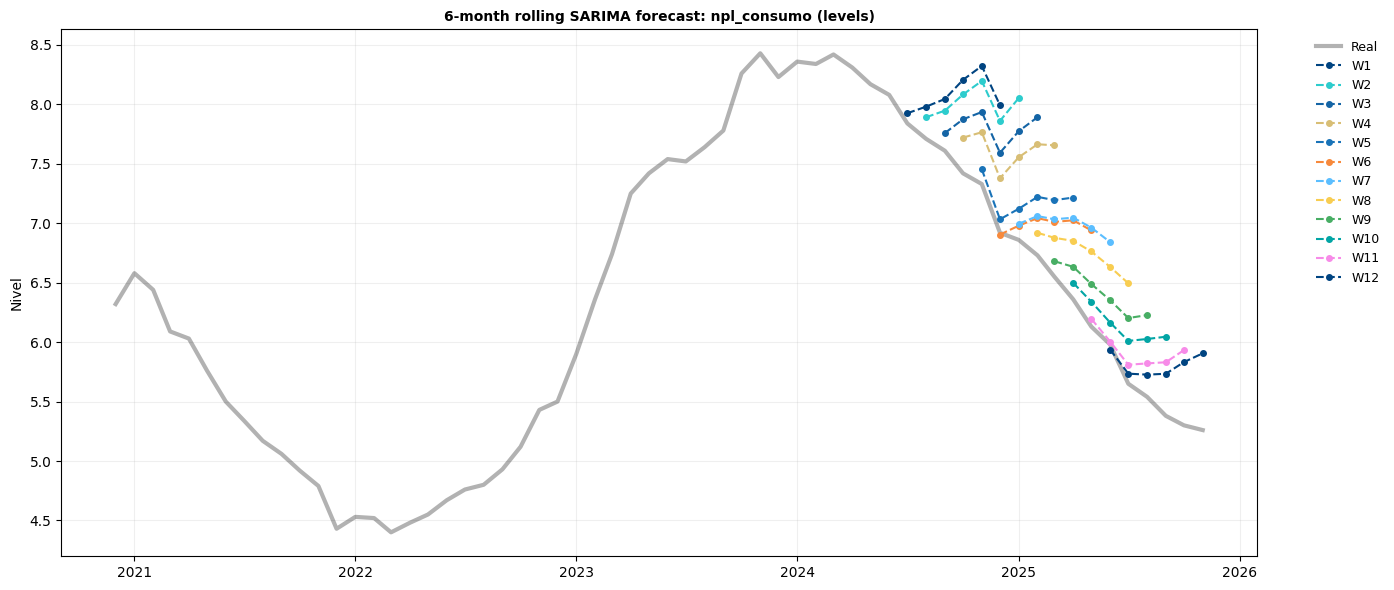

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.61,0.70,0.66,0.66,0.42,0.40,0.56,0.52,0.40,0.34,0.27,0.31,0.487500
RMSE,0.71,0.78,0.73,0.72,0.50,0.49,0.62,0.57,0.44,0.39,0.34,0.38,0.555833
R2,-4.62,-4.91,-4.14,-4.29,-1.66,-2.04,-2.87,-1.47,-0.47,-0.27,-0.31,-1.39,-2.370000
MAPE (%),8.33,9.76,9.45,9.59,6.29,6.22,8.85,8.62,6.76,6.03,4.95,5.75,7.550000


In [ ]:
ORDER = (3,1,0)
SEASONAL_ORDER = (0,0,1,12)
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_name="SARIMA", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)


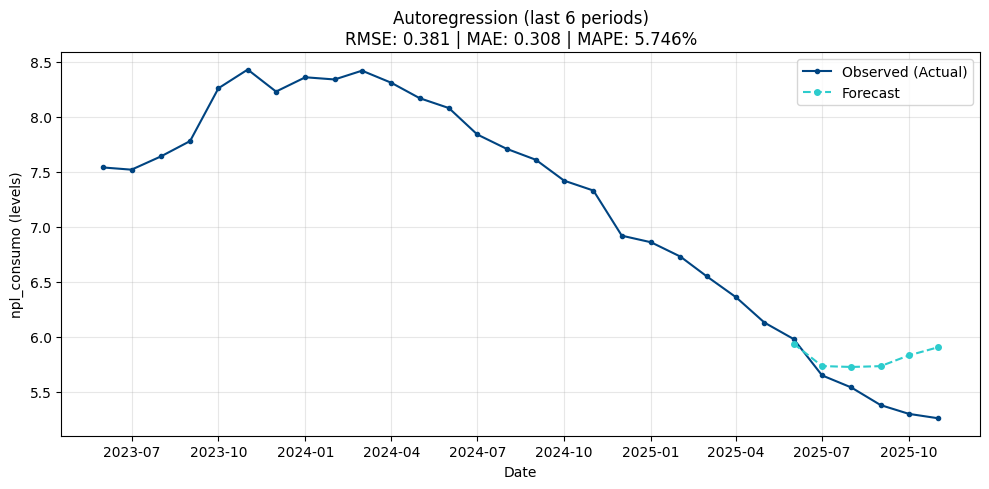

In [ ]:
y_pred = autoregression(NPL_DATA, TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER, test_size=TEST_SIZE)

# Detransform
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

# Plot
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression (last 6 periods)")

Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)
Order: (3, 1, 0)
Seasonal order: (0, 0, 1, 12)


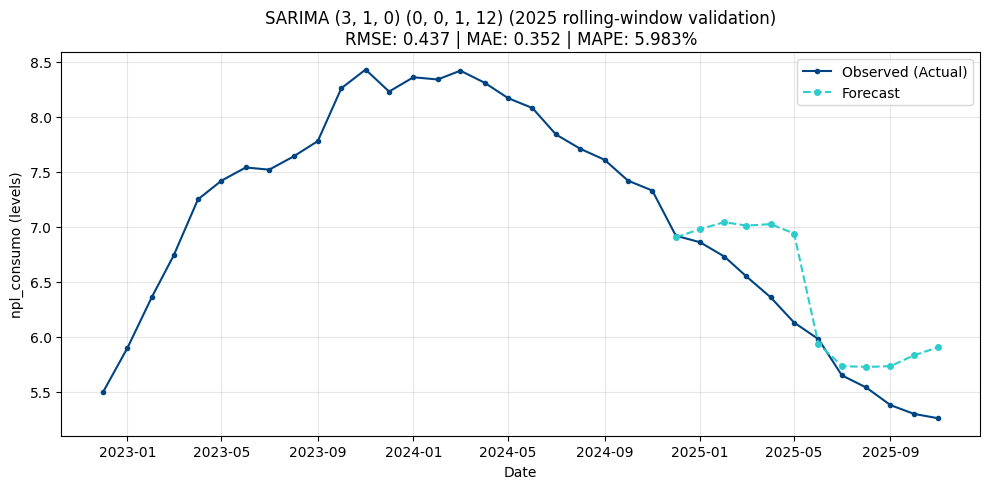

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMA {ORDER} {SEASONAL_ORDER} (2025 rolling-window validation)")

#### Autoregression with exog

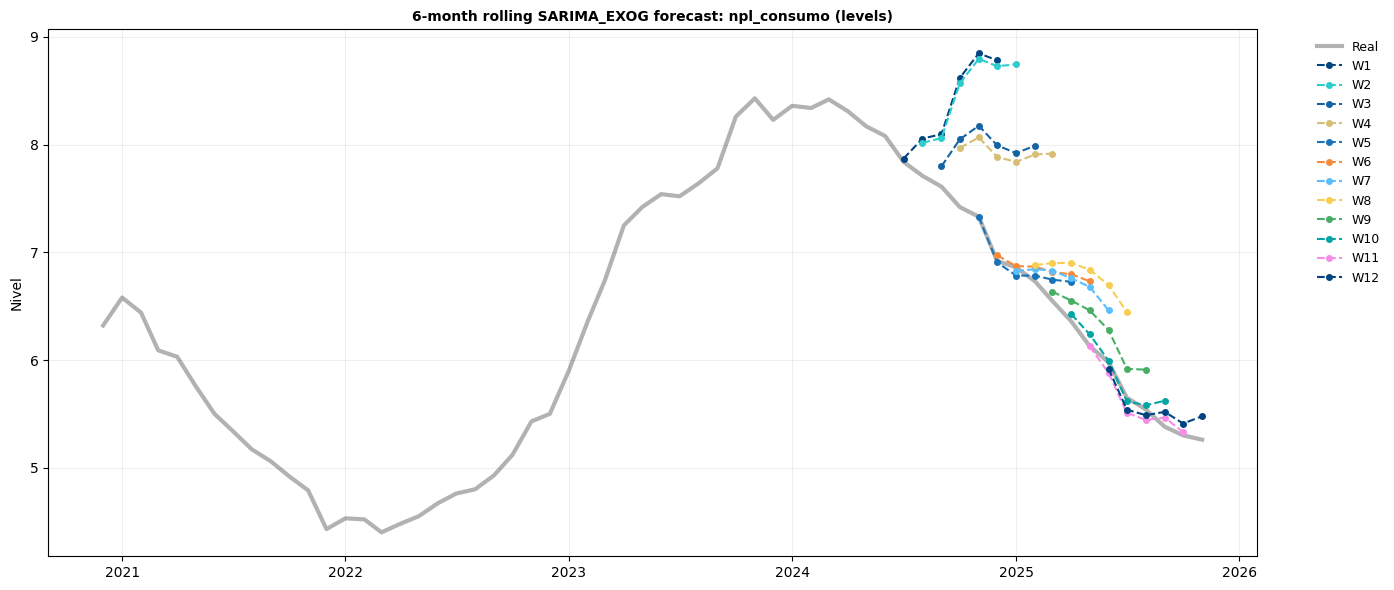

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.91,1.18,0.84,0.96,0.12,0.25,0.31,0.54,0.26,0.08,0.08,0.12,0.470833
RMSE,1.12,1.33,0.91,1.00,0.17,0.33,0.36,0.59,0.27,0.11,0.09,0.13,0.534167
R2,-13.05,-16.16,-6.95,-9.32,0.68,-0.38,-0.34,-1.68,0.42,0.89,0.91,0.73,-3.687500
MAPE (%),12.51,16.50,12.03,14.01,1.81,3.95,4.96,8.96,4.36,1.48,1.34,2.12,7.002500


In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_name="SARIMA_EXOG", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

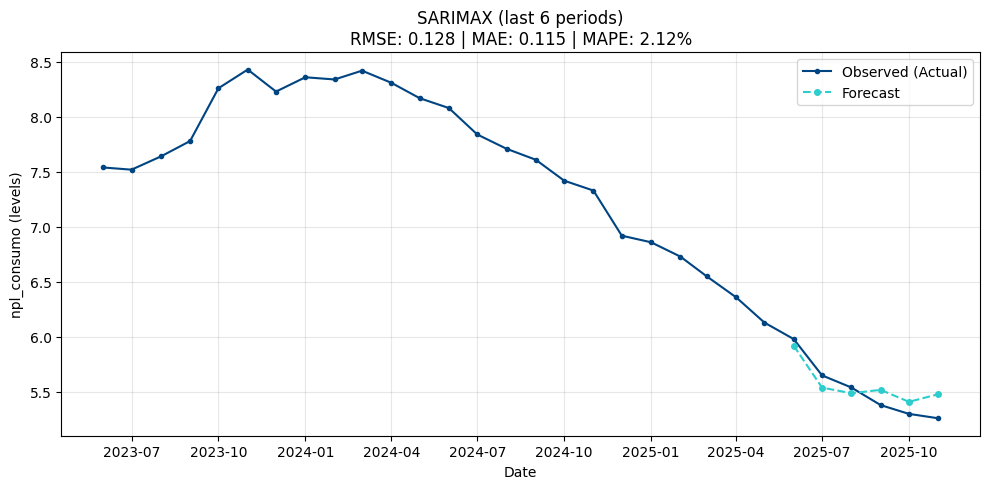

In [ ]:
# AUTOREGRESSION WITH EXOGENOUS VARIABLES

y_pred = autoregression_with_exog(NPL_DATA, target_var=TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER)

if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"SARIMAX (last 6 periods)")

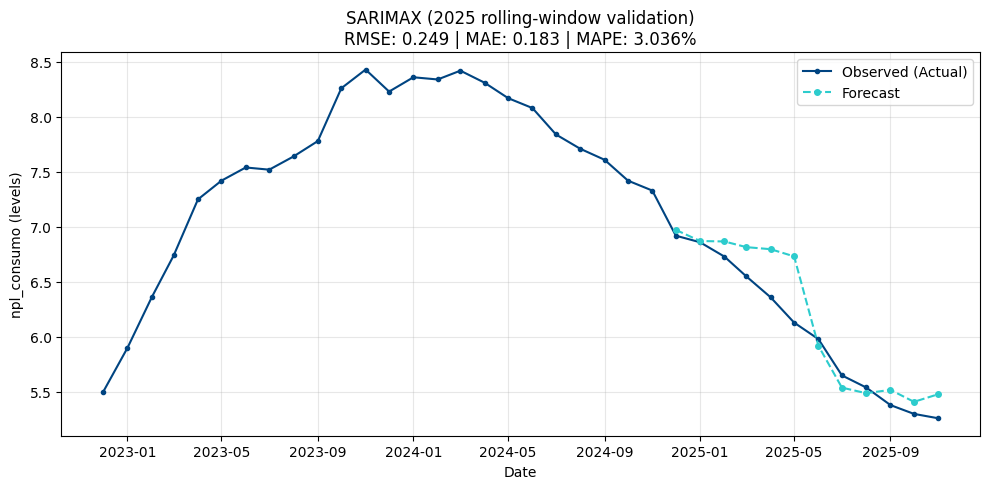

Covariates: Index(['npl_consumo', 'bruta_consumo_lag15', 'ipi_lag6', 'ise_terc_des_lag6',
       'ventas_minor_lag6', 'pol_mon_lag12', 'tarj_nat_inter_compra_lag13',
       'inflacion_lag18', 'conf_comercial_lag6', 'cred_consumo_lag7',
       'bbva_cons_alim_real_lag23', 'gdelt_5_lag13', 'google_consumo_pc_lag13',
       'covid'],
      dtype='object')


In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)

#### Linear regression

Target is tranformed: False
Train since: 1991-12-01 00:00:00
Index(['npl_consumo', 'bruta_consumo_lag15', 'ipi_lag6', 'ise_terc_des_lag6',
       'ventas_minor_lag6', 'pol_mon_lag12', 'tarj_nat_inter_compra_lag13',
       'inflacion_lag18', 'cred_consumo_lag7', 'bbva_cons_alim_real_lag23',
       'gdelt_5_lag13', 'google_consumo_pc_lag13', 'conf_comercial_lag6',
       'covid'],
      dtype='object')


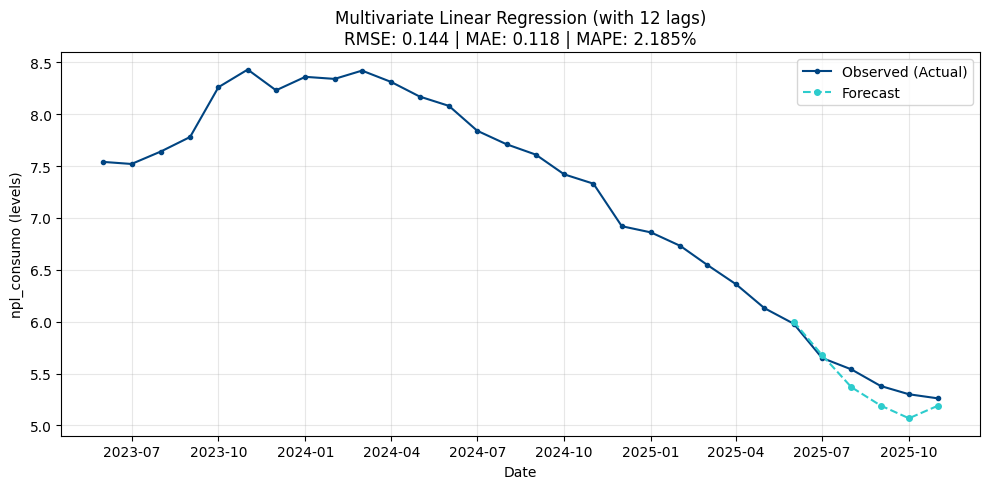

In [ ]:
# LINEAR REGRESSION
LAGS = 12

y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")

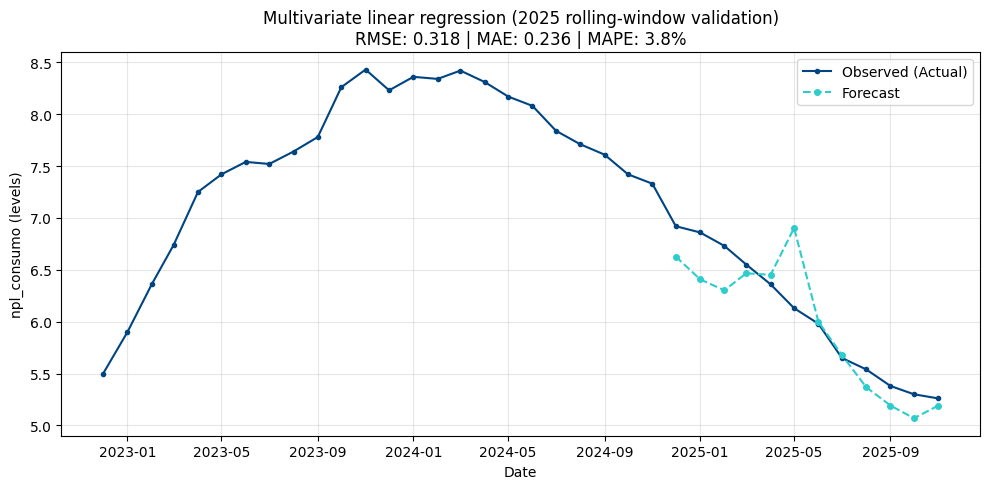

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")

#### Linear regression ensemble

Fitting model since 1995-12-01 00:00:00
Fitting model since 1997-03-01 00:00:00
Fitting model since 1999-01-01 00:00:00
Fitting model since 2000-07-01 00:00:00
Fitting model since 2002-12-01 00:00:00
Fitting model since 2006-07-01 00:00:00
Fitting model since 2011-02-01 00:00:00
Fitting model since 2015-07-01 00:00:00
Fitting model since 2017-02-01 00:00:00
Fitting model since 2018-03-01 00:00:00
Fitting model since 2022-01-01 00:00:00
                rmse    weight
start_date                    
1995-12-01  0.533244  0.107150
1997-03-01  0.269082  0.420796
1999-01-01  1.036583  0.028355
2000-07-01  1.045145  0.027893
2002-12-01  1.104426  0.024979
2006-07-01  1.117326  0.024405
2011-02-01  0.380074  0.210914
2015-07-01  0.926309  0.035508
2017-02-01  2.269726  0.005914
2018-03-01  1.852114  0.008882
2022-01-01  0.538153  0.105204


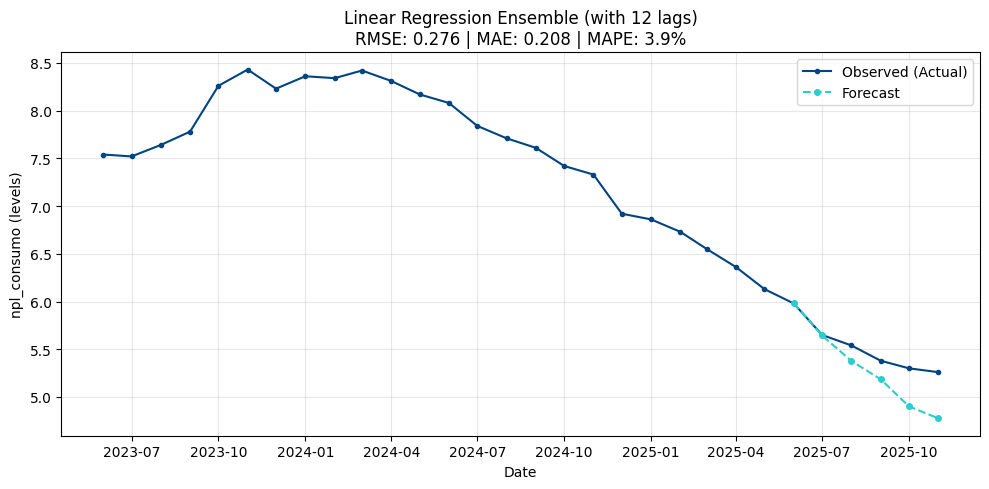

In [ ]:
LAGS = 12

y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")

Fitting model since 1995-12-01 00:00:00
Fitting model since 1997-03-01 00:00:00
Fitting model since 1999-01-01 00:00:00
Fitting model since 2000-07-01 00:00:00
Fitting model since 2002-12-01 00:00:00
Fitting model since 2006-07-01 00:00:00
Fitting model since 2011-02-01 00:00:00
Fitting model since 2015-07-01 00:00:00
Fitting model since 2017-02-01 00:00:00
Fitting model since 2018-03-01 00:00:00
Fitting model since 2022-01-01 00:00:00
                rmse    weight
start_date                    
1995-12-01  0.989963  0.005878
1997-03-01  0.085967  0.779539
1999-01-01  0.591086  0.016489
2000-07-01  0.242267  0.098154
2002-12-01  0.296987  0.065317
2006-07-01  0.474177  0.025622
2011-02-01  1.763578  0.001852
2015-07-01  1.243453  0.003726
2017-02-01  3.808570  0.000397
2018-03-01  4.413311  0.000296
2022-01-01  1.452911  0.002729
Fitting model since 1995-12-01 00:00:00
Fitting model since 1997-03-01 00:00:00
Fitting model since 1999-01-01 00:00:00
Fitting model since 2000-07-01 00:00:

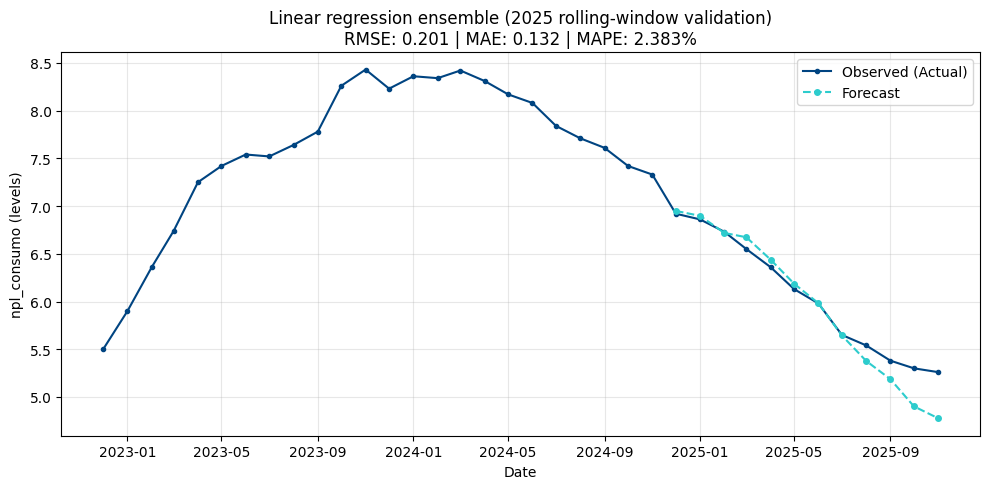

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,
                                                                                                                            "weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Linear regression ensemble (2025 rolling-window validation)")

#### Ridge Regression

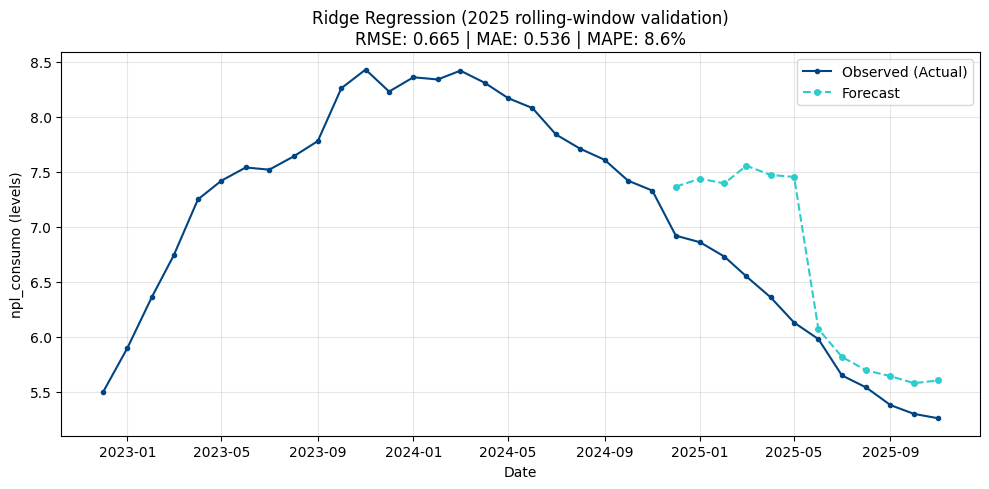

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")

#### Ridge Regression ensemble

Fitting model since 1995-12-01 00:00:00
Ridge alpha=1.0 Intercept: -1.8912612527740485e-17
Ridge Coefficients (scaled X space):
inflacion_lag18        0.027351
conf_comercial_lag6    0.001486
covid                 -0.006679
y_lag1                 0.940483
y_lag2                 0.004839
y_lag3                 0.205705
y_lag4                -0.115638
y_lag5                 0.140968
y_lag6                -0.148667
y_lag7                -0.136245
y_lag8                -0.048538
y_lag9                 0.013243
y_lag10                0.124914
y_lag11               -0.127972
y_lag12                0.033925
Name: coef_scaled_space, dtype: float64
Fitting model since 1997-03-01 00:00:00
Ridge alpha=1.0 Intercept: -1.3687312827946006e-17
Ridge Coefficients (scaled X space):
bruta_consumo_lag15    0.039681
inflacion_lag18        0.022835
conf_comercial_lag6   -0.010810
covid                 -0.002675
y_lag1                 0.926364
y_lag2                 0.041350
y_lag3                 0.176754


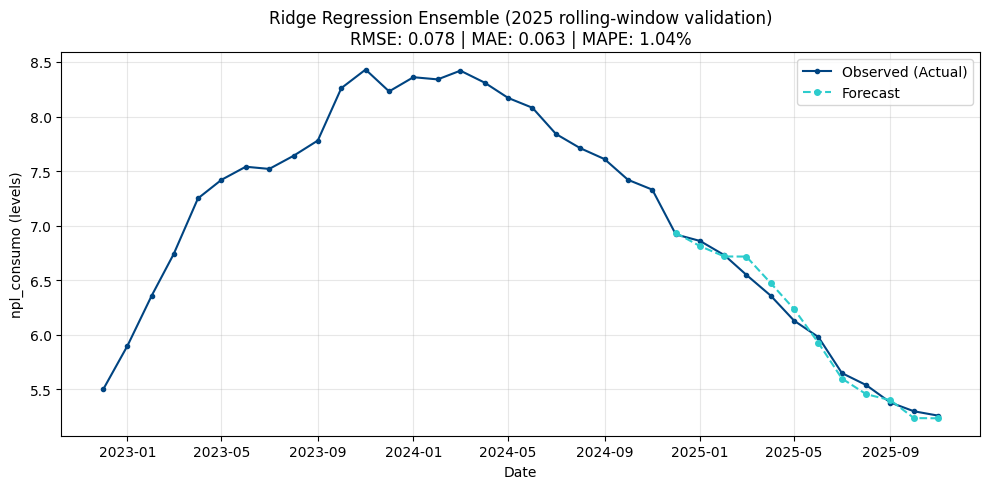

In [54]:
LAGS = 12

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")

#### Quantile regression

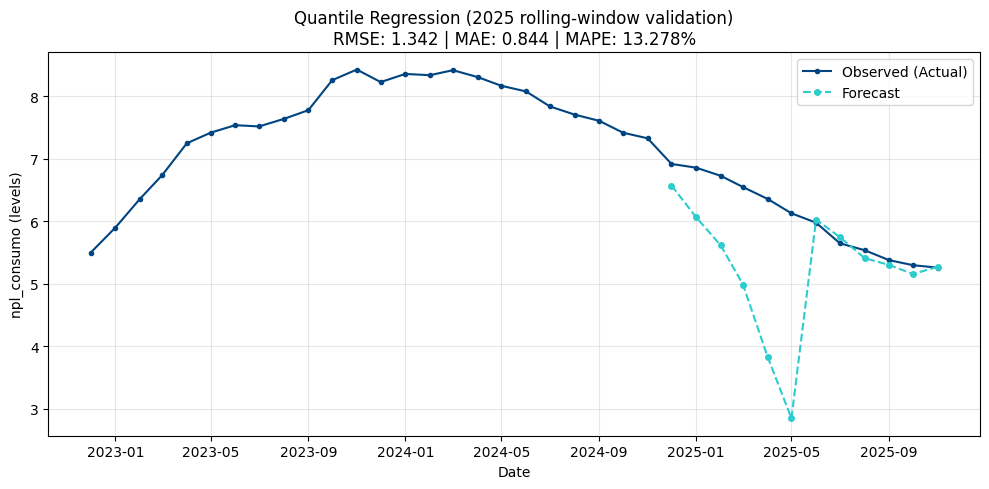

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {
    "quantile": 0.5
}

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")

#### Random forest

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}

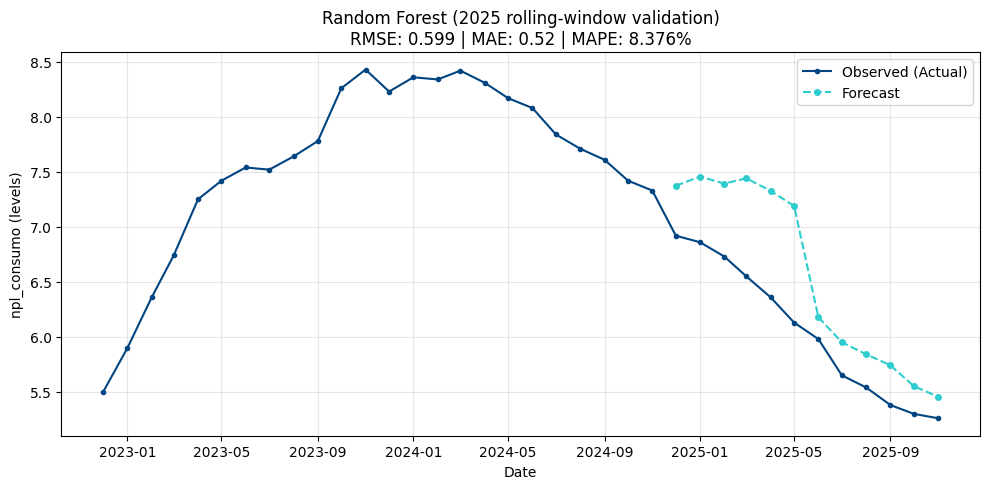

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Extra trees regressor

Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Target is tranformed: False
Train since: 1991-12-01 00:00:00
Index(['npl_consumo', 'ipi_lag6', 'ise_terc_des_lag6', 'ventas_minor_lag6',
       'pol_mon_lag12', 'tarj_nat_inter_compra_lag13', 'inflacion_lag18',
       'cred_consumo_lag7', 'bbva_cons_alim_real_lag23', 'gdelt_5_lag13',
       'google_consumo_pc_lag13', 'conf_comercial_lag6', 'covid'],
      dtype='object')


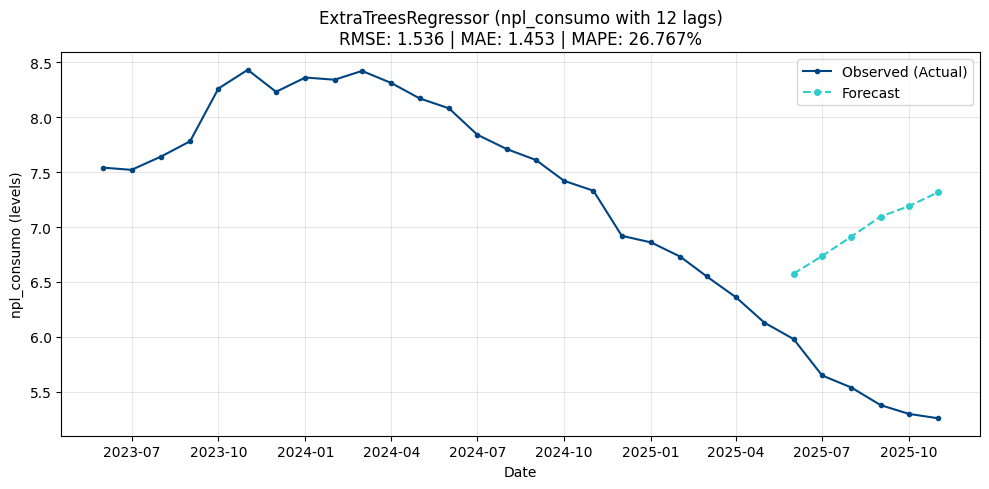

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 4,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}

y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")

Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}
Hyperparameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True, 'random_state': 42}


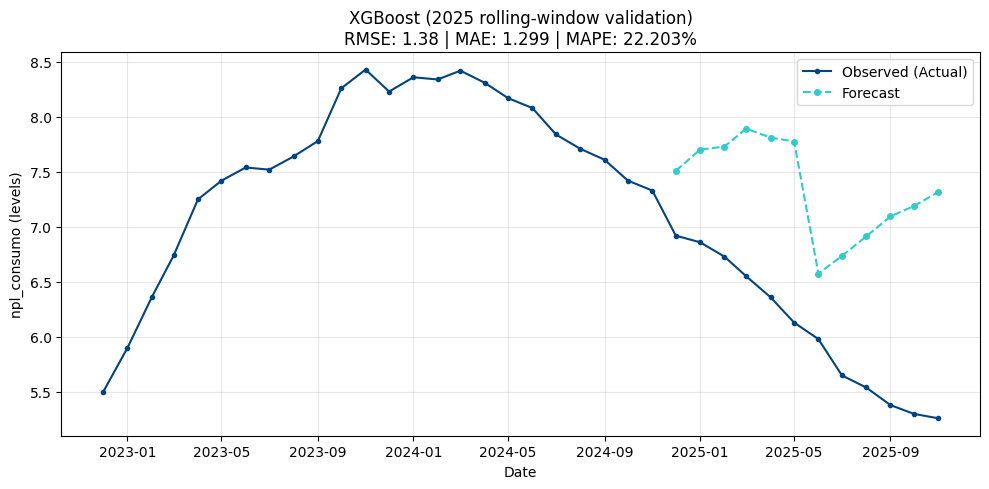

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}


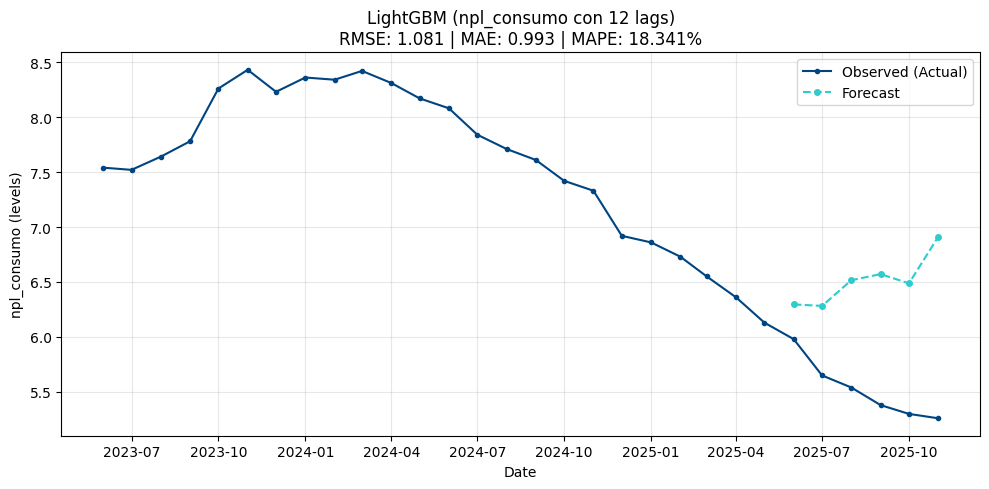

In [ ]:
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}

y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}
Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 3, 'min_child_samples': 5, 'random_state': 42, 'verbose': -1}


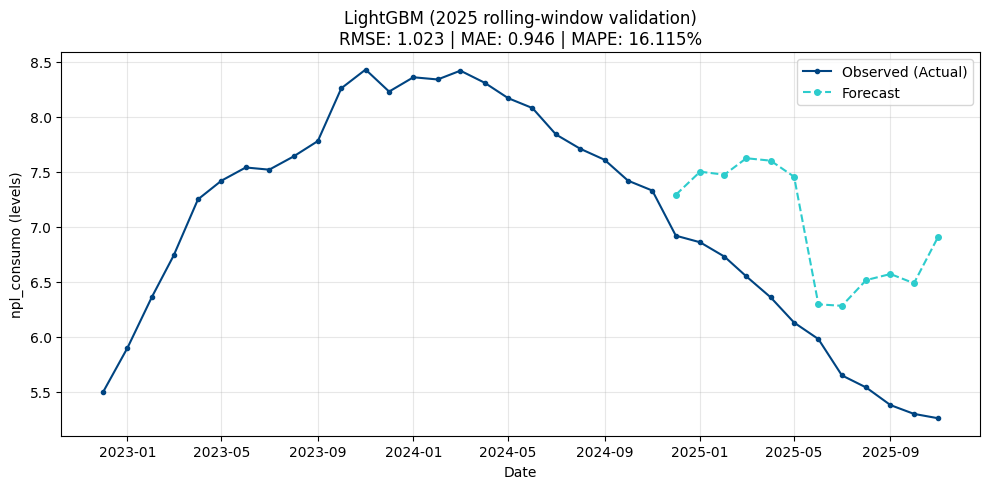

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_LIGHTGBM})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")

#### LSTM

In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}

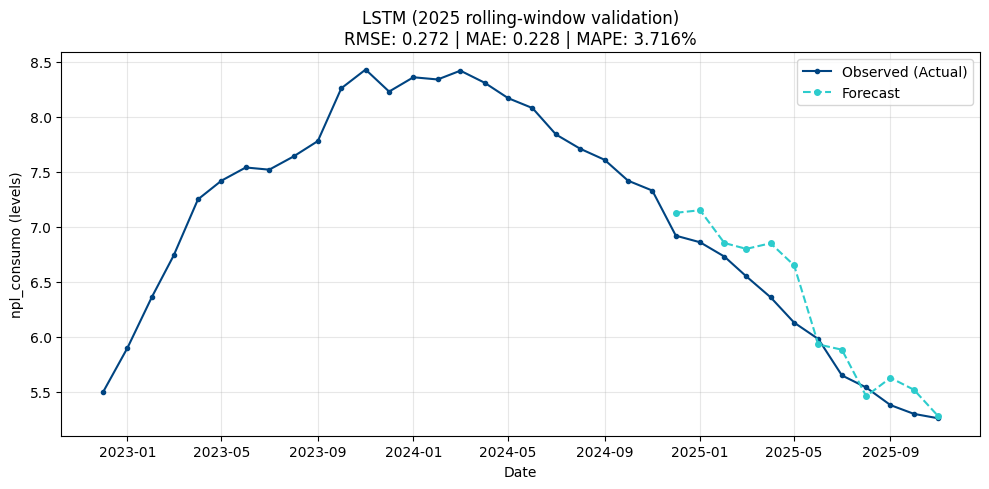

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")

#### Chronos-2

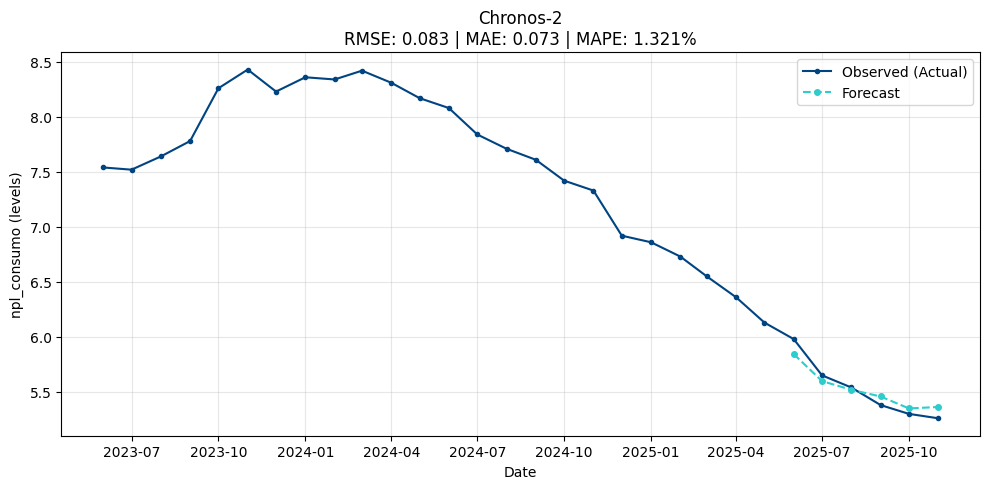

In [ ]:
y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")

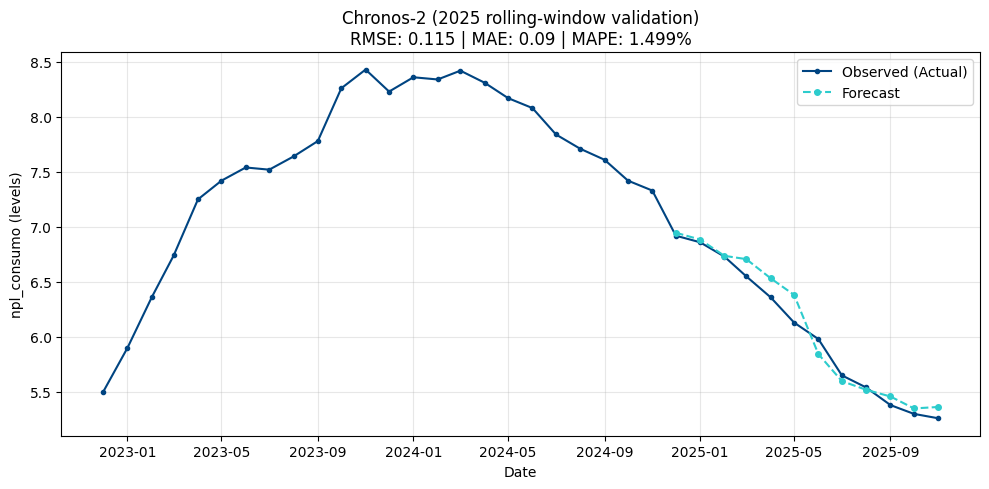

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")

#### Bayesian Structual Time Series (BSTS)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Target is tranformed: False
Train since: 1991-12-01 00:00:00
Index(['npl_consumo', 'ipi_lag6', 'ise_terc_des_lag6', 'ventas_minor_lag6',
       'pol_mon_lag12', 'tarj_nat_inter_compra_lag13', 'inflacion_lag18',
       'cred_consumo_lag7', 'bbva_cons_alim_real_lag23', 'gdelt_5_lag13',
       'google_consumo_pc_lag13', 'conf_comercial_lag6', 'covid'],
      dtype='object')


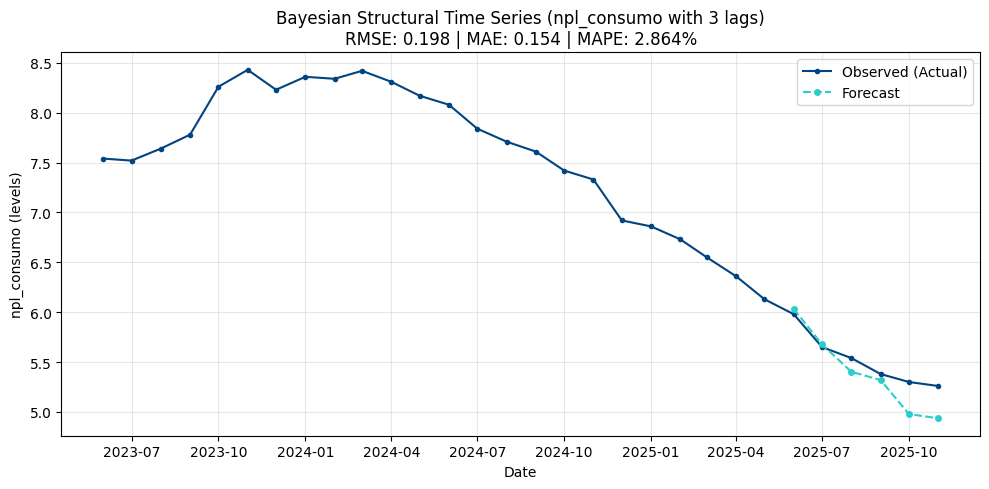

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 3
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}

y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/b

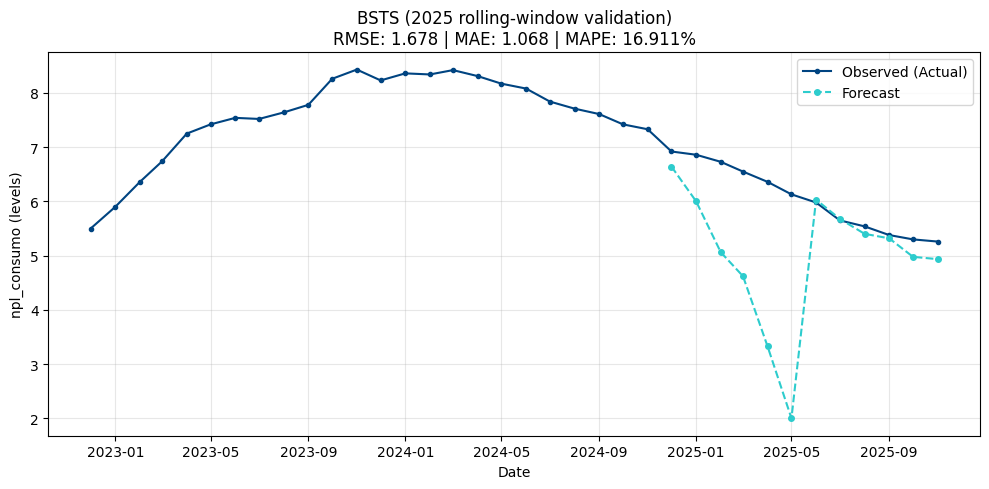

{'units': 32, 'learning_rate': 0.05, 'epochs': 200, 'bacth_size': 64}


In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"BSTS (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)

### **NPL Hipotecaria**

#### Variable selection

In [55]:
# SELECCIÓN CARMEN (TARGET_PROC VS. REGRESSORS_PROC)

if TARGET_LOGITDIFF_TRANSF == True:
  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)
  print("Target did not have transformation.")
data_hipotecaria_npl["bruta_hipotecaria_lag6"] = regressors["bruta_hipotecaria"].shift(6)
data_hipotecaria_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) # ise_total_des lag3: 71,0%
data_hipotecaria_npl["tes_5a_lag6"] = regressors["tes_5a"].shift(12) # tes_5a lag6: 55,1%
data_hipotecaria_npl["cred_hipotec_lag14"] = regressors["cred_hipotec"].shift(14) # cred_hipotecaria lag14: 69,4%
data_hipotecaria_npl["conf_consumo_lag6"] = regressors["conf_consumo"].shift(6) # conf_consumo lag4: 63%
data_hipotecaria_npl["tarj_nat_inter_compra_lag15"] = regressors["tarj_nat_inter_compra"].shift(15) # tarj_nat_inter_compra lag15: 72,8%
data_hipotecaria_npl["empl_desocupacion_ciud_lag6"] = regressors["empl_desocupacion_ciud"].shift(6) # empl_desocupacion_ciud lag6: 49,9%
data_hipotecaria_npl["gdelt_3_lag18"] = regressors["gdelt_3"].shift(18) # gdelt_3 lag18: -71,1%
data_hipotecaria_npl["vivienda_utv_lag7"] = regressors["vivienda_utv"].shift(7) # vivienda_utv lag7: 68,8%
#data_hipotecaria_npl["coloc_hipotec_tasaint_nom_lag15"] = regressors["coloc_hipotec_tasaint_nom"].shift(15) # coloc_hipotec_tasaint_nom lag15: 63,1%

data_hipotecaria_npl = data_hipotecaria_npl["2002":].dropna(how="all")

#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecaria")
#data_hipotecaria_npl = add_fourier_terms(data_hipotecaria_npl, period=12, K=2)
data_hipotecaria_npl = add_covid_dummy(data_hipotecaria_npl, covid_dates=COVID_DATES)

data_hipotecaria_npl.tail()

Target did not have transformation.


,npl_hipotecaria,bruta_hipotecaria_lag6,ise_total_des_lag6,tes_5a_lag6,cred_hipotec_lag14,conf_consumo_lag6,tarj_nat_inter_compra_lag15,empl_desocupacion_ciud_lag6,gdelt_3_lag18,vivienda_utv_lag7,covid
date,,,,,,,,,,,
2025-07-01,-0.12,8.33,2.11,10.09,14.31,-1.12,-11.44,-1.27,0.24,10.31,0
2025-08-01,-0.25,8.84,2.53,9.57,14.04,-11.96,-13.37,-1.84,0.80,6.94,0
2025-09-01,-0.30,9.17,2.88,9.44,13.34,-7.14,-16.85,-1.43,0.75,5.55,0
2025-10-01,-0.36,9.44,2.28,10.18,12.42,-8.56,-21.93,-1.60,1.68,5.59,0
2025-11-01,-0.45,9.64,2.34,10.28,11.86,-3.76,-23.21,-1.33,1.21,5.57,0


In [56]:
# SELECCIÓN EQUIPO (TARGET VS. REGRESSORS_PROC)

'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)
  print("Target did not have transformation.")
data_hipotecaria_npl["bruta_hipotecaria_lag6"] = regressors["bruta_hipotecaria"].shift(6) * -1
data_hipotecaria_npl["tes_10a_lag18"] = regressors["tes_10a"].shift(18)
data_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)
data_hipotecaria_npl["gri_colombia_lag14"] = regressors["gri_colombia"].shift(14)
data_hipotecaria_npl["bbva_cons_serv_real_lag10"] = regressors["bbva_cons_serv_real"].shift(10)
data_hipotecaria_npl["gdelt_1_lag14"] = regressors["gdelt_1"].shift(14)
data_hipotecaria_npl["google_hipotecaria_pc_lag24"] = regressors["google_hipotecaria_pc"].shift(24)

#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecaria")
#data_hipotecaria_npl = add_fourier_terms(data_hipotecaria_npl, period=12, K=2)
data_hipotecaria_npl = add_covid_dummy(data_hipotecaria_npl, covid_dates=COVID_DATES)

data_hipotecaria_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_hipotecaria_npl["bruta_hipotecaria_lag6"] = regressors["bruta_hipotecaria"].shift(6) * -1\ndata_hipotecaria_npl["tes_10a_lag18"] = regressors["tes_10a"].shift(18)\ndata_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)\ndata_hipotecaria_npl["gri_colombia_lag14"] = regressors["gri_colombia"].shift(14)\ndata_hipotecaria_npl["bbva_cons_serv_real_lag10"] = regressors["bbva_cons_serv_real"].shift(10)\ndata_hipotecaria_npl["gdelt_1_lag14"] = regressors["gdelt_1"].shift(14)\ndata_hipotecaria_npl["google_hipotecaria_pc_lag24"] = regressors["google_hipotecaria_pc"].shift(24)\n\n#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecar

In [57]:
# OPCIÓN 1
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)
  print("Target did not have transformation.")
data_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)
data_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)
data_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)
data_hipotecaria_npl["tarj_nat_inter_compra_lag18"] = regressors["tarj_nat_inter_compra"].shift(18)
data_hipotecaria_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)
data_hipotecaria_npl["epu_lag18"] = regressors["epu"].shift(18)
data_hipotecaria_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1

#data_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -1  #⚠️
#data_hipotecaria_npl["ventas_minor_lag9"] = regressors["ventas_minor"].shift(9) * -1  #⚠️
#data_hipotecaria_npl["pobl_ocup_glob_lag1"] = regressors["pobl_ocup_glob"].shift(1) * -1  #⚠️
#data_hipotecaria_npl["gri_colombia_lag9"] = regressors["gri_colombia"].shift(9)  #⚠️
#data_hipotecaria_npl["gdelt_7_lag7"] = regressors["gdelt_7"].shift(7)  #⚠️
#data_hipotecaria_npl["coloc_hipotec_tasaint_nom_lag13"] = regressors["coloc_hipotec_tasaint_nom"].shift(13)  #⚠️
#data_hipotecaria_npl["bbva_cons_total_real_lag24"] = regressors["bbva_cons_total_real"].shift(24)

#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecaria")
#data_hipotecaria_npl = add_fourier_terms(data_hipotecaria_npl, period=12, K=2)
data_hipotecaria_npl = add_covid_dummy(data_hipotecaria_npl, covid_dates=COVID_DATES)

data_hipotecaria_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)\ndata_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)\ndata_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)\ndata_hipotecaria_npl["tarj_nat_inter_compra_lag18"] = regressors["tarj_nat_inter_compra"].shift(18)\ndata_hipotecaria_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)\ndata_hipotecaria_npl["epu_lag18"] = regressors["epu"].shift(18)\ndata_hipotecaria_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1\n\n#data_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -

In [58]:
# OPCIÓN 2
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)
  print("Target did not have transformation.")
data_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)
data_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)
data_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)
data_hipotecaria_npl["tarj_nat_inter_compra_lag18"] = regressors["tarj_nat_inter_compra"].shift(18)
data_hipotecaria_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)
data_hipotecaria_npl["epu_lag18"] = regressors["epu"].shift(18)
data_hipotecaria_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1

data_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -1  #⚠️
#data_hipotecaria_npl["ventas_minor_lag9"] = regressors["ventas_minor"].shift(9) * -1  #⚠️
#data_hipotecaria_npl["pobl_ocup_glob_lag1"] = regressors["pobl_ocup_glob"].shift(1) * -1  #⚠️
#data_hipotecaria_npl["gri_colombia_lag9"] = regressors["gri_colombia"].shift(9)  #⚠️
#data_hipotecaria_npl["gdelt_7_lag7"] = regressors["gdelt_7"].shift(7)  #⚠️
data_hipotecaria_npl["coloc_hipotec_tasaint_nom_lag13"] = regressors["coloc_hipotec_tasaint_nom"].shift(13)  #⚠️
data_hipotecaria_npl["bbva_cons_total_real_lag24"] = regressors["bbva_cons_total_real"].shift(24)

#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecaria")
#data_hipotecaria_npl = add_fourier_terms(data_hipotecaria_npl, period=12, K=6)
#data_hipotecaria_npl = add_covid_dummy(data_hipotecaria_npl, covid_dates=COVID_DATES)

data_hipotecaria_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)\ndata_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)\ndata_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)\ndata_hipotecaria_npl["tarj_nat_inter_compra_lag18"] = regressors["tarj_nat_inter_compra"].shift(18)\ndata_hipotecaria_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)\ndata_hipotecaria_npl["epu_lag18"] = regressors["epu"].shift(18)\ndata_hipotecaria_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1\n\ndata_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -1

In [59]:
# ÓPTIMO PARA TREE MODELS
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)
  print("Target did not have transformation.")
data_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)
#data_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -1  #⚠️
data_hipotecaria_npl["ise_total_des_lag1"] = regressors["ise_total_des"].shift(1) * -1  #⚠️
#data_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)
data_hipotecaria_npl["tes_1a_lag17"] = regressors["tes_1a"].shift(17)
#data_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)
data_hipotecaria_npl["cred_hipotec_lag14"] = regressors["cred_hipotec"].shift(14)
data_hipotecaria_npl["ventas_minor_lag9"] = regressors["ventas_minor"].shift(9) * -1  #⚠️
#data_hipotecaria_npl["tarj_nat_inter_compra_lag18"] = regressors["tarj_nat_inter_compra"].shift(18)
data_hipotecaria_npl["tarj_nat_inter_compra_lag17"] = regressors["tarj_nat_inter_compra"].shift(17)
data_hipotecaria_npl["pobl_ocup_glob_lag1"] = regressors["pobl_ocup_glob"].shift(1) * -1  #⚠️
#data_hipotecaria_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)
data_hipotecaria_npl["google_total_pc_lag15"] = regressors["google_total_pc"].shift(15) * -1
data_hipotecaria_npl["gri_colombia_lag9"] = regressors["gri_colombia"].shift(9)  #⚠️
#data_hipotecaria_npl["epu_lag18"] = regressors["epu"].shift(18)
data_hipotecaria_npl["gdelt_7_lag7"] = regressors["gdelt_7"].shift(7)  #⚠️
#data_hipotecaria_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1
data_hipotecaria_npl["vivienda_utv_lag6"] = regressors["vivienda_utv"].shift(6)
data_hipotecaria_npl["coloc_hipotec_tasaint_nom_lag13"] = regressors["coloc_hipotec_tasaint_nom"].shift(13)  #⚠️
#data_hipotecaria_npl["bbva_cons_total_real_lag24"] = regressors["bbva_cons_total_real"].shift(24)

#data_hipotecaria_npl = add_missing_flags(data_hipotecaria_npl, "npl_hipotecaria")
data_hipotecaria_npl = add_fourier_terms(data_hipotecaria_npl, period=12, K=2)
data_hipotecaria_npl = add_covid_dummy(data_hipotecaria_npl, covid_dates=COVID_DATES)
data_hipotecaria_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_hipotecaria_npl = target_logit_diff[["npl_hipotecaria"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_hipotecaria_npl = target[["npl_hipotecaria"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_hipotecaria_npl["bruta_hipotecaria_lag22"] = regressors["bruta_hipotecaria"].shift(22)\n#data_hipotecaria_npl["ise_total_des_lag11"] = regressors["ise_total_des"].shift(11) * -1  #⚠️\ndata_hipotecaria_npl["ise_total_des_lag1"] = regressors["ise_total_des"].shift(1) * -1  #⚠️\n#data_hipotecaria_npl["tes_1a_lag20"] = regressors["tes_1a"].shift(20)\ndata_hipotecaria_npl["tes_1a_lag17"] = regressors["tes_1a"].shift(17)\n#data_hipotecaria_npl["cred_hipotec_lag18"] = regressors["cred_hipotec"].shift(18)\ndata_hipotecaria_npl["cred_hipotec_lag14"] = regressors["cred_hipotec"].shift(14)\ndata_hipotecaria_npl["ventas_minor_lag9"] = regressors["ventas_minor"].shift(9) * -1  #⚠️\n#da

In [60]:
# PARAMETERS: NPL HIPOTECARIA
NPL_DATA = data_hipotecaria_npl
TARGET = "npl_hipotecaria"

#### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


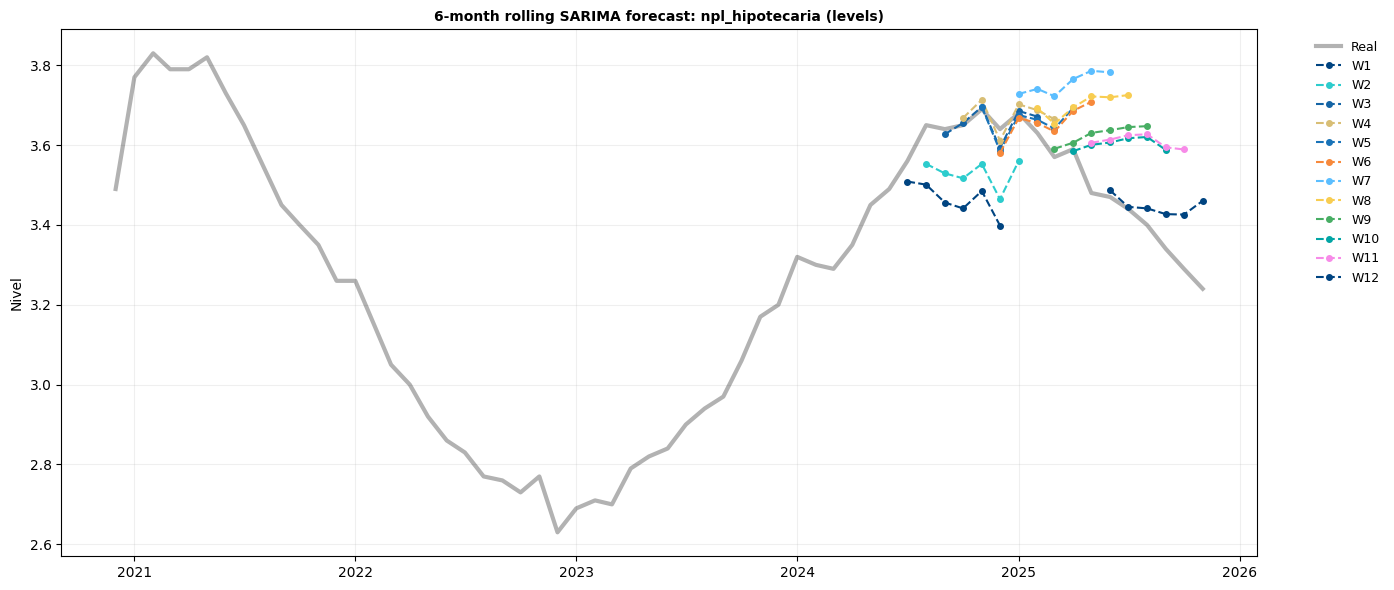

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.17,0.13,0.02,0.04,0.05,0.08,0.18,0.17,0.13,0.15,0.21,0.08,0.117500
RMSE,0.18,0.13,0.03,0.05,0.06,0.11,0.21,0.19,0.16,0.17,0.21,0.11,0.134167
R2,-21.29,-44.26,-0.41,-0.58,-0.75,-1.88,-6.60,-6.62,-4.63,-3.92,-8.69,-0.93,-8.380000
MAPE (%),4.75,3.52,0.54,1.13,1.26,2.29,5.22,4.90,3.90,4.43,6.09,2.57,3.383333


In [ ]:
ORDER = (2,1,2)
SEASONAL_ORDER = (0,0,1,12)
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_name="SARIMA", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


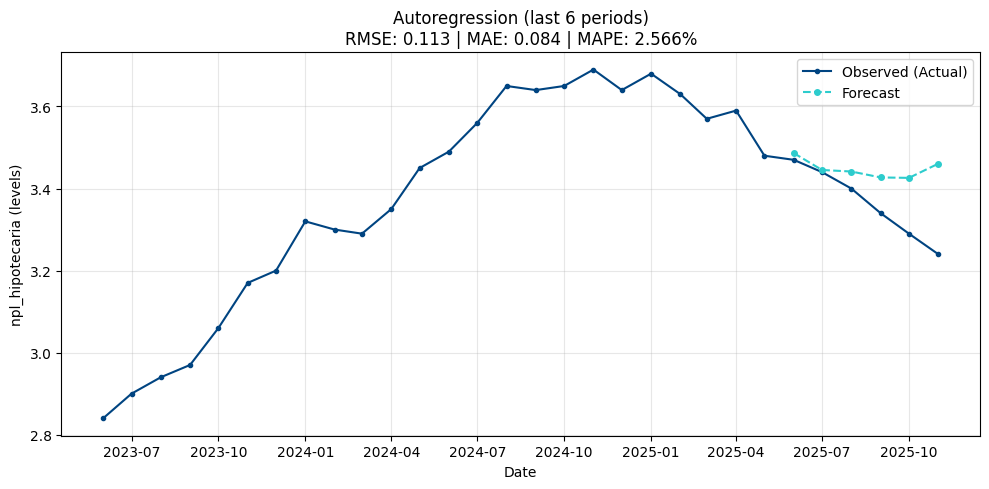

In [ ]:
# AUTOREGRESSION
y_pred = autoregression(NPL_DATA, TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER, test_size=TEST_SIZE)

# Detransform
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

# Plot
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression (last 6 periods)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (2, 1, 2)
Seasonal order: (0, 0, 1, 12)


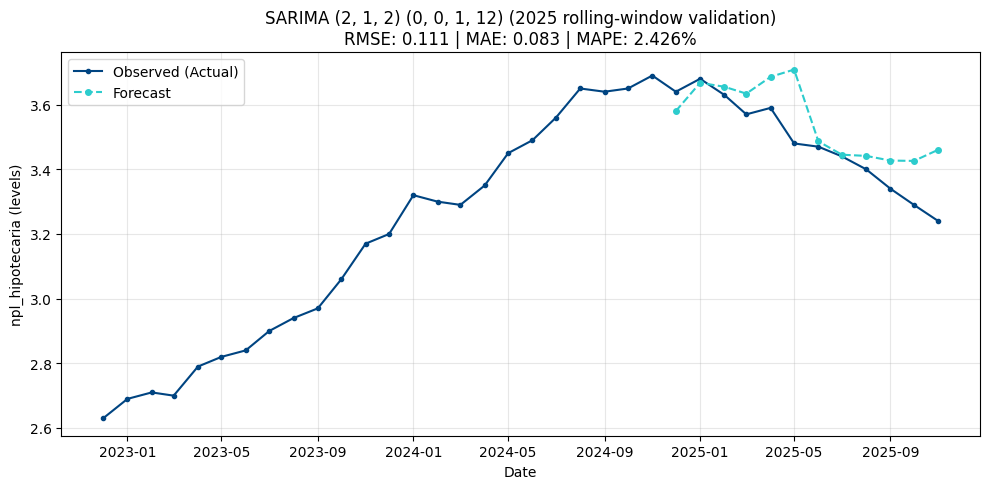

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMA {ORDER} {SEASONAL_ORDER} (2025 rolling-window validation)")

#### SARIMAX

* Works best with variables OPCION 1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

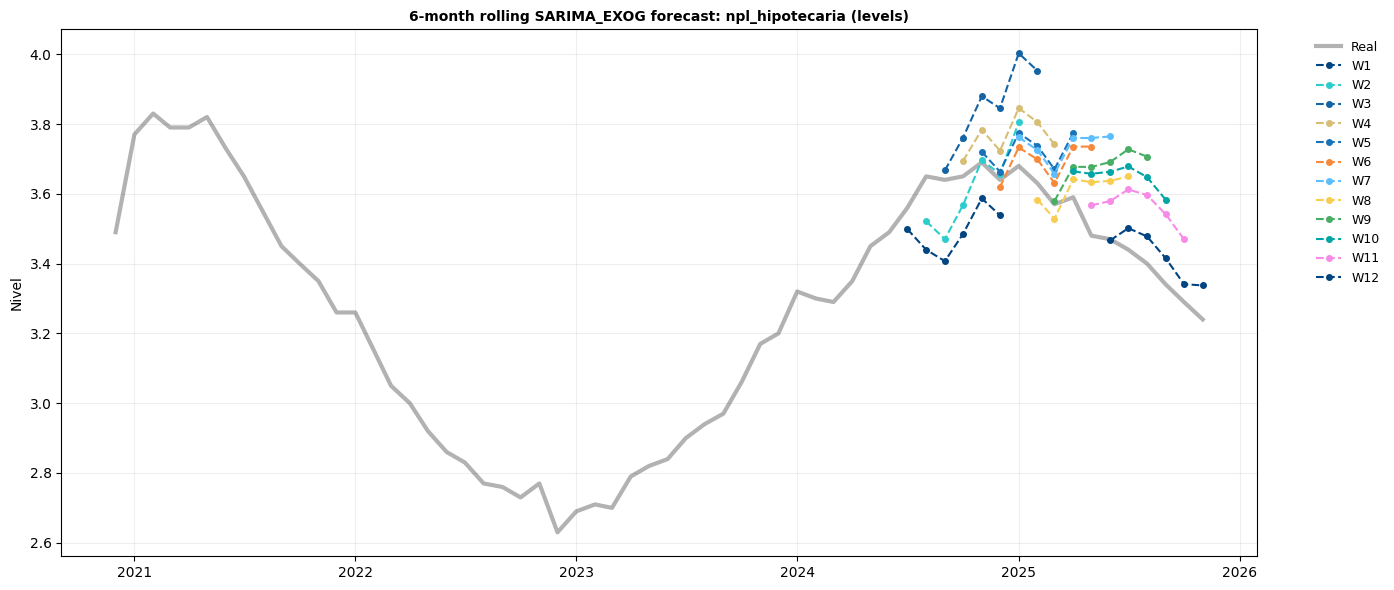

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.15,0.09,0.20,0.12,0.09,0.10,0.17,0.11,0.18,0.20,0.16,0.06,0.135833
RMSE,0.16,0.11,0.22,0.13,0.10,0.13,0.19,0.13,0.21,0.20,0.16,0.07,0.150833
R2,-15.55,-28.82,-100.42,-10.52,-4.81,-3.03,-5.36,-2.47,-8.90,-6.08,-4.63,0.31,-15.856667
MAPE (%),4.00,2.41,5.37,3.36,2.49,2.83,4.76,3.20,5.35,5.70,4.65,1.83,3.829167


In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_name="SARIMA_EXOG", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


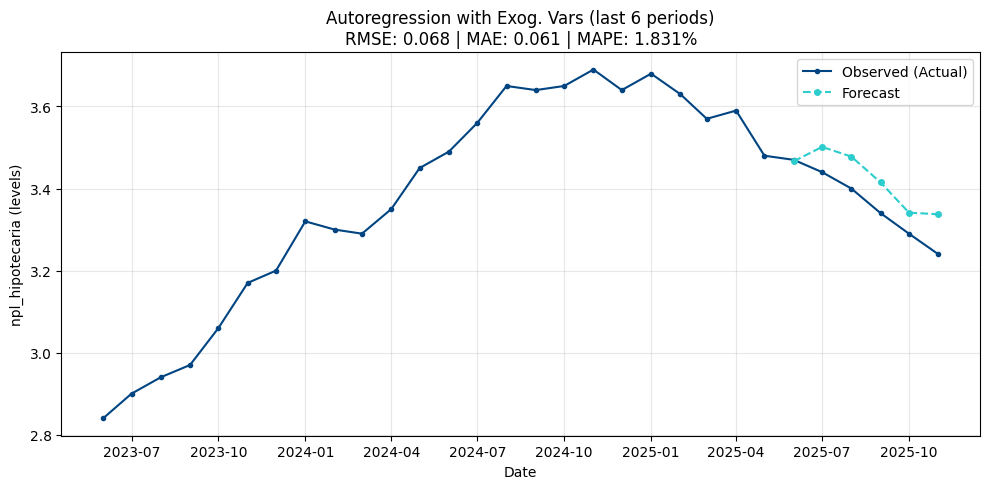

In [ ]:
# AUTOREGRESSION WITH EXOGENOUS VARIABLES

y_pred = autoregression_with_exog(NPL_DATA, target_var=TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER)

if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression with Exog. Vars (last 6 periods)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

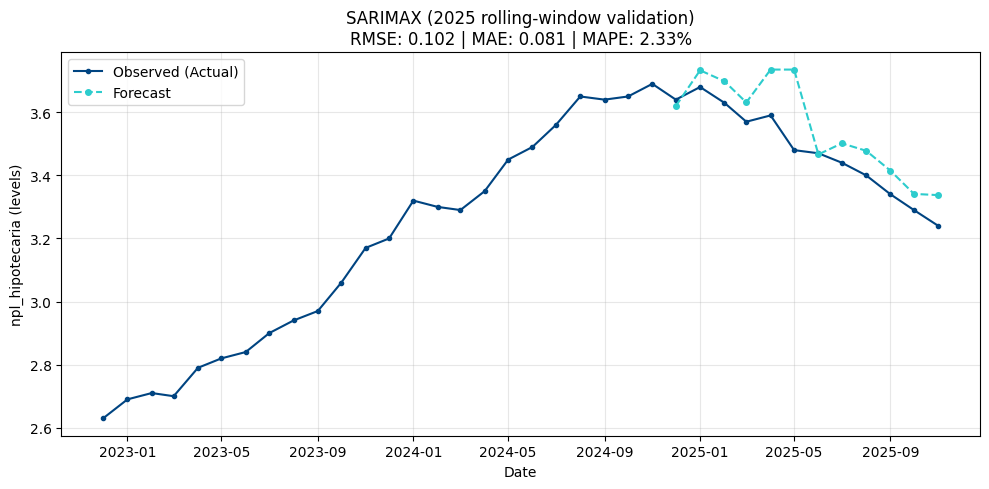

Covariates: Index(['npl_hipotecaria', 'bruta_hipotecaria_lag6', 'ise_total_des_lag6',
       'tes_5a_lag6', 'cred_hipotec_lag14', 'conf_consumo_lag6',
       'tarj_nat_inter_compra_lag15', 'empl_desocupacion_ciud_lag6',
       'gdelt_3_lag18', 'vivienda_utv_lag7', 'coloc_hipotec_tasaint_nom_lag15',
       'covid'],
      dtype='object')


In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)

#### Linear regression

Intercept: 3.3631275805575096e-16
Coefficients: bruta_hipotecaria_lag6             0.158030
ise_total_des_lag6                 0.190721
tes_5a_lag6                       -0.030169
cred_hipotec_lag14                 0.630950
conf_consumo_lag6                  0.001546
tarj_nat_inter_compra_lag15        0.002780
empl_desocupacion_ciud_lag6        0.212247
gdelt_3_lag18                     -0.038339
vivienda_utv_lag7                  0.250738
coloc_hipotec_tasaint_nom_lag15   -0.411982
covid                              0.166891
y_lag1                             1.002411
y_lag2                            -0.287203
y_lag3                            -0.132965
y_lag4                             0.244058
y_lag5                            -0.236871
y_lag6                             0.187792
y_lag7                            -0.015683
y_lag8                            -0.491944
y_lag9                             0.669856
y_lag10                           -0.172173
y_lag11                     

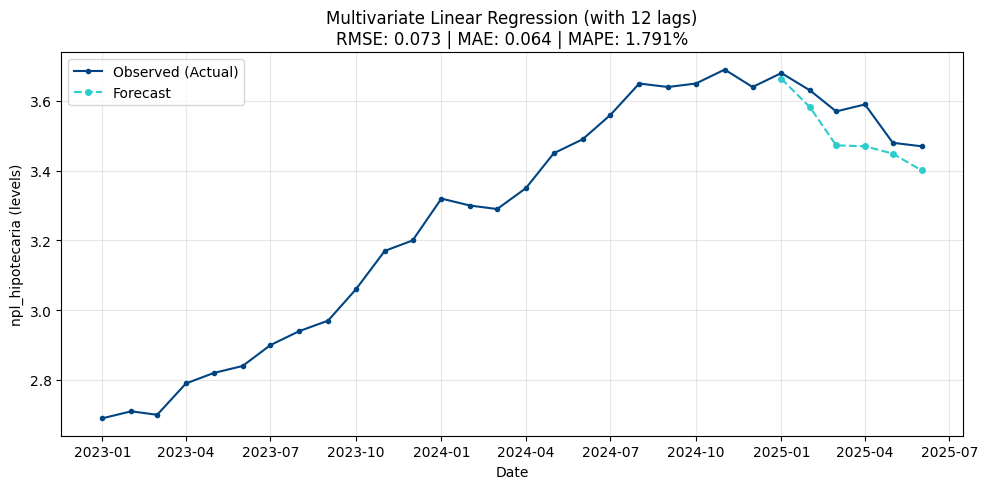

In [ ]:
# LINEAR REGRESSION
LAGS = 12

y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")

Intercept: 4.658697525922786e-16
Coefficients: bruta_hipotecaria_lag6             0.160922
ise_total_des_lag6                 0.189018
tes_5a_lag6                       -0.030673
cred_hipotec_lag14                 0.639387
conf_consumo_lag6                  0.002375
tarj_nat_inter_compra_lag15        0.001959
empl_desocupacion_ciud_lag6        0.212712
gdelt_3_lag18                     -0.034755
vivienda_utv_lag7                  0.247781
coloc_hipotec_tasaint_nom_lag15   -0.422919
covid                              0.167450
y_lag1                             1.000811
y_lag2                            -0.286570
y_lag3                            -0.132444
y_lag4                             0.242671
y_lag5                            -0.237856
y_lag6                             0.187563
y_lag7                            -0.010850
y_lag8                            -0.493955
y_lag9                             0.670695
y_lag10                           -0.175929
y_lag11                      

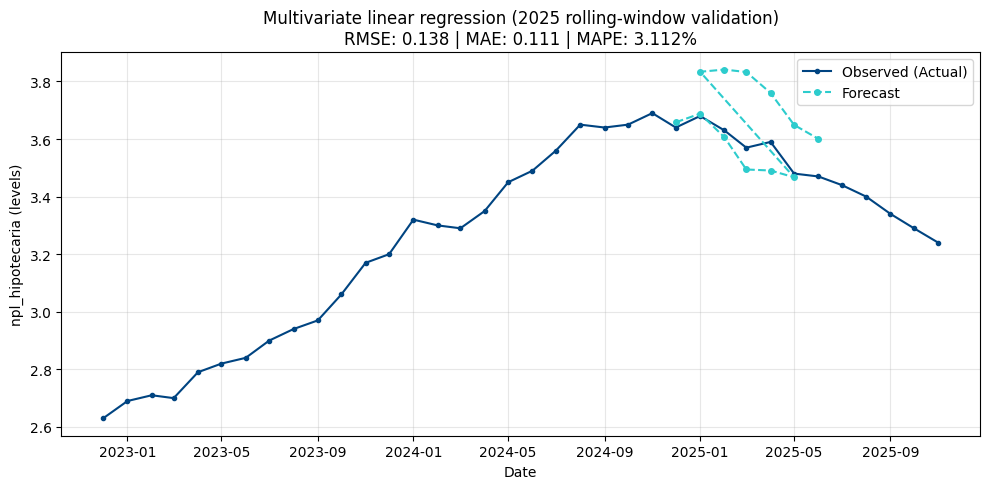

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")

#### Linear regression ensemble

In [ ]:
LAGS = 12

y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")

Fitting model since 2002-01-01 00:00:00
Intercept: -1.0519733549618402e-16
Coefficients: bruta_hipotecaria_lag6    0.057906
covid                     0.011371
y_lag1                    0.845914
y_lag2                    0.401480
y_lag3                   -0.342409
y_lag4                   -0.098879
y_lag5                    0.158841
y_lag6                   -0.010938
Name: coef_scaled_space, dtype: float64
Fitting model since 2002-05-01 00:00:00
Intercept: 6.859185047046605e-17
Coefficients: bruta_hipotecaria_lag6    0.066288
conf_consumo_lag6        -0.023708
covid                     0.005689
y_lag1                    0.837309
y_lag2                    0.397323
y_lag3                   -0.343243
y_lag4                   -0.093421
y_lag5                    0.151654
y_lag6                   -0.017272
Name: coef_scaled_space, dtype: float64
Fitting model since 2002-07-01 00:00:00
Intercept: 1.9662218252777477e-17
Coefficients: bruta_hipotecaria_lag6         0.068220
conf_consumo_lag6    

ValueError: Input contains NaN.

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,
                                                                                                                            "weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Linear regression ensemble (2025 rolling-window validation)")

#### Ridge Regression

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")

#### Ridge Regression ensemble

Fitting model since 2002-01-01 00:00:00
Ridge alpha=1.0 Intercept: -4.481280757591732e-17
Ridge Coefficients (scaled X space):
bruta_hipotecaria_lag6    0.058560
covid                     0.015189
y_lag1                    0.769500
y_lag2                    0.380669
y_lag3                   -0.233676
y_lag4                   -0.113891
y_lag5                    0.116166
y_lag6                    0.105517
y_lag7                   -0.007366
y_lag8                   -0.081430
y_lag9                    0.093076
y_lag10                  -0.020718
y_lag11                   0.038489
y_lag12                  -0.117436
Name: coef_scaled_space, dtype: float64
Fitting model since 2002-05-01 00:00:00
Ridge alpha=1.0 Intercept: 8.572642544724193e-19
Ridge Coefficients (scaled X space):
bruta_hipotecaria_lag6    0.061340
conf_consumo_lag6        -0.032200
covid                     0.004322
y_lag1                    0.749710
y_lag2                    0.375440
y_lag3                   -0.218602
y_lag4 

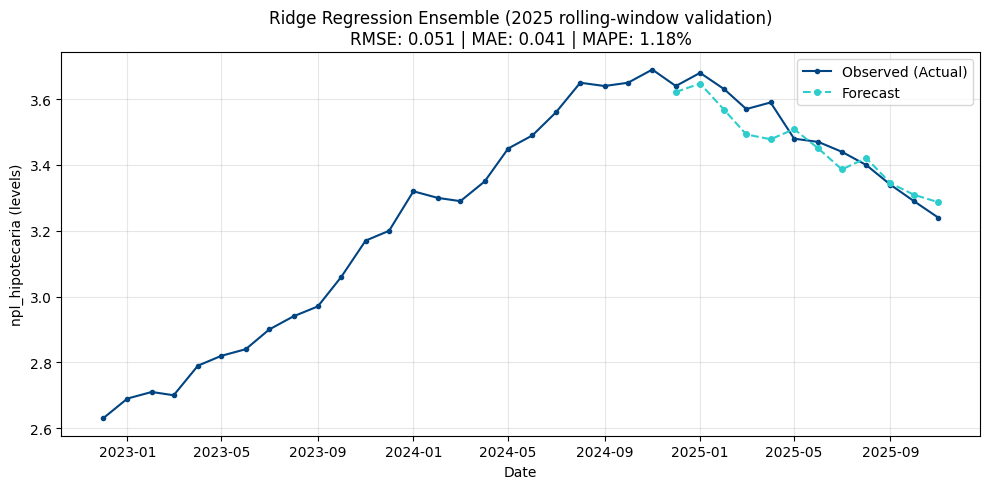

In [61]:
LAGS = 12

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")

#### Quantile regression

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {
    "quantile": 0.5
}

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")

#### Random forest

In [ ]:
# RANDOM FOREST
LAGS = 12

HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,        # número de árboles
    "max_depth": 10,            # profundidad máxima
    "min_samples_split": 5,     # tamaño mínimo para dividir un nodo
    "min_samples_leaf": 3,      # tamaño mínimo de cada hoja
    "random_state": 42,
}

y_pred = random_forest_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_RANDOMFOREST)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Random Forest (with {LAGS} lags)")

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Extra trees regressor

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 4,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}

y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### XGBoost

In [ ]:
# XGBOOST
LAGS = 12
HYPERPARAMETERS_XGBOOST = {"learning_rate": 0.05,
                           "n_estimators": 300,
                           "max_depth": 5,
                           "min_child_weight": 5,  # Minimum sum of instance weight (hessian) needed in a child
                           "subsample": 0.3,         # Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees.
                           "random_state": 42}

y_pred = xgboost_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_XGBOOST)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"XGBoost ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=xgboost_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                   "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

In [ ]:
# LIGHT GBM
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}

y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")

#### Chronos-2

In [ ]:
## CHRONOS-2

y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")

#### LSTM

In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")

#### Bayesian Structual Time Series (BSTS)

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 3
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}

y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)

### **NPL Total Sin Microcrédito**

#### Variable selection

In [67]:
# SELECCIÓN CARMEN (TARGET_PROC VS. REGRESSORS_PROC)

if TARGET_LOGITDIFF_TRANSF == True:
  data_totalsinmicro_npl = target_logit_diff[["npl_totalsinmicro"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_totalsinmicro_npl = target[["npl_totalsinmicro"]].copy(deep=True)
  print("Target did not have transformation.")

data_totalsinmicro_npl["bruta_totalsinmicro_lag10"] = regressors["bruta_total_sinmicro"].shift(10)
data_totalsinmicro_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) # ise_total lag5
data_totalsinmicro_npl["ipi_lag6"] = regressors["ipi"].shift(6) # ipi lag5: 62,4%
#data_totalsinmicro_npl["cred_consumo_lag24"] = regressors["cred_consumo"].shift(24)
#data_totalsinmicro_npl["pol_mon_lag"] = regressors["pol_mon_lag10"].shift(10)
data_totalsinmicro_npl["conf_comercial_lag24"] = regressors["conf_comercial"].shift(24) # conf_comercial lag24: 59,6%
data_totalsinmicro_npl["ventas_minor_lag24"] = regressors["ventas_minor"].shift(24) # ventas_minor lag24: 51,2%
data_totalsinmicro_npl["tarj_nat_inter_compra_lag9"] = regressors["tarj_nat_inter_compra"].shift(9) # tarj_nat_inter_compra lag9: 71,0%
data_totalsinmicro_npl["empl_desocupacion_ciud_lag4"] = regressors["empl_desocupacion_ciud"].shift(11) # empl_desocupacion_ciud lag4: 42%
data_totalsinmicro_npl["bbva_cons_host_real_lag23"] = regressors["bbva_cons_host_real"].shift(23) # bbva_cons_host_real lag23: 86,8%
data_totalsinmicro_npl["vivienda_rotacion_lag8"] = regressors["vivienda_rotacion"].shift(11) # vivienda_rotacion lag8: 68,9%
data_totalsinmicro_npl["coloc_total_lag24"] = regressors["coloc_total"].shift(24) # coloc_total lag24: 40,8%
data_totalsinmicro_npl = data_totalsinmicro_npl["2002":].dropna(how="all")

#data_totalsinmicro_npl = add_missing_flags(data_totalsinmicro_npl, "npl_total")
#data_totalsinmicro_npl = add_fourier_terms(data_totalsinmicro_npl, period=12, K=2)
data_totalsinmicro_npl = add_covid_dummy(data_totalsinmicro_npl, covid_dates=COVID_DATES)

data_totalsinmicro_npl.tail()

Target did not have transformation.


,npl_totalsinmicro,bruta_totalsinmicro_lag10,ise_total_des_lag6,ipi_lag6,conf_comercial_lag24,ventas_minor_lag24,tarj_nat_inter_compra_lag9,empl_desocupacion_ciud_lag4,bbva_cons_host_real_lag23,vivienda_rotacion_lag8,coloc_total_lag24,covid
date,,,,,,,,,,,,
2025-07-01,-0.81,1.08,2.11,-0.14,21.650320,-9.59,-23.49,0.42,1.53,-2.6,23.96,0
2025-08-01,-0.84,1.54,2.53,-2.11,12.373293,-11.30,-16.49,-0.48,-0.27,-2.0,24.29,0
2025-09-01,-0.91,2.50,2.88,1.76,15.070645,-10.28,-22.61,0.52,-2.15,-1.7,22.64,0
2025-10-01,-0.97,3.36,2.28,-4.70,14.699114,-13.07,-22.19,-0.63,-0.99,-14.5,22.71,0
2025-11-01,-1.00,3.32,2.34,-0.04,12.283364,-3.01,-21.91,-1.23,4.44,-13.9,22.16,0


In [68]:
# SELECCIÓN EQUIPO (TARGET VS. REGRESSORS_PROC)

'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_total_npl = target_logit_diff[["npl_total"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_total_npl = target[["npl_total"]].copy(deep=True)
  print("Target did not have transformation.")
data_total_npl["bruta_total_lag17"] = regressors["bruta_total"].shift(6) * -1
data_total_npl["coloc_total_lag14"] = regressors["coloc_total"].shift(14)
data_total_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_inv_total_real"].shift(24) * -1
data_total_npl["gdelt_11_lag18"] = regressors["gdelt_11"].shift(18) * -1
data_total_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) * -1
data_total_npl["conf_consumo_lag7"] = regressors["conf_consumo"].shift(7) * -1
data_total_npl.tail()
'''

'\nif TARGET_LOGITDIFF_TRANSF == True:\n  data_total_npl = target_logit_diff[["npl_total"]].copy(deep=True)\n  print("Target is expressed as the yearly difference of logits.")\nelse:\n  data_total_npl = target[["npl_total"]].copy(deep=True)\n  print("Target did not have transformation.")\ndata_total_npl["bruta_total_lag17"] = regressors["bruta_total"].shift(6) * -1\ndata_total_npl["coloc_total_lag14"] = regressors["coloc_total"].shift(14)\ndata_total_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_inv_total_real"].shift(24) * -1\ndata_total_npl["gdelt_11_lag18"] = regressors["gdelt_11"].shift(18) * -1\ndata_total_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) * -1\ndata_total_npl["conf_consumo_lag7"] = regressors["conf_consumo"].shift(7) * -1\ndata_total_npl.tail()\n'

In [69]:
# PARAMETERS: NPL TOTAL
NPL_DATA = data_totalsinmicro_npl
TARGET = "npl_totalsinmicro"

#### Autoregression

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


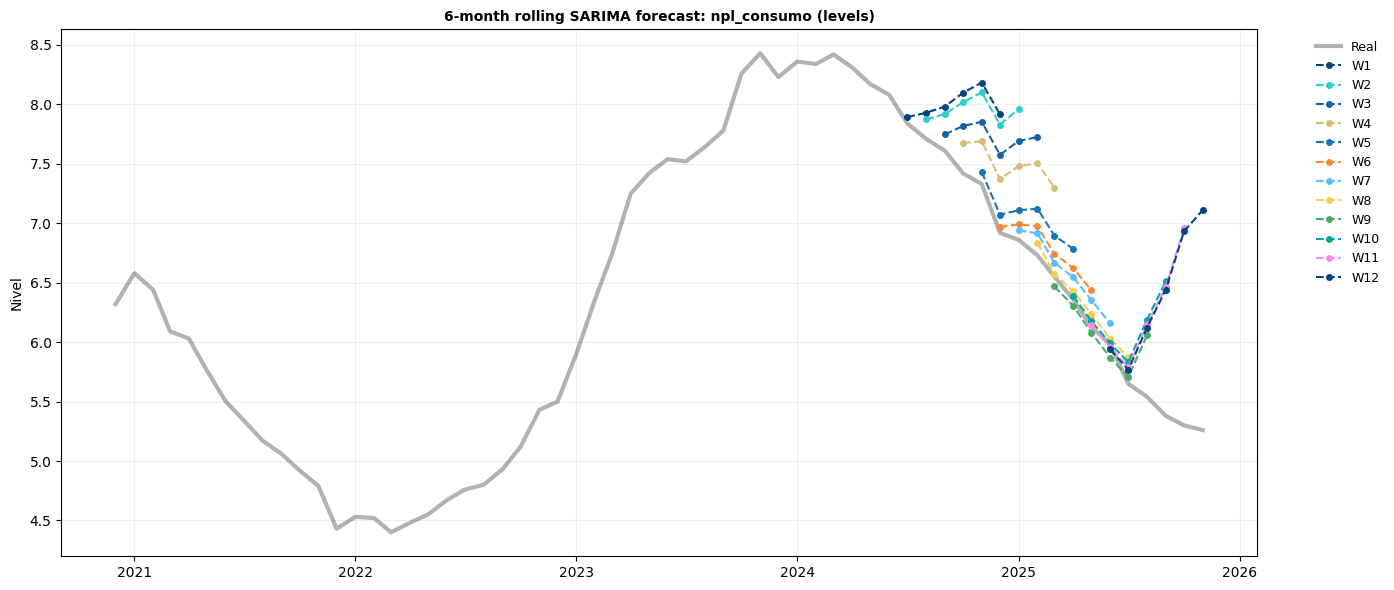

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.53,0.64,0.59,0.54,0.28,0.20,0.16,0.09,0.15,0.34,0.59,0.88,0.415833
RMSE,0.63,0.72,0.65,0.57,0.30,0.22,0.17,0.11,0.22,0.54,0.85,1.12,0.508333
R2,-3.40,-4.05,-3.07,-2.35,0.02,0.40,0.71,0.90,0.62,-1.45,-6.91,-19.77,-3.195833
MAPE (%),7.27,9.00,8.45,7.81,4.17,3.05,2.55,1.57,2.52,6.23,10.92,16.50,6.670000


In [ ]:
ORDER = (3,1,0)
SEASONAL_ORDER = (4,0,0,12)
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_name="SARIMA", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


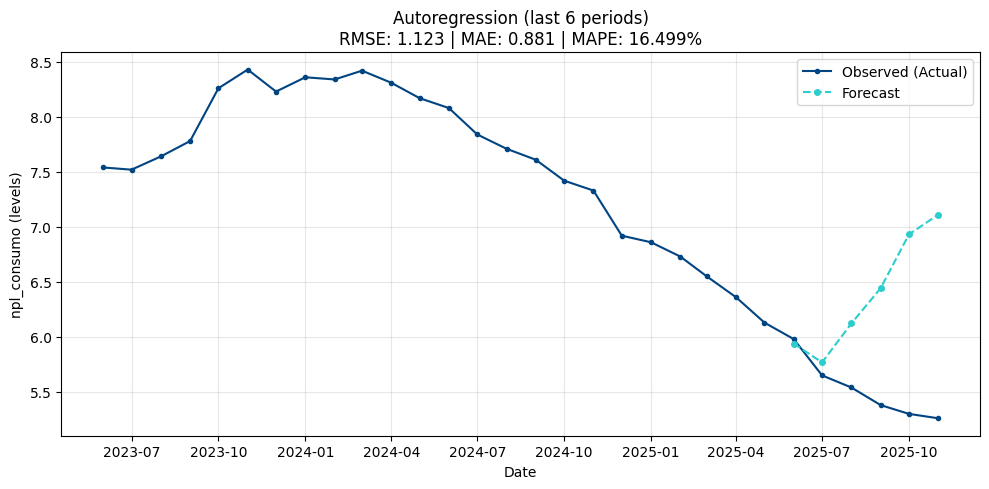

In [ ]:
y_pred = autoregression(NPL_DATA, TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER, test_size=TEST_SIZE)

# Detransform
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

# Plot
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression (last 6 periods)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Order: (3, 1, 0)
Seasonal order: (4, 0, 0, 12)


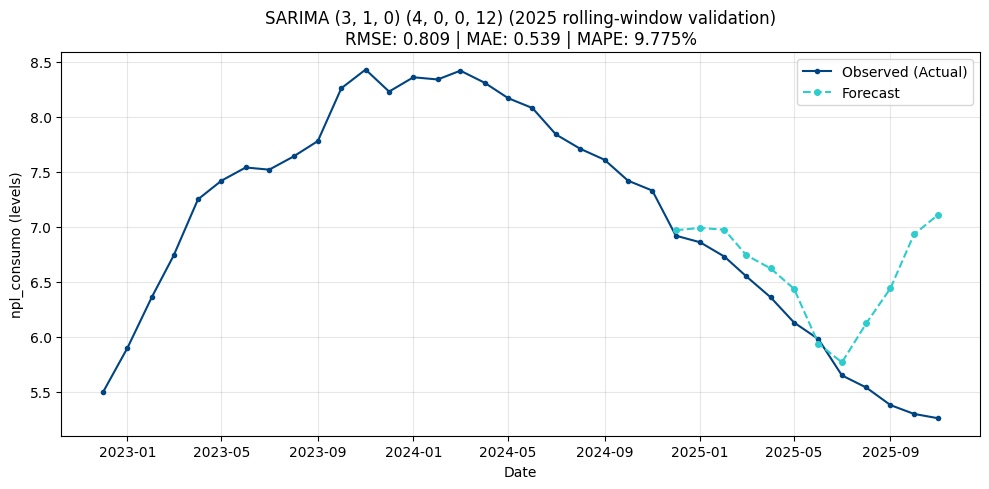

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMA {ORDER} {SEASONAL_ORDER} (2025 rolling-window validation)")

#### Autoregression with exog

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

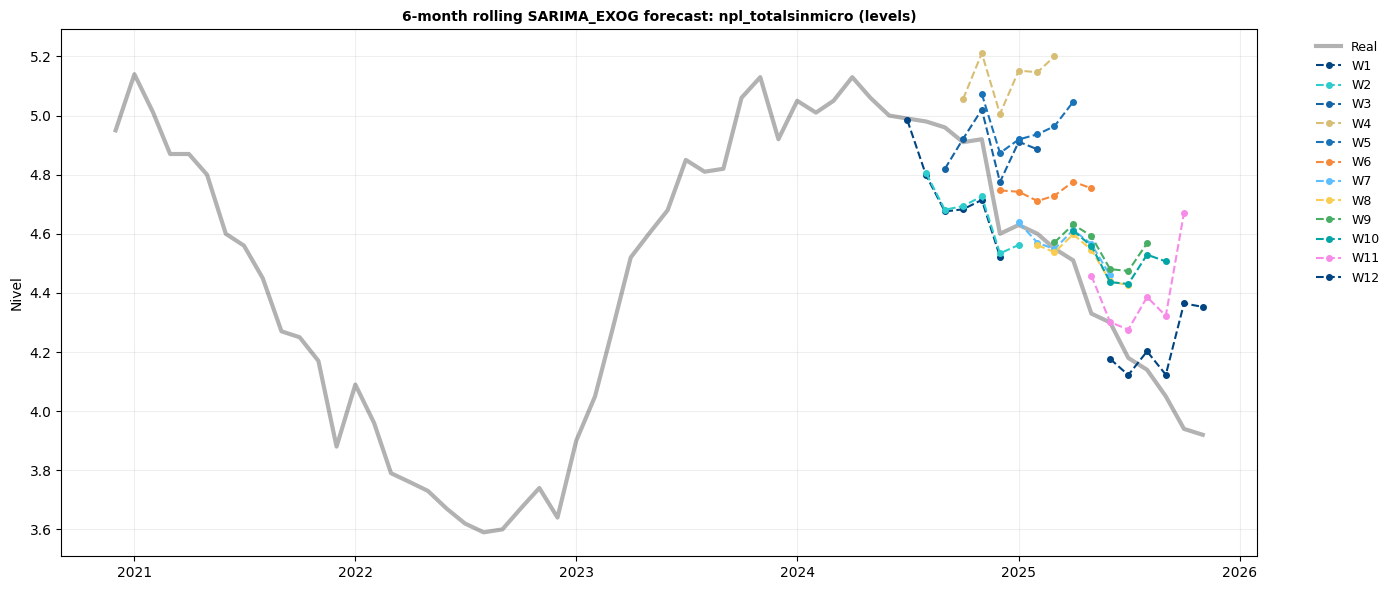

Window,1,2,3,4,5,6,7,8,9,10,11,12,Mean
MAE,0.16,0.17,0.17,0.43,0.33,0.21,0.09,0.12,0.22,0.26,0.25,0.20,0.217500
RMSE,0.19,0.18,0.19,0.46,0.35,0.23,0.12,0.15,0.25,0.29,0.34,0.26,0.250833
R2,-0.97,-0.37,-0.42,-8.04,-6.08,-4.46,0.05,0.01,-1.76,-2.78,-5.33,-2.67,-2.735000
MAPE (%),3.33,3.40,3.53,9.19,7.27,4.61,2.05,2.86,5.13,6.23,6.09,4.90,4.882500


In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_name="SARIMA_EXOG", model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


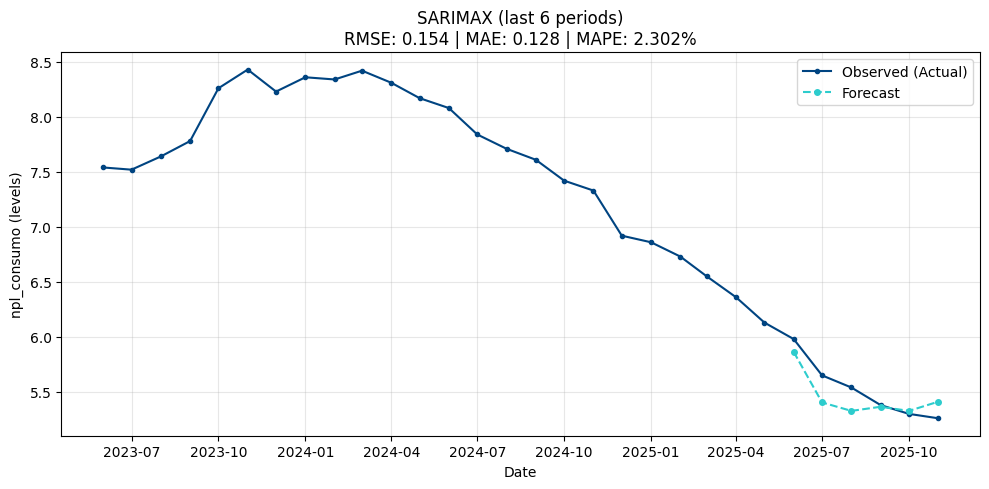

In [ ]:
# AUTOREGRESSION WITH EXOGENOUS VARIABLES

y_pred = autoregression_with_exog(NPL_DATA, target_var=TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER)

if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"SARIMAX (last 6 periods)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

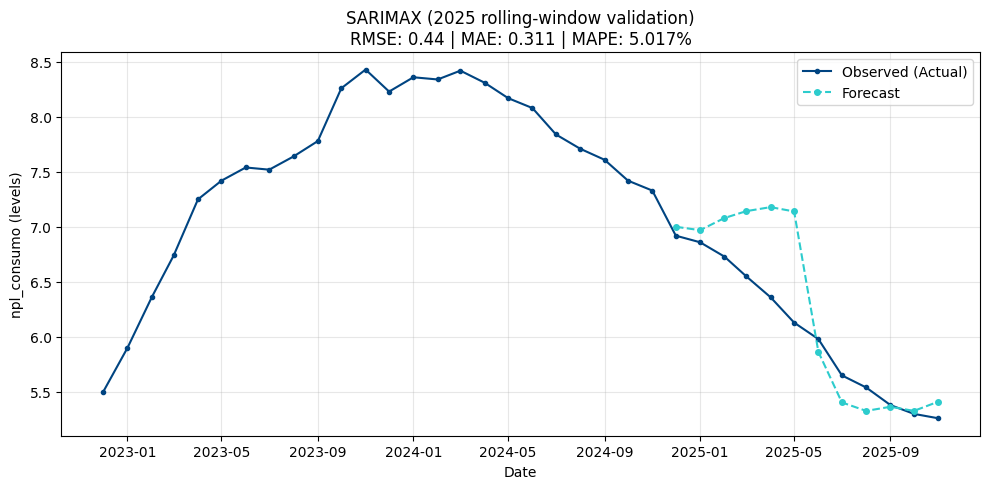

Covariates: Index(['npl_consumo', 'bruta_consumo_lag15', 'ipi_lag6', 'ise_terc_des_lag6',
       'ventas_minor_lag6', 'pol_mon_lag12', 'tarj_nat_inter_compra_lag13',
       'inflacion_lag18', 'cred_consumo_lag7', 'bbva_cons_alim_real_lag23',
       'gdelt_5_lag13', 'google_consumo_pc_lag13', 'conf_comercial_lag6',
       'covid'],
      dtype='object')


In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)

#### Linear regression

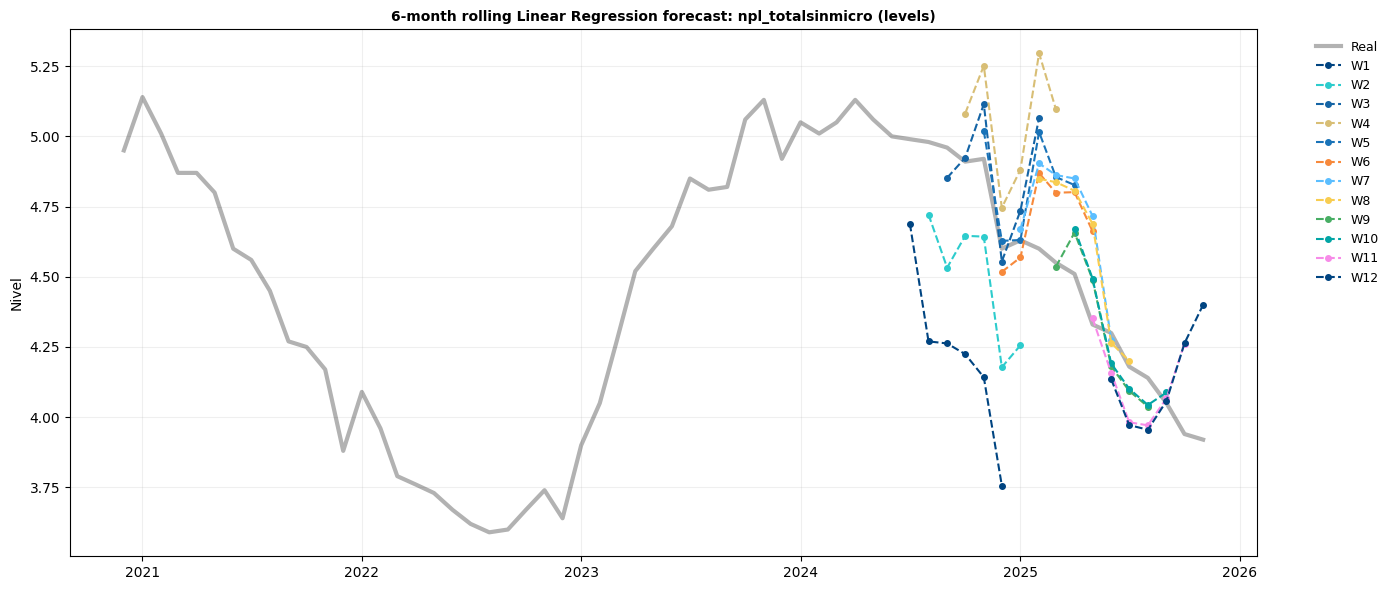

'\ny_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\n\nprint("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)\nprint("Train since:", NPL_DATA.index[0])\nprint(NPL_DATA.columns)\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")\n'

In [ ]:
# LINEAR REGRESSION
LAGS = 12
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_name="Linear Regression", model_kwargs={"n_lags":LAGS})
"""
y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")
"""

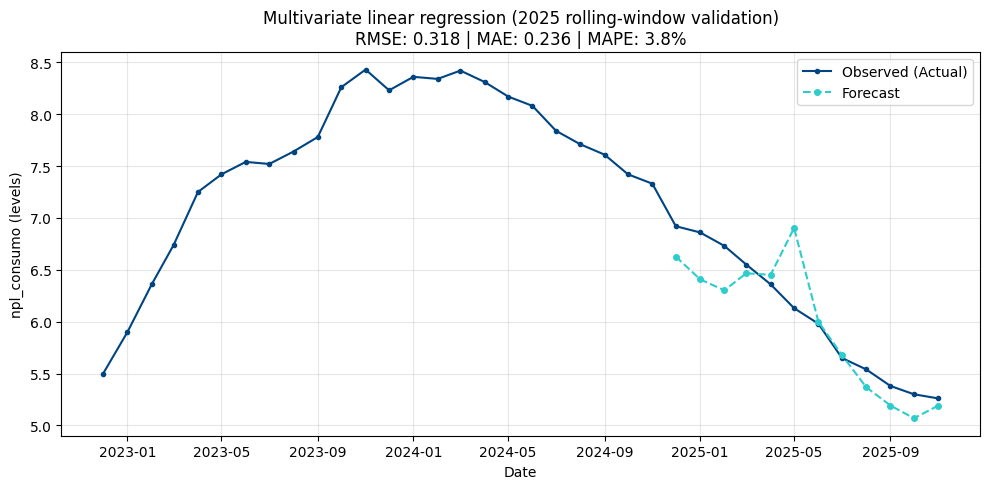

#### Linear regression ensemble

Fitting model since 2002-01-01 00:00:00
Fitting model since 2002-12-01 00:00:00
Fitting model since 2004-05-01 00:00:00
Fitting model since 2006-07-01 00:00:00
Fitting model since 2011-12-01 00:00:00
Fitting model since 2015-07-01 00:00:00
Fitting model since 2016-10-01 00:00:00
Fitting model since 2022-01-01 00:00:00
                 rmse    weight
start_date                     
2002-01-01   0.589599  0.061760
2002-12-01   0.921573  0.025279
2004-05-01   0.557440  0.069092
2006-07-01   0.432992  0.114515
2011-12-01   0.907394  0.026075
2015-07-01   0.900417  0.026481
2016-10-01   0.178110  0.676773
2022-01-01  29.565597  0.000025
Fitting model since 2002-01-01 00:00:00
Fitting model since 2002-12-01 00:00:00
Fitting model since 2004-05-01 00:00:00
Fitting model since 2006-07-01 00:00:00
Fitting model since 2011-12-01 00:00:00
Fitting model since 2015-07-01 00:00:00
Fitting model since 2016-10-01 00:00:00
Fitting model since 2022-01-01 00:00:00
                rmse    weight
start_dat

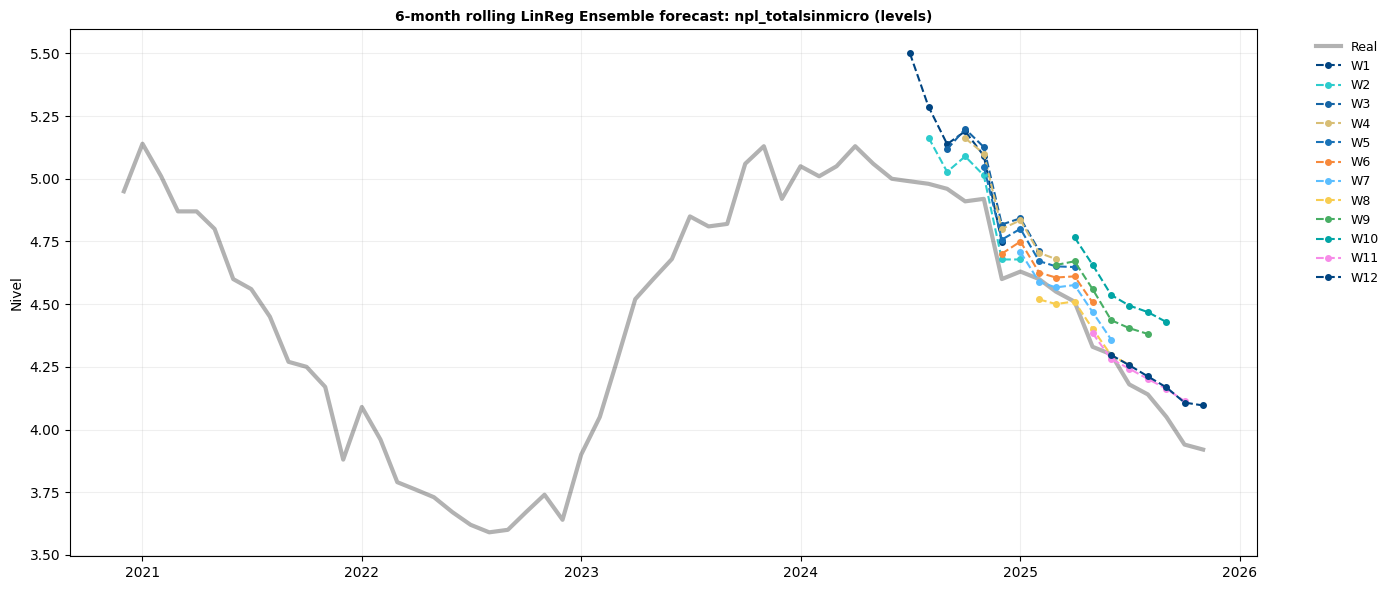

'\ny_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)\nif TARGET_LOGITDIFF_TRANSF == True:\n  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)\n\nforecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")\nrolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,\n                                                                                                                            "weighs_power": 2.0})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")\n'

In [ ]:
LAGS = 12
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_name="LinReg Ensemble", model_kwargs={"n_lags": LAGS,"weighs_power": 2.0})

"""
y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,
                                                                                                                            "weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")
"""

#### Ridge Regression

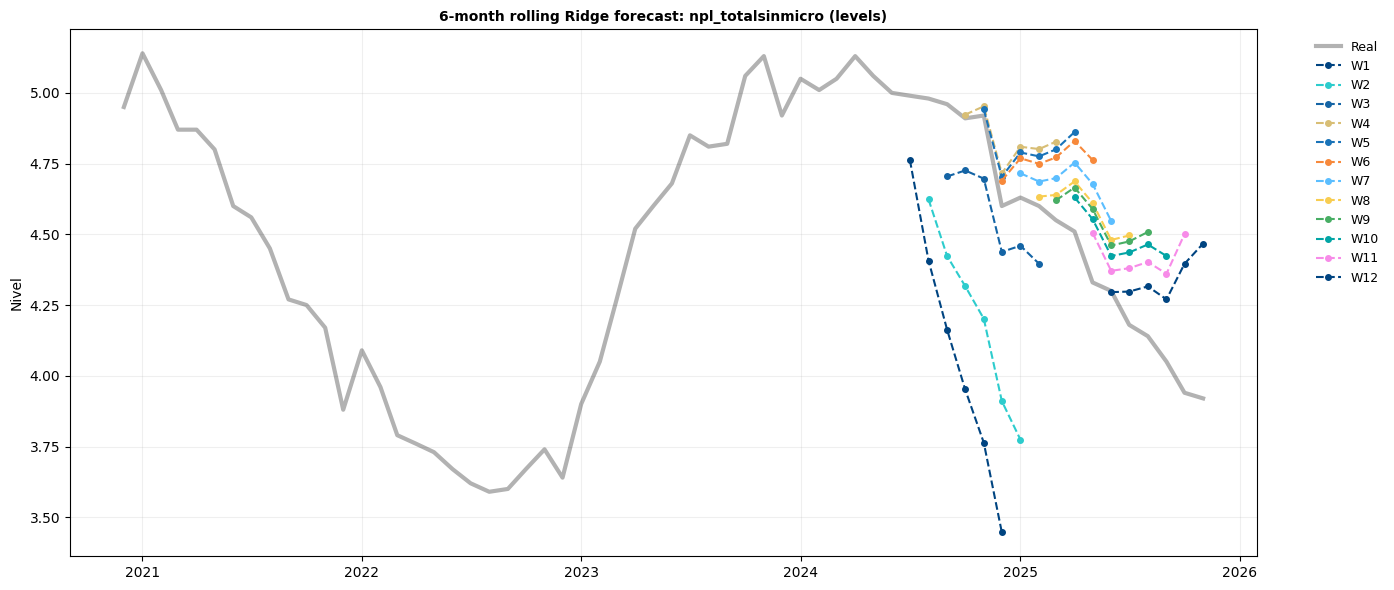

'rolling_2025 = rolling_validation_2025(data=NPL_DATA,\n                                       target_var=TARGET, \n                                       model_fn=multivariate_ridge_regression,\n                                       model_kwargs={"n_lags": LAGS,\n                                                     "alpha": 2.0})\nforecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")\n'

In [ ]:
rolling_validation_12_windows(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_ridge_regression, model_name="Ridge", model_kwargs={"n_lags": LAGS, "alpha": 2.0})

"""rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")
"""

#### Ridge Regression ensemble

Fitting model since 2002-01-01 00:00:00
Ridge alpha=1.0 Intercept: 3.297220442515162e-17
Ridge Coefficients (scaled X space):
bruta_totalsinmicro_lag10    0.046378
conf_comercial_lag24         0.019957
ventas_minor_lag24          -0.009783
covid                        0.000762
y_lag1                       0.894039
y_lag2                       0.235067
y_lag3                      -0.080919
y_lag4                      -0.105939
y_lag5                      -0.038530
y_lag6                       0.096004
y_lag7                      -0.027137
y_lag8                      -0.047122
y_lag9                       0.074084
y_lag10                     -0.077515
y_lag11                      0.036337
y_lag12                     -0.012385
Name: coef_scaled_space, dtype: float64
Fitting model since 2002-12-01 00:00:00
Ridge alpha=1.0 Intercept: -1.532081725931114e-17
Ridge Coefficients (scaled X space):
bruta_totalsinmicro_lag10      0.035155
conf_comercial_lag24           0.022262
ventas_minor_lag24 

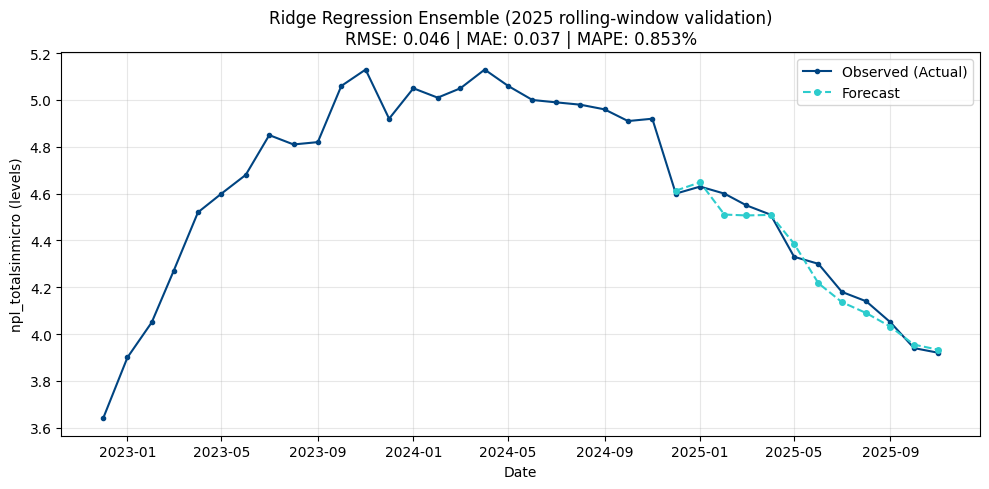

In [70]:
LAGS = 12

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")

#### Quantile regression

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {
    "quantile": 0.5
}

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")

#### Random forest

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Extra trees regressor

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 2,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}

y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### XGBoost

In [ ]:
# XGBOOST
LAGS = 12
HYPERPARAMETERS_XGBOOST = {"learning_rate": 0.05,
                           "n_estimators": 300,
                           "max_depth": 5,
                           "min_child_weight": 5,  # Minimum sum of instance weight (hessian) needed in a child
                           "subsample": 0.3,         # Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees.
                           "random_state": 42}

y_pred = xgboost_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_XGBOOST)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"XGBoost ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=xgboost_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                   "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

In [ ]:
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}

y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")

#### LSTM

In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")

#### Chronos-2

In [ ]:
y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")

#### Bayesian Structual Time Series (BSTS)

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 12
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}

y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)

### **NPL Total**

#### Variable selection

In [ ]:
# SELECCIÓN CARMEN (TARGET_PROC VS. REGRESSORS_PROC)

if TARGET_LOGITDIFF_TRANSF == True:
  data_total_npl = target_logit_diff[["npl_total"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_total_npl = target[["npl_total"]].copy(deep=True)
  print("Target did not have transformation.")

data_total_npl["bruta_total_lag17"] = regressors["bruta_total"].shift(6) * -1
data_total_npl["coloc_total_lag14"] = regressors["coloc_total"].shift(14)
data_total_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_inv_total_real"].shift(24) * -1
data_total_npl["gdelt_11_lag18"] = regressors["gdelt_11"].shift(18) * -1
data_total_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) * -1
data_total_npl["conf_consumo_lag7"] = regressors["conf_consumo"].shift(7) * -1

data_total_npl = data_total_npl["2002":].dropna(how="all")

#data_total_npl = add_missing_flags(data_total_npl, "npl_total")
#data_total_npl = add_fourier_terms(data_total_npl, period=12, K=2)
data_total_npl = add_covid_dummy(data_total_npl, covid_dates=COVID_DATES)

data_total_npl.tail()

data_total_npl.tail()

In [ ]:
# SELECCIÓN EQUIPO (TARGET VS. REGRESSORS_PROC)

'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_total_npl = target_logit_diff[["npl_total"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_total_npl = target[["npl_total"]].copy(deep=True)
  print("Target did not have transformation.")
data_total_npl["bruta_total_lag17"] = regressors["bruta_total"].shift(6) * -1
data_total_npl["coloc_total_lag14"] = regressors["coloc_total"].shift(14)
data_total_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_inv_total_real"].shift(24) * -1
data_total_npl["gdelt_11_lag18"] = regressors["gdelt_11"].shift(18) * -1
data_total_npl["ise_total_des_lag6"] = regressors["ise_total_des"].shift(6) * -1
data_total_npl["conf_consumo_lag7"] = regressors["conf_consumo"].shift(7) * -1
data_total_npl.tail()
'''

In [ ]:
# PARAMETERS: NPL TOTAL
NPL_DATA = data_total_npl
TARGET = "npl_total"
ORDER = (3,1,0)
SEASONAL_ORDER = (1,0,1,12)

#### Autoregression

In [ ]:
y_pred = autoregression(NPL_DATA, TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER, test_size=TEST_SIZE)

# Detransform
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

# Plot
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression (last 6 periods)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Autoregression (2025 rolling-window validation)")

#### Autoregression with exog

In [ ]:
# AUTOREGRESSION WITH EXOGENOUS VARIABLES

y_pred = autoregression_with_exog(NPL_DATA, target_var=TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER)

if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"SARIMAX (last 6 periods)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)

#### Linear regression

In [ ]:
# LINEAR REGRESSION
LAGS = 12

y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")

#### Linear regression ensemble

In [ ]:
LAGS = 12

y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,
                                                                                                                            "weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Ridge Regression

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")

#### Ridge Regression ensemble

In [ ]:
LAGS = 12

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")

#### Quantile regression

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {
    "quantile": 0.5
}

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")

#### Random forest

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Extra trees regressor

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 2,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}

y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### XGBoost

In [ ]:
# XGBOOST
LAGS = 12
HYPERPARAMETERS_XGBOOST = {"learning_rate": 0.05,
                           "n_estimators": 300,
                           "max_depth": 5,
                           "min_child_weight": 5,  # Minimum sum of instance weight (hessian) needed in a child
                           "subsample": 0.3,         # Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees.
                           "random_state": 42}

y_pred = xgboost_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_XGBOOST)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"XGBoost ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=xgboost_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                   "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

In [ ]:
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}

y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")

#### LSTM

In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")

#### Chronos-2

In [ ]:
y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")

#### Bayesian Structual Time Series (BSTS)

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 12
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}

y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)

### **NPL Microcrédito**

#### Variable selection

**Max. correlación desde 2020**:
* bruta_total (t-14): pos
* ise_terc_comercio_des (t-5): neg
* coloc_banrep (t-14):  pos
* cred_comercial_pref (t-15): pos
* conf_comercial (t-9): neg
* ventas_minor (t-5): neg
* tarj_jur_inter_compra (t-13): pos
* inflacion (t-19): pos
* google_total_pc (t-13): pos
* bbva_cons_atm_real (t-5): neg
* gdelt_7 (t-5): pos
* vivienda_utv (t-6): pos

In [ ]:
# OPTIMO PARA MULTIVARIATE LINEAR REGRESSION
if TARGET_LOGITDIFF_TRANSF == True:
  data_microcredito_npl = target_logit_diff[["npl_microcredito"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_microcredito_npl = target[["npl_microcredito"]].copy(deep=True)
  print("Target did not have transformation.")

data_microcredito_npl["bruta_total_lag14"] = regressors["bruta_total"].shift(14)
data_microcredito_npl["ise_terc_comercio_des_lag5"] = regressors["ise_terc_comercio_des"].shift(5) * -1
data_microcredito_npl["coloc_banrep_lag14"] = regressors["coloc_banrep"].shift(14)
#data_microcredito_npl["cred_comercial_pref_lag15"] = regressors["cred_comercial_pref"].shift(15)
#data_microcredito_npl["conf_comercial_lag9"] = regressors["conf_comercial"].shift(9) * -1
#data_microcredito_npl["ventas_minor_lag5"] = regressors["ventas_minor"].shift(5) * -1
#data_microcredito_npl["tarj_jur_inter_compra_lag13"] = regressors["tarj_jur_inter_compra"].shift(13)
#data_microcredito_npl["inflacion_lag19"] = regressors["inflacion"].shift(19)
#data_microcredito_npl["google_total_pc_lag13"] = regressors["google_total_pc"].shift(13)
#data_microcredito_npl["bbva_cons_atm_real_lag5"] = regressors["bbva_cons_atm_real"].shift(5) * -1
data_microcredito_npl["gdelt_7_lag5"] = regressors["gdelt_7"].shift(5)
data_microcredito_npl["vivienda_utv_lag6"] = regressors["vivienda_utv"].shift(6)
data_microcredito_npl = data_microcredito_npl.dropna()
data_microcredito_npl.head()

In [ ]:
# OPTIMO PARA AUTOREGRESSION
'''
if TARGET_LOGITDIFF_TRANSF == True:
  data_microcredito_npl = target_logit_diff[["npl_microcredito"]].copy(deep=True)
  print("Target is expressed as the yearly difference of logits.")
else:
  data_microcredito_npl = target[["npl_microcredito"]].copy(deep=True)
  print("Target did not have transformation.")

data_microcredito_npl["bruta_total_lag18"] = regressors["bruta_total"].shift(18)
#data_microcredito_npl["ise_terc_comercio_des_lag5"] = regressors["ise_terc_comercio_des"].shift(5) * -1
data_microcredito_npl["coloc_banrep_lag18"] = regressors["coloc_banrep"].shift(18)
data_microcredito_npl["cred_comercial_pref_lag18"] = regressors["cred_comercial_pref"].shift(18)
#data_microcredito_npl["conf_comercial_lag9"] = regressors["conf_comercial"].shift(9) * -1
#data_microcredito_npl["ventas_minor_lag5"] = regressors["ventas_minor"].shift(5) * -1
#data_microcredito_npl["tarj_jur_inter_compra_lag18"] = regressors["tarj_jur_inter_compra"].shift(18)
data_microcredito_npl["inflacion_lag18"] = regressors["inflacion"].shift(18)
data_microcredito_npl["google_total_pc_lag18"] = regressors["google_total_pc"].shift(18)
#data_microcredito_npl["bbva_cons_alim_real_lag24"] = regressors["bbva_cons_alim_real"].shift(24) * -1
#data_microcredito_npl["bbva_cons_entret_real_lag24"] = regressors["bbva_cons_entret_real"].shift(24)
data_microcredito_npl["vivienda_ventas_lag18"] = regressors["vivienda_ventas"].shift(18) * -1
data_microcredito_npl = data_microcredito_npl.dropna()
data_microcredito_npl.head()
'''

In [ ]:
# PARAMETERS: NPL MICROCRÉDITO
NPL_DATA = data_microcredito_npl
TARGET = "npl_microcredito"
ORDER = (3,1,3)
SEASONAL_ORDER = (1,0,0,12)

In [ ]:
NPL_DATA.corr()

#### Autoregression

In [ ]:
y_pred = autoregression(NPL_DATA, TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER, test_size=TEST_SIZE)

# Detransform
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

# Plot
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Autoregression (last 6 periods)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Autoregression (2025 rolling-window validation)")

#### Autoregression with exog

In [ ]:
# AUTOREGRESSION WITH EXOGENOUS VARIABLES

y_pred = autoregression_with_exog(NPL_DATA, target_var=TARGET, order=ORDER, seasonal_order=SEASONAL_ORDER)

if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = 100 / (1 + np.exp(-y_pred))

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"SARIMAX (last 6 periods)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=autoregression_with_exog, model_kwargs={"order": ORDER, "seasonal_order": SEASONAL_ORDER})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"SARIMAX (2025 rolling-window validation)")
print("Covariates:", NPL_DATA.columns)

#### Linear regression

In [ ]:
# LINEAR REGRESSION
LAGS = 12

y_pred = multivariate_linear_regression(NPL_DATA, TARGET, TEST_SIZE, LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Multivariate Linear Regression (with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=multivariate_linear_regression, model_kwargs={"n_lags":LAGS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Multivariate linear regression (2025 rolling-window validation)")

#### Linear regression ensemble

In [ ]:
LAGS = 12

y_pred = linear_regression_ensemble(data=NPL_DATA, target_var=TARGET, test_size=TEST_SIZE, n_lags=LAGS)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)

forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Linear Regression Ensemble (with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=linear_regression_ensemble, model_kwargs={"n_lags": LAGS,
                                                                                                                            "weighs_power": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Ridge Regression

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=multivariate_ridge_regression,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 2.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression (2025 rolling-window validation)")

#### Ridge Regression ensemble

In [ ]:
LAGS = 12

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=ridge_regression_ensemble,
                                       model_kwargs={"n_lags": LAGS,
                                                     "alpha": 1.0,
                                                     "weighs_power": 10.0})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Ridge Regression Ensemble (2025 rolling-window validation)")

#### Quantile regression

In [ ]:
LAGS = 12
HYPERARAMETERS_QUANTILEREG = {
    "quantile": 0.5
}

rolling_2025 = rolling_validation_2025(data=NPL_DATA,
                                       target_var=TARGET,
                                       model_fn=quantile_regressor,
                                       model_kwargs={"n_lags": LAGS, "hyperparams": HYPERARAMETERS_QUANTILEREG})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Quantile Regression (2025 rolling-window validation)")

#### Random forest

In [ ]:
LAGS = 12
HYPERPARAMETERS_RANDOMFOREST = {
    "n_estimators": 300,
    "max_depth": 5,
    "min_samples_split": 4,
    "min_samples_leaf": 1,
    "random_state": 42
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=random_forest_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                         "hyperparams": HYPERPARAMETERS_RANDOMFOREST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Random Forest (2025 rolling-window validation)")

#### Extra trees regressor

In [ ]:
# EXTRA TREES REGRESSOR
LAGS = 12
HYPERPARAMETERS_EXTRATREES = {"n_estimators": 300,
                              "max_depth": 5,           # The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure
                              "min_samples_split": 2,   # The minimum number of samples required to split an internal node
                              "min_samples_leaf": 1,    # The minimum number of samples required to be at a leaf node
                              "bootstrap": True,        # Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
                              "random_state": 42}

y_pred = extra_trees_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_EXTRATREES)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"ExtraTreesRegressor ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=extra_trees_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                       "hyperparams": HYPERPARAMETERS_EXTRATREES})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### XGBoost

In [ ]:
# XGBOOST
LAGS = 12
HYPERPARAMETERS_XGBOOST = {"learning_rate": 0.05,
                           "n_estimators": 300,
                           "max_depth": 5,
                           "min_child_weight": 5,  # Minimum sum of instance weight (hessian) needed in a child
                           "subsample": 0.3,         # Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees.
                           "random_state": 42}

y_pred = xgboost_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_XGBOOST)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"XGBoost ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=xgboost_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                   "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"XGBoost (2025 rolling-window validation)")

#### LightGBM

In [ ]:
LAGS = 12
HYPERPARAMETERS_LIGHTGBM = {"learning_rate": 0.03,
                            "n_estimators": 300,
                            "max_depth": 3,
                            "min_child_samples": 5,
                            "random_state": 42,
                            "verbose":-1}

y_pred = lightgbm_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_LIGHTGBM)
if TARGET_LOGITDIFF_TRANSF == True:
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"LightGBM ({TARGET} con {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lightgbm_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                    "hyperparams": HYPERPARAMETERS_XGBOOST})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LightGBM (2025 rolling-window validation)")

#### LSTM

In [ ]:
LSTM_HYPERPARAMETERS = {
    "units": 32,
    "learning_rate": 0.05,
    "epochs": 200,
    "bacth_size": 64
}

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=lstm_regressor, model_kwargs={"n_lags": 12,
                                                                                                                "hyperparams": LSTM_HYPERPARAMETERS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")

#### Chronos-2

In [ ]:
y_pred = chronos_2(NPL_DATA, TARGET, test_size=TEST_SIZE, covariate_cols=list(NPL_DATA.drop(TARGET,axis=1).columns))
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Chronos-2")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=chronos_2, model_kwargs={"covariate_cols": list(NPL_DATA.drop(TARGET,axis=1).columns)})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"Chronos-2 (2025 rolling-window validation)")

#### Bayesian Structual Time Series (BSTS)

In [ ]:
# BAYESIAN STRUCTURAL TIME SERIES
LAGS = 12
HYPERPARAMETERS_BSTS = {
    "level": "local level",           # tendencia suave
    "trend": "local linear trend",    # incluye pendiente
    "seasonal": 12                    # estacionalidad mensual
}

y_pred = bsts_regressor(NPL_DATA, TARGET, LAGS, TEST_SIZE, HYPERPARAMETERS_BSTS)
if TARGET_LOGITDIFF_TRANSF == True:
  print("Target is transformed.")
  y_pred = detransform_predictions(train_data=NPL_DATA, y_pred_transf=y_pred, target_dataset=target, target_var=TARGET)
print("Target is tranformed:", TARGET_LOGITDIFF_TRANSF)
print("Train since:", NPL_DATA.index[0])
print(NPL_DATA.columns)
forecast_plot(true_data=target[TARGET], forecast=y_pred, title=f"Bayesian Structural Time Series ({TARGET} with {LAGS} lags)")

In [ ]:
rolling_2025 = rolling_validation_2025(data=NPL_DATA, target_var=TARGET, model_fn=bsts_regressor, model_kwargs={"n_lags": LAGS,
                                                                                                                "hyperparams": HYPERPARAMETERS_BSTS})
forecast_plot(true_data=target[TARGET], forecast=rolling_2025, title=f"LSTM (2025 rolling-window validation)")
print(LSTM_HYPERPARAMETERS)